# 10 — Event amplitudes and acoustic–seismic coupling

Measure component and three-component vector PGV, aligned median-stack pressure
amplitudes, reduced pressure, signal-to-noise ratios, and acoustic-to-seismic
amplitude ratios for all 153 Notebook 070 events. Final A/B/C planar-solution
quality classes from Notebook 080 are retained as descriptive overlays;
regression uses independent measurement-quality thresholds.


In [73]:
from __future__ import annotations

import importlib
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LogNorm
from matplotlib.ticker import FuncFormatter
from obspy import read
from scipy.signal import periodogram
from scipy.stats import linregress

def find_project_root(start):
    current = Path(start).resolve()
    for candidate in (current, *current.parents):
        if (candidate / "modules" / "project_config.py").is_file():
            return candidate
    raise FileNotFoundError(
        f"Could not find modules/project_config.py above {current}"
    )


project_root = find_project_root(Path.cwd())
project_root_text = str(project_root)
sys.path = [entry for entry in sys.path if entry != project_root_text]
sys.path.insert(0, project_root_text)

# A long-lived Jupyter kernel may still hold an older project_config after
# the file has been edited. Remove the cached package and import the copy
# belonging to the repository that contains this notebook.
sys.modules.pop("modules.project_config", None)
sys.modules.pop("modules", None)
importlib.invalidate_caches()
from modules import project_config as config

expected_config_file = (
    project_root / "modules" / "project_config.py"
).resolve()
active_config_file = Path(config.__file__).resolve()
if active_config_file != expected_config_file:
    raise RuntimeError(
        "Imported the wrong project_config.py: "
        f"{active_config_file}; expected {expected_config_file}"
    )
required_source_event_keys = {
    "upper_stage", "lower_stage", "payload_impact",
    "payload_explosion", "event_024",
}
missing_source_event_keys = sorted(
    required_source_event_keys - set(config.SOURCE_EVENT_TIMES)
)
if missing_source_event_keys:
    raise RuntimeError(
        f"{active_config_file} is missing canonical source-event keys: "
        + ", ".join(missing_source_event_keys)
    )
print("Active project configuration:", active_config_file)

PREPARATION_ROOT = config.NB070_DIR
PLANAR_ROOT = config.NB080_DIR

OUTPUT_ROOT = config.NB100_DIR
FIGURE_DIR = OUTPUT_ROOT / "figures"
DIAGNOSTIC_DIR = OUTPUT_ROOT / "event_diagnostics"

for directory in (
    OUTPUT_ROOT,
    FIGURE_DIR,
    DIAGNOSTIC_DIR,
):
    directory.mkdir(parents=True, exist_ok=True)

CANDIDATE_CATALOGUE_FILE = (
    PREPARATION_ROOT
    / "derived"
    / "candidate_airwave_event_catalogue.csv"
)
FILTER_DECISIONS_FILE = PLANAR_ROOT / "event_filter_decisions.csv"
PLANAR_RESULTS_FILE = PLANAR_ROOT / "planar_array_results.csv"
EVENT_STREAM_DIR = PREPARATION_ROOT / "event_streams"

ANALYSIS_CONFIG_FILE = config.NB010_DIR / "analysis_configuration.json"
WEATHER_SUMMARY_FILE = config.NB020_DIR / "weather_acoustic_summary.csv"

for required_file in (
    ANALYSIS_CONFIG_FILE,
    WEATHER_SUMMARY_FILE,
):
    if not required_file.exists():
        raise FileNotFoundError(required_file)

analysis_config = json.loads(ANALYSIS_CONFIG_FILE.read_text())
GEOMETRY_FILE = Path(
    analysis_config["geometry_file"]
).expanduser()
if not GEOMETRY_FILE.exists():
    raise FileNotFoundError(
        "Geometry product recorded by Notebook 010 was not found: "
        f"{GEOMETRY_FILE}"
    )
geometry = pd.read_csv(GEOMETRY_FILE)
weather_summary = pd.read_csv(WEATHER_SUMMARY_FILE).iloc[0]

SEISMIC_CHANNELS = ("DHZ", "DHN", "DHE")
SEISMIC_LABELS = {"DHZ": "Vertical", "DHN": "North", "DHE": "East"}
INFRASOUND_CHANNELS = ("DD1", "DD2", "DD3")
INFRASOUND_DISTANCES_M = (
    geometry.loc[geometry["channel"].isin(INFRASOUND_CHANNELS)]
    .set_index("channel")["distance_m"].astype(float).to_dict()
)
METEOROLOGICAL_EFFECTIVE_SOUND_SPEED_MPS = float(
    weather_summary["effective_sound_speed_mps"]
)
# Fixed catalogue-stacking speed, consistent with the high-quality weighted
# planar result from Notebook 080. This affects only differential alignment.
ACOUSTIC_ALIGNMENT_SPEED_MPS = 352.0
ACOUSTIC_ALIGNMENT_SPEED_PROVENANCE = (
    "Rounded high-quality weighted planar apparent speed from Notebook 080"
)
ACOUSTIC_REFERENCE_CHANNEL = analysis_config["infrasound_reference_channel"]

# Times are relative to each event's reduced/reference time.
NOISE_WINDOW_S = (-0.18, -0.05)
DEFAULT_SIGNAL_PADDING_S = 0.0
PRINCIPAL_EXPLOSION_EVENT_NUMBER = 13
EXPECTED_EVENT_COUNT = 153
PRINCIPAL_SIGNAL_WINDOW_S = (-0.04, 0.35)

# Approximate distance used only for optional reduced-pressure columns.
REFERENCE_SOURCE_DISTANCE_M = float(analysis_config["array_reference"]["distance_m"])
REDUCED_PRESSURE_REFERENCE_DISTANCE_M = 1000.0

# Constant p2p-pressure/PGV ratios shown on the log-log comparison.
# Units are Pa / (m s^-1).
RATIO_GUIDES_PA_PER_MPS = (1e5, 1e6, 1e7, 1e8, 1e9)

# Optional diagnostic waveform plots. Set to an integer to limit their number.
MAKE_EVENT_DIAGNOSTICS = True
MAX_DIAGNOSTIC_EVENTS: int | None = None

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 240,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


Active project configuration: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/modules/project_config.py


## Load and combine existing event metadata

The candidate catalogue supplies the acoustic measurements and event intervals.
Notebook 080 supplies the final back-azimuth, apparent-velocity, coherence and
A/B/C solution-quality fields. All 153 events are retained. The older permissive
and core-filter fields remain in the exported table only for provenance and do
not control figures or physical interpretation.


In [74]:
for required in (CANDIDATE_CATALOGUE_FILE, PLANAR_RESULTS_FILE):
    if not required.exists():
        raise FileNotFoundError(required)

events = pd.read_csv(CANDIDATE_CATALOGUE_FILE)
events = events.rename(columns={"candidate_event_number": "event_number"})
events["event_number"] = events["event_number"].astype(int)
events["event_time"] = pd.to_datetime(
    events["reduced_event_epoch_s"], unit="s", utc=True
)

# Retain legacy decisions as provenance only.
if FILTER_DECISIONS_FILE.exists():
    decisions = pd.read_csv(FILTER_DECISIONS_FILE)
    keep = [
        "event_number", "event_label", "forced_named_event",
        "passes_analysis_filter", "passes_core_filter",
        "analysis_filter_reason",
    ]
    events = events.merge(
        decisions[[c for c in keep if c in decisions]],
        on="event_number",
        how="left",
    )

planar = pd.read_csv(PLANAR_RESULTS_FILE)
required_planar_columns = {
    "event_number", "best_back_azimuth_deg", "best_apparent_speed_mps",
    "maximum_coherence_score", "solution_quality_class",
}
missing_planar_columns = sorted(required_planar_columns - set(planar.columns))
if missing_planar_columns:
    raise ValueError(
        "Notebook 080 output is stale or incompatible; missing columns: "
        + ", ".join(missing_planar_columns)
    )

planar_keep = [
    "event_number", "best_back_azimuth_deg", "best_apparent_speed_mps",
    "maximum_coherence_score", "solution_quality_class",
    "stability_back_azimuth_std_deg", "stability_speed_std_mps",
    "stability_score_min", "stability_valid_window_count",
]
events = events.merge(
    planar[[c for c in planar_keep if c in planar.columns]],
    on="event_number",
    how="left",
    validate="one_to_one",
)

events = events.sort_values("event_number").reset_index(drop=True)
expected_numbers = np.arange(1, EXPECTED_EVENT_COUNT + 1)
actual_numbers = events["event_number"].to_numpy(int)
if len(events) != EXPECTED_EVENT_COUNT or not np.array_equal(actual_numbers, expected_numbers):
    raise ValueError(
        f"Expected the complete catalogue numbered 1–{EXPECTED_EVENT_COUNT}; "
        f"found {len(events)} rows. Re-run revised Notebooks 07 and 08."
    )
if events["solution_quality_class"].isna().any():
    missing = events.loc[
        events["solution_quality_class"].isna(), "event_number"
    ].tolist()
    raise ValueError(f"Missing Notebook 080 quality classes for events: {missing}")

allowed_quality_classes = {"A_high_quality", "B_probable", "C_weak_or_broad"}
unexpected_quality_classes = set(events["solution_quality_class"]) - allowed_quality_classes
if unexpected_quality_classes:
    raise ValueError(
        f"Unexpected Notebook 080 quality classes: {sorted(unexpected_quality_classes)}"
    )

for column in ("forced_named_event", "passes_analysis_filter", "passes_core_filter"):
    if column not in events:
        events[column] = False
    events[column] = events[column].fillna(False).astype(bool)

events["legacy_selection_tier"] = np.select(
    [events["passes_core_filter"], events["passes_analysis_filter"]],
    ["core", "additional_analyzed"],
    default="other_candidate",
)

events = events.sort_values("reduced_event_epoch_s").reset_index(drop=True)
events["elapsed_time_s"] = (
    events["reduced_event_epoch_s"] - events["reduced_event_epoch_s"].min()
)
events["elapsed_time_min"] = events["elapsed_time_s"] / 60.0

print("Active output root:", OUTPUT_ROOT)
print(f"Validated {len(events)} catalogue events with Notebook 080 results")
display(
    events["solution_quality_class"]
    .value_counts()
    .rename_axis("quality_class")
    .to_frame("events")
)
display(events.head())


Active output root: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/100_measure_event_amplitudes_and_acoustic_seismic_coupling
Validated 153 catalogue events with Notebook 080 results


,events
quality_class,
C_weak_or_broad,57
A_high_quality,51
B_probable,45


,reconstructed_event_number,reduced_event_epoch_s,first_reduced_pick_epoch_s,last_reduced_pick_epoch_s,corrected_pick_span_s,pick_count,channel_count,channels,pick_indices,observed_first_pick_epoch_s,...,best_apparent_speed_mps,maximum_coherence_score,solution_quality_class,stability_back_azimuth_std_deg,stability_speed_std_mps,stability_score_min,stability_valid_window_count,legacy_selection_tier,elapsed_time_s,elapsed_time_min
0,1,1.472735e+09,1.472735e+09,1.472735e+09,0.002107,3,3,"DD1,DD2,DD3","198,193,194",1.472735e+09,...,352.5,0.979982,A_high_quality,0.291018,0.724356,0.968607,9,core,0.000000,0.000000
1,2,1.472735e+09,1.472735e+09,1.472735e+09,0.011107,3,3,"DD1,DD2,DD3","201,199,200",1.472735e+09,...,355.5,0.961110,A_high_quality,0.226623,2.403701,0.958165,9,core,0.130000,0.002167
2,3,1.472735e+09,1.472735e+09,1.472735e+09,0.003760,3,3,"DD1,DD2,DD3","204,202,203",1.472735e+09,...,352.5,0.957236,A_high_quality,0.177082,1.509231,0.949664,9,core,0.327867,0.005464
3,4,1.472735e+09,1.472735e+09,1.472735e+09,0.029866,2,2,"DD2,DD3","206,205",1.472735e+09,...,340.5,0.872909,B_probable,0.397523,1.683251,0.856808,9,additional_analyzed,0.519933,0.008666
4,5,1.472735e+09,1.472735e+09,1.472735e+09,0.000866,2,2,"DD2,DD3","207,208",1.472735e+09,...,359.0,0.806525,B_probable,0.244949,4.186250,0.788955,9,additional_analyzed,0.872433,0.014541


## PGV measurement

For each seismic component, a constant local baseline is estimated as the median
ground velocity in the pre-event noise interval. That baseline is subtracted
before measuring amplitudes. This avoids allowing the event itself to influence
an all-window demean or linear detrend.

The primary seismic amplitude is

\[
\mathrm{PGV}_{3C}=\max_t\sqrt{v_E(t)^2+v_N(t)^2+v_Z(t)^2}.
\]

Component PGVs and the vector PGV are measured over the acoustic event interval.
An entire-segment PGV is also retained as a diagnostic; it is not the preferred
catalogue value because it may include neighboring signals or coda.


In [75]:
def robust_sigma(values):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if values.size == 0:
        return np.nan
    median = np.nanmedian(values)
    return float(1.4826 * np.nanmedian(np.abs(values - median)))


def trace_relative_times(trace, reference_epoch_s):
    start_offset = float(trace.stats.starttime.timestamp) - float(reference_epoch_s)
    return start_offset + np.arange(trace.stats.npts, dtype=float) / float(trace.stats.sampling_rate)


def interpolate_trace(trace, reference_epoch_s, target_times_s):
    times = trace_relative_times(trace, reference_epoch_s)
    values = np.asarray(trace.data, dtype=float)
    return np.interp(target_times_s, times, values, left=np.nan, right=np.nan)


def signal_window_for_event(row):
    if int(row.event_number) == PRINCIPAL_EXPLOSION_EVENT_NUMBER:
        return PRINCIPAL_SIGNAL_WINDOW_S
    start = float(row.event_start_s) - DEFAULT_SIGNAL_PADDING_S
    end = float(row.event_end_s) + DEFAULT_SIGNAL_PADDING_S
    if not np.isfinite(start) or not np.isfinite(end) or end <= start:
        # Conservative fallback centered on the associated arrival.
        return (-0.04, 0.18)
    return (start, end)


def measure_event_pgv(row):
    stream_path = Path(row.segment_path)
    if not stream_path.exists():
        stream_path = EVENT_STREAM_DIR / row.segment_file
    if not stream_path.exists():
        raise FileNotFoundError(stream_path)

    stream = read(str(stream_path), format="PICKLE")
    reference_epoch_s = float(row.reduced_event_epoch_s)
    signal_start_s, signal_end_s = signal_window_for_event(row)

    traces = {}
    for channel in SEISMIC_CHANNELS:
        matches = stream.select(channel=channel)
        if len(matches) != 1:
            raise ValueError(f"Expected one {channel} trace in {stream_path}; found {len(matches)}")
        traces[channel] = matches[0]

    acoustic_traces = {}
    for channel in INFRASOUND_CHANNELS:
        matches = stream.select(channel=channel)
        if len(matches) != 1:
            raise ValueError(f"Expected one {channel} trace in {stream_path}; found {len(matches)}")
        acoustic_traces[channel] = matches[0]

    sampling_rates = [float(trace.stats.sampling_rate) for trace in traces.values()]
    sampling_rate_hz = min(sampling_rates)
    dt = 1.0 / sampling_rate_hz

    reference_distance_m = INFRASOUND_DISTANCES_M[ACOUSTIC_REFERENCE_CHANNEL]
    # The primary grid is the common overlap of the three seismic channels.
    # Shifted pressure traces may have NaNs at an edge; nanmedian then retains
    # the available sensors instead of shortening a valid late event window.
    common_start_s = max(trace_relative_times(trace, reference_epoch_s)[0] for trace in traces.values())
    common_end_s = min(trace_relative_times(trace, reference_epoch_s)[-1] for trace in traces.values())
    target_times_s = np.arange(common_start_s, common_end_s, dt)

    corrected = {}
    baselines = {}
    noise_scales = {}
    component_pgv = {}
    component_peak_time = {}

    signal_mask = (target_times_s >= signal_start_s) & (target_times_s <= signal_end_s)
    noise_mask = (target_times_s >= NOISE_WINDOW_S[0]) & (target_times_s <= NOISE_WINDOW_S[1])
    if np.count_nonzero(signal_mask) < 2:
        raise ValueError(f"No usable signal samples for event {row.event_number}")
    if np.count_nonzero(noise_mask) < 2:
        raise ValueError(f"No usable noise samples for event {row.event_number}")

    for channel, trace in traces.items():
        values = interpolate_trace(trace, reference_epoch_s, target_times_s)
        baseline = float(np.nanmedian(values[noise_mask]))
        centered = values - baseline
        corrected[channel] = centered
        baselines[channel] = baseline
        noise_scales[channel] = robust_sigma(centered[noise_mask])
        signal_values = centered[signal_mask]
        local_index = int(np.nanargmax(np.abs(signal_values)))
        component_pgv[channel] = float(np.abs(signal_values[local_index]))
        component_peak_time[channel] = float(target_times_s[signal_mask][local_index])

    matrix = np.vstack([corrected[channel] for channel in SEISMIC_CHANNELS])
    vector_velocity = np.sqrt(np.nansum(matrix ** 2, axis=0))
    vector_signal = vector_velocity[signal_mask]
    vector_index = int(np.nanargmax(vector_signal))
    vector_pgv = float(vector_signal[vector_index])
    vector_pgv_time_s = float(target_times_s[signal_mask][vector_index])
    segment_vector_pgv = float(np.nanmax(vector_velocity))

    vector_noise_scale = float(np.sqrt(np.nansum(np.square(list(noise_scales.values())))))
    vector_snr = vector_pgv / vector_noise_scale if vector_noise_scale > 0 else np.nan

    # Align baseline-corrected pressure traces to DD2 using one fixed physical
    # geometry and the declared 352 m/s catalogue-stacking speed. This avoids
    # optimizing amplitude with event-specific delays. Named-event peak
    # pressures are measured independently by channel in Notebook 110.
    aligned_pressure = []
    for channel in INFRASOUND_CHANNELS:
        delay_s = (INFRASOUND_DISTANCES_M[channel] - reference_distance_m) / ACOUSTIC_ALIGNMENT_SPEED_MPS
        aligned_pressure.append(
            interpolate_trace(acoustic_traces[channel], reference_epoch_s, target_times_s + delay_s)
        )
    aligned_pressure = np.vstack(aligned_pressure)
    median_pressure_stack = np.nanmedian(aligned_pressure, axis=0)
    mean_pressure_beam = np.nanmean(aligned_pressure, axis=0)
    acoustic_signal = median_pressure_stack[signal_mask]
    acoustic_positive_peak = float(np.nanmax(acoustic_signal))
    acoustic_negative_peak = float(np.nanmin(acoustic_signal))
    acoustic_peak_to_peak = acoustic_positive_peak - acoustic_negative_peak
    acoustic_noise_scale = robust_sigma(median_pressure_stack[noise_mask])
    acoustic_stack_snr = (
        acoustic_peak_to_peak / acoustic_noise_scale if acoustic_noise_scale > 0 else np.nan
    )

    result = {
        "event_number": int(row.event_number),
        "stream_file": str(stream_path),
        "seismic_signal_start_s": signal_start_s,
        "seismic_signal_end_s": signal_end_s,
        "seismic_signal_duration_s": signal_end_s - signal_start_s,
        "seismic_noise_start_s": NOISE_WINDOW_S[0],
        "seismic_noise_end_s": NOISE_WINDOW_S[1],
        "sampling_rate_hz": sampling_rate_hz,
        "pgv_dhz_mps": component_pgv["DHZ"],
        "pgv_dhn_mps": component_pgv["DHN"],
        "pgv_dhe_mps": component_pgv["DHE"],
        "pgv_vector_mps": vector_pgv,
        "pgv_vector_time_s": vector_pgv_time_s,
        "pgv_entire_segment_vector_mps": segment_vector_pgv,
        "pgv_vector_snr": vector_snr,
        "noise_dhz_mps": noise_scales["DHZ"],
        "noise_dhn_mps": noise_scales["DHN"],
        "noise_dhe_mps": noise_scales["DHE"],
        "noise_vector_mps": vector_noise_scale,
        "baseline_dhz_mps": baselines["DHZ"],
        "baseline_dhn_mps": baselines["DHN"],
        "baseline_dhe_mps": baselines["DHE"],
        "acoustic_stack_positive_peak_pa": acoustic_positive_peak,
        "acoustic_stack_negative_peak_pa": acoustic_negative_peak,
        "acoustic_stack_peak_to_peak_pa": acoustic_peak_to_peak,
        "acoustic_stack_noise_pa": acoustic_noise_scale,
        "acoustic_stack_p2p_snr": acoustic_stack_snr,
    }
    return result, {
        "times_s": target_times_s,
        "corrected": corrected,
        "vector_velocity": vector_velocity,
        "median_pressure_stack": median_pressure_stack,
        "mean_pressure_beam": mean_pressure_beam,
        "aligned_pressure": aligned_pressure,
        "signal_window": (signal_start_s, signal_end_s),
    }


## Measure every event and assemble the catalogue

The pressure/PGV ratios below use the median-stack acoustic measurements from
Notebook 070 and the coincident vector PGV measured here. The units are retained
explicitly:

\[
R_{P/V}=\frac{p_{p2p}}{\mathrm{PGV}_{3C}}
\quad [\mathrm{Pa}\,(\mathrm{m\,s^{-1}})^{-1}].
\]


In [76]:
pgv_rows = []
diagnostic_data = {}
errors = []

for row in events.itertuples(index=False):
    try:
        result, diagnostic = measure_event_pgv(row)
        pgv_rows.append(result)
        diagnostic_data[int(row.event_number)] = diagnostic
    except Exception as exc:
        errors.append({"event_number": int(row.event_number), "error": str(exc)})

pgv = pd.DataFrame(pgv_rows)
measurements = events.merge(pgv, on="event_number", how="left")

measurements["reduced_peak_to_peak_pa_1km"] = measurements["acoustic_stack_peak_to_peak_pa"] * (
    REFERENCE_SOURCE_DISTANCE_M / REDUCED_PRESSURE_REFERENCE_DISTANCE_M
)
measurements["p2p_pressure_to_vector_pgv"] = (
    measurements["acoustic_stack_peak_to_peak_pa"] / measurements["pgv_vector_mps"]
)
measurements["positive_pressure_to_vector_pgv"] = (
    measurements["acoustic_stack_positive_peak_pa"] / measurements["pgv_vector_mps"]
)
measurements["reduced_p2p_pressure_to_vector_pgv"] = (
    measurements["reduced_peak_to_peak_pa_1km"] / measurements["pgv_vector_mps"]
)
measurements["pgv_window_capture_fraction"] = (
    measurements["pgv_vector_mps"] / measurements["pgv_entire_segment_vector_mps"]
)

measurements.to_csv(OUTPUT_ROOT / "event_acoustic_seismic_amplitudes.csv", index=False)
pd.DataFrame(errors).to_csv(OUTPUT_ROOT / "pgv_measurement_errors.csv", index=False)

print(f"Measured PGV for {len(pgv_rows)} of {len(events)} events")
if errors:
    display(pd.DataFrame(errors))
display(measurements[[
    "event_number", "event_time", "solution_quality_class", "acoustic_stack_peak_to_peak_pa",
    "pgv_vector_mps", "pgv_vector_snr", "p2p_pressure_to_vector_pgv",
]].head())


Measured PGV for 153 of 153 events


,event_number,event_time,solution_quality_class,acoustic_stack_peak_to_peak_pa,pgv_vector_mps,pgv_vector_snr,p2p_pressure_to_vector_pgv
0,1,2016-09-01 13:07:15.927133560+00:00,A_high_quality,50.897189,0.000133,8.062819,381332.641902
1,2,2016-09-01 13:07:16.057133436+00:00,A_high_quality,43.903145,0.000078,5.771543,559280.960377
2,3,2016-09-01 13:07:16.255000114+00:00,A_high_quality,47.546892,0.000136,2.750814,349401.867289
3,4,2016-09-01 13:07:16.447066784+00:00,B_probable,36.497368,0.000119,1.693561,306262.368313
4,5,2016-09-01 13:07:16.799566746+00:00,B_probable,36.696177,0.000077,1.272971,477529.357772


## Amplitudes and coupling through time

Marker style shows the final A/B/C planar-solution quality from Notebook 080.
These classes describe the stability of the directional array solution; they
are not amplitude-detection thresholds and do not define the regression subset.


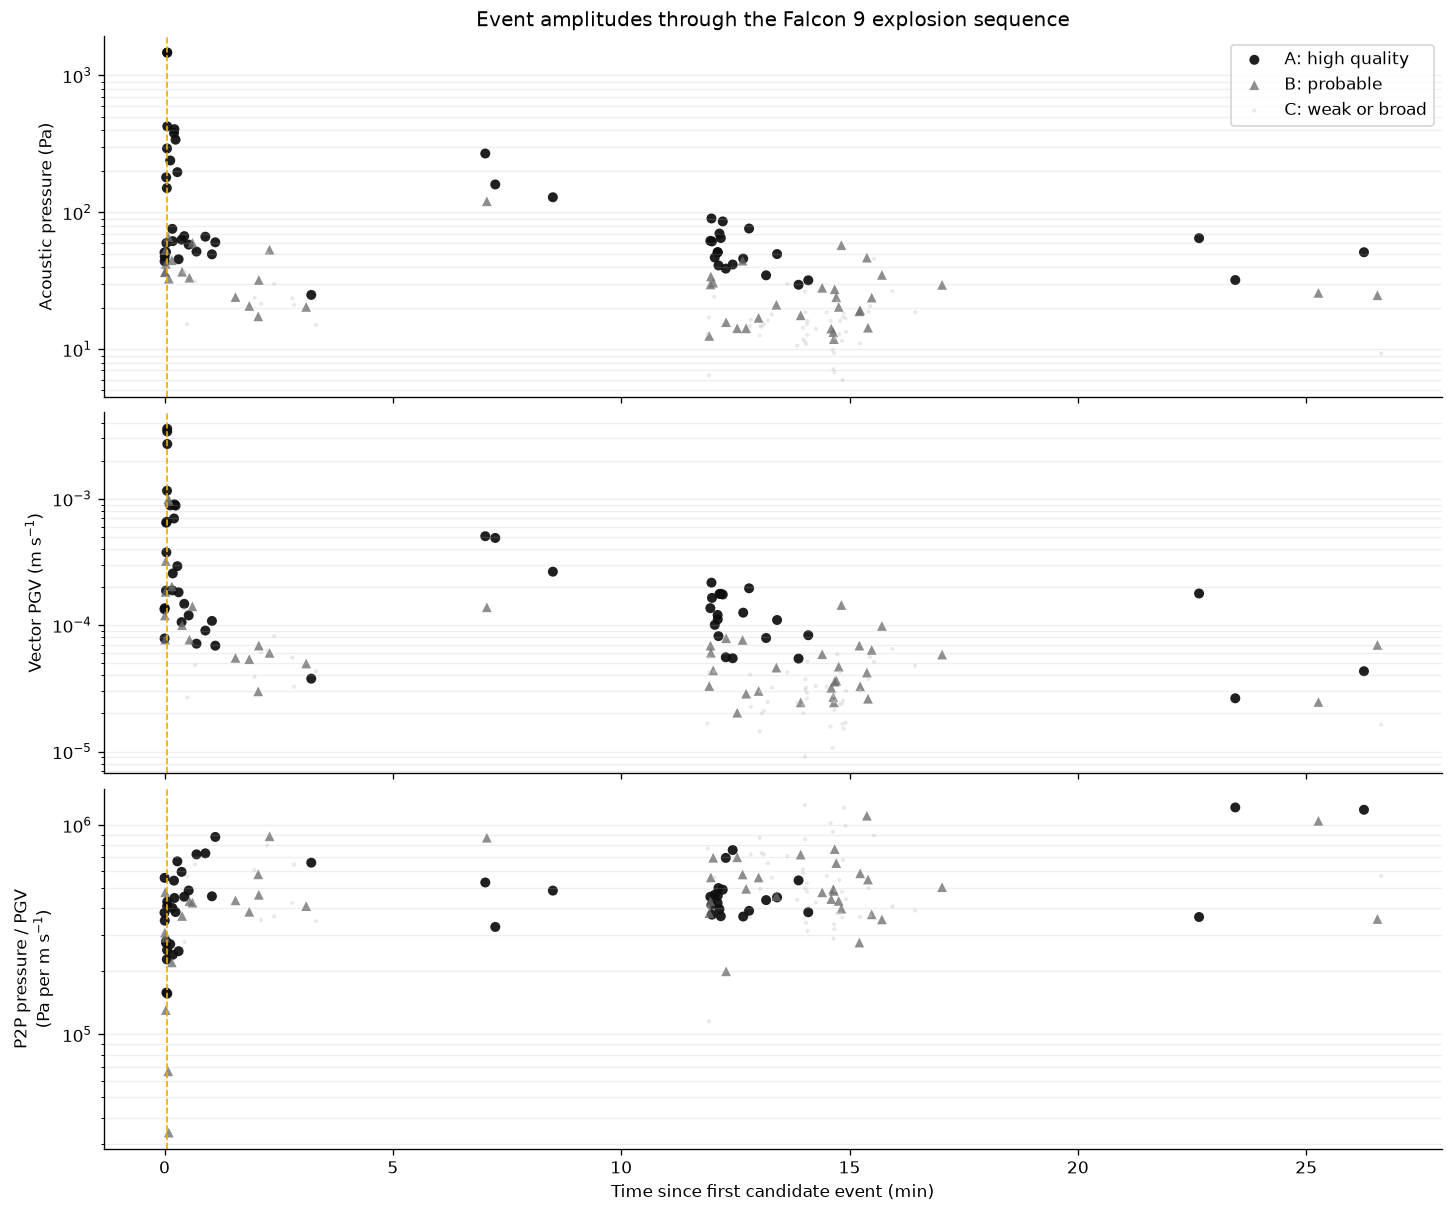

In [77]:
QUALITY_STYLE = {
    "A_high_quality": dict(marker="o", s=36, alpha=0.92, color="0.05", label="A: high quality"),
    "B_probable": dict(marker="^", s=34, alpha=0.76, color="0.42", label="B: probable"),
    "C_weak_or_broad": dict(marker=".", s=24, alpha=0.42, color="0.80", label="C: weak or broad"),
}


def scatter_by_quality(ax, frame, x, y):
    artist = None
    for quality_class, style in QUALITY_STYLE.items():
        subset = frame.loc[frame["solution_quality_class"] == quality_class]
        if subset.empty:
            continue
        artist = ax.scatter(subset[x], subset[y], edgecolor="none", **style)
    return artist


fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True, constrained_layout=True)
scatter_by_quality(axes[0], measurements, "elapsed_time_min", "acoustic_stack_peak_to_peak_pa")
axes[0].set_yscale("log")
axes[0].set_ylabel("Acoustic pressure (Pa)")
axes[0].set_title("Event amplitudes through the Falcon 9 explosion sequence")
axes[0].legend()

scatter_by_quality(axes[1], measurements, "elapsed_time_min", "pgv_vector_mps")
axes[1].set_yscale("log")
axes[1].set_ylabel("Vector PGV (m s$^{-1}$)")

scatter_by_quality(axes[2], measurements, "elapsed_time_min", "p2p_pressure_to_vector_pgv")
axes[2].set_yscale("log")
axes[2].set_ylabel("P2P pressure / PGV\n(Pa per m s$^{-1}$)")
axes[2].set_xlabel("Time since first candidate event (min)")

for ax in axes:
    ax.grid(True, which="both", axis="y", alpha=0.2)
    principal = measurements.loc[measurements["event_number"] == PRINCIPAL_EXPLOSION_EVENT_NUMBER]
    if not principal.empty:
        ax.axvline(float(principal.iloc[0]["elapsed_time_min"]), color="orange", ls="--", lw=1)

fig.savefig(FIGURE_DIR / "acoustic_seismic_amplitudes_vs_time.pdf", bbox_inches="tight")
plt.show()


## Peak-to-peak pressure versus vector PGV

On logarithmic axes, a constant pressure/PGV amplitude ratio is a line of slope
one:

\[
p_{p2p}=R_{P/V}\,\mathrm{PGV}_{3C}.
\]

The guide lines make relative atmospheric versus ground coupling visually
explicit. They are not detection thresholds or energy-ratio contours.


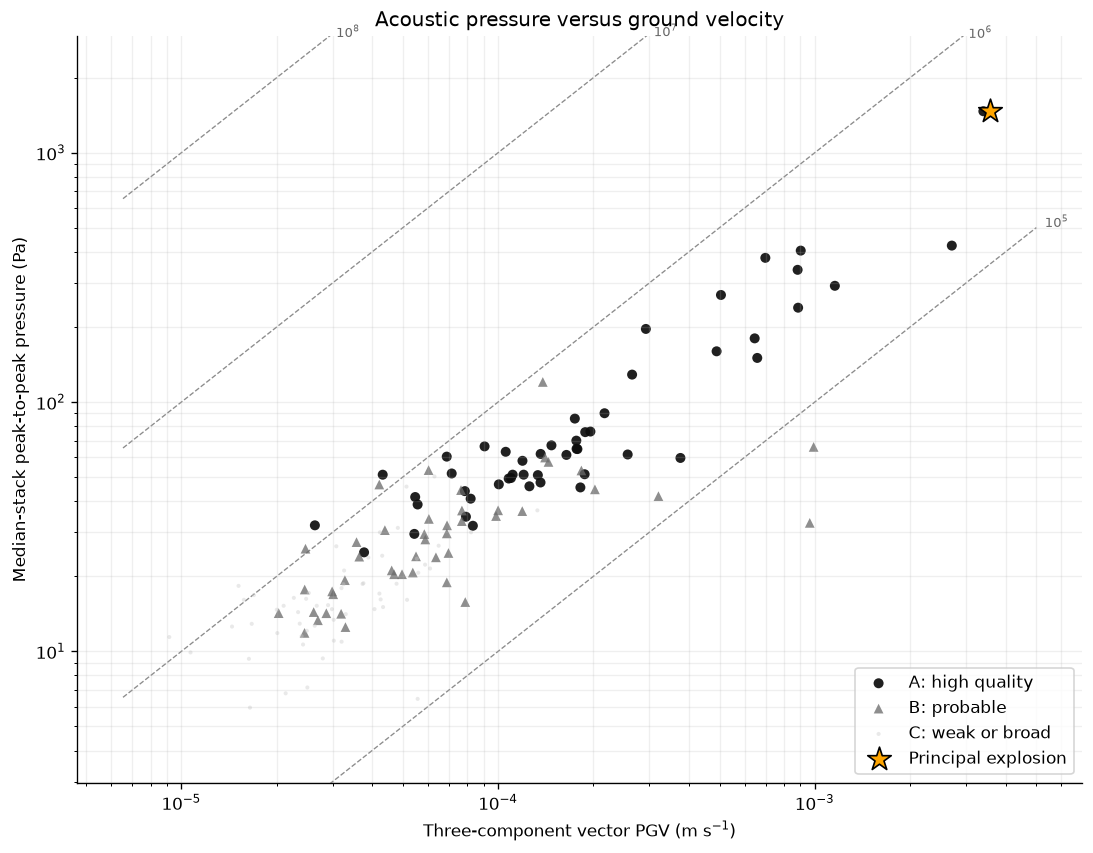

In [78]:
valid = measurements.loc[
    np.isfinite(measurements["acoustic_stack_peak_to_peak_pa"])
    & (measurements["acoustic_stack_peak_to_peak_pa"] > 0)
    & np.isfinite(measurements["pgv_vector_mps"])
    & (measurements["pgv_vector_mps"] > 0)
].copy()

fig, ax = plt.subplots(figsize=(9, 7), constrained_layout=True)
for quality_class, style in QUALITY_STYLE.items():
    subset = valid.loc[valid["solution_quality_class"] == quality_class]
    if subset.empty:
        continue
    ax.scatter(
        subset["pgv_vector_mps"], subset["acoustic_stack_peak_to_peak_pa"],
        edgecolor="none", **style,
    )

xmin, xmax = valid["pgv_vector_mps"].min(), valid["pgv_vector_mps"].max()
xline = np.logspace(np.log10(xmin / 1.4), np.log10(xmax * 1.4), 300)
for ratio in RATIO_GUIDES_PA_PER_MPS:
    yline = ratio * xline
    ax.plot(xline, yline, color="0.55", lw=0.8, ls="--", zorder=0)
    inside = (yline >= valid["acoustic_stack_peak_to_peak_pa"].min() / 2) & (yline <= valid["acoustic_stack_peak_to_peak_pa"].max() * 2)
    if np.any(inside):
        idx = np.flatnonzero(inside)[-1]
        ax.text(xline[idx], yline[idx], f"  $10^{{{int(np.log10(ratio))}}}$", color="0.4", fontsize=8)

principal = valid.loc[valid["event_number"] == PRINCIPAL_EXPLOSION_EVENT_NUMBER]
if not principal.empty:
    row = principal.iloc[0]
    ax.scatter(row["pgv_vector_mps"], row["acoustic_stack_peak_to_peak_pa"], marker="*", s=220,
               facecolor="orange", edgecolor="black", zorder=5, label="Principal explosion")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylim(valid["acoustic_stack_peak_to_peak_pa"].min() / 2, valid["acoustic_stack_peak_to_peak_pa"].max() * 2)
ax.set_xlabel("Three-component vector PGV (m s$^{-1}$)")
ax.set_ylabel("Median-stack peak-to-peak pressure (Pa)")
ax.set_title("Acoustic pressure versus ground velocity")
ax.grid(True, which="both", alpha=0.2)
ax.legend()
fig.savefig(FIGURE_DIR / "peak_to_peak_pressure_vs_vector_pgv.pdf", bbox_inches="tight")
plt.show()


## Peak-to-peak pressure versus vertical PGV

This companion plot replaces the three-component vector amplitude with vertical
PGV (`DHZ`). Its diagonal guides therefore represent

\[
p_{p2p}/\mathrm{PGV}_{Z}
\quad [\mathrm{Pa}\,(\mathrm{m\,s^{-1}})^{-1}].
\]

Comparing the vertical and vector versions shows whether horizontal ground motion
materially changes the apparent acoustic–seismic amplitude relationship.


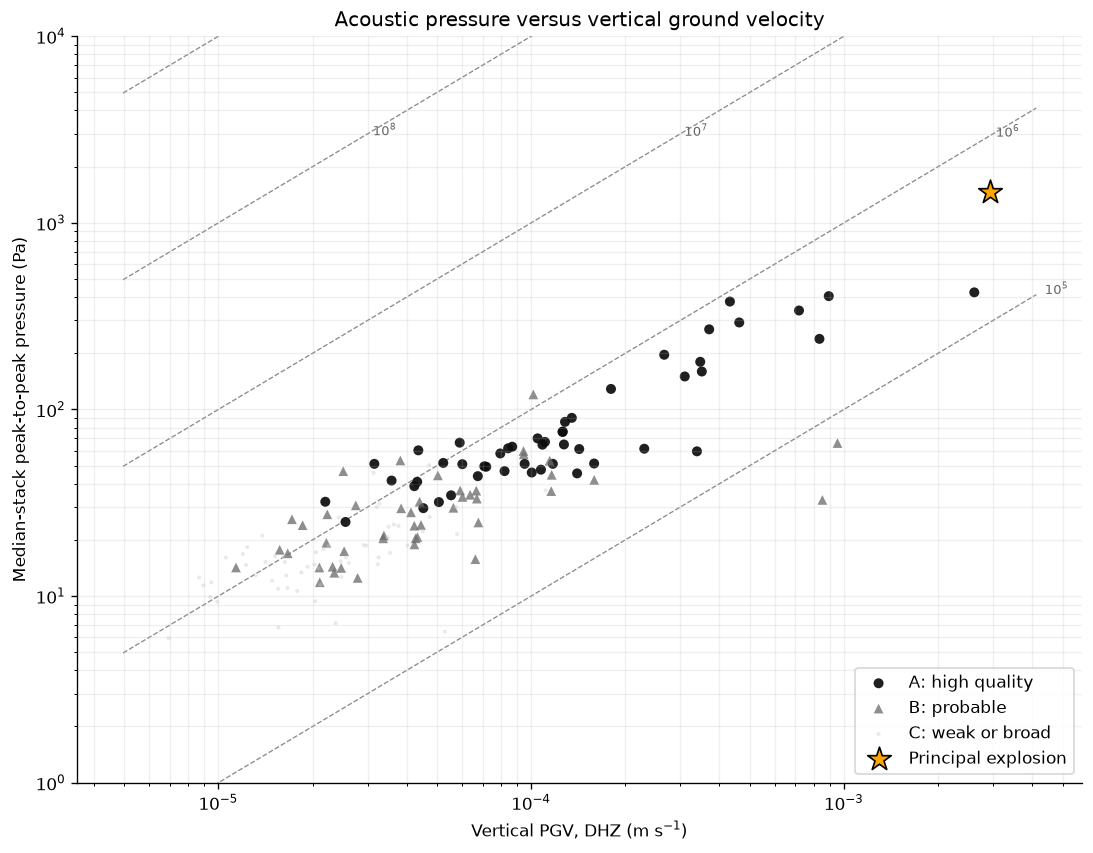

In [79]:
valid_vertical = measurements.loc[
    np.isfinite(measurements["acoustic_stack_peak_to_peak_pa"])
    & (measurements["acoustic_stack_peak_to_peak_pa"] > 0)
    & np.isfinite(measurements["pgv_dhz_mps"])
    & (measurements["pgv_dhz_mps"] > 0)
].copy()

fig, ax = plt.subplots(figsize=(9, 7), constrained_layout=True)
for quality_class, style in QUALITY_STYLE.items():
    subset = valid_vertical.loc[valid_vertical["solution_quality_class"] == quality_class]
    if subset.empty:
        continue
    ax.scatter(
        subset["pgv_dhz_mps"],
        subset["acoustic_stack_peak_to_peak_pa"],
        edgecolor="none",
        **style,
    )

xmin = valid_vertical["pgv_dhz_mps"].min()
xmax = valid_vertical["pgv_dhz_mps"].max()
xline = np.logspace(np.log10(xmin / 1.4), np.log10(xmax * 1.4), 300)

for ratio in RATIO_GUIDES_PA_PER_MPS:
    yline = ratio * xline
    ax.plot(xline, yline, color="0.55", lw=0.8, ls="--", zorder=0)
    inside = (
        (yline >= valid_vertical["acoustic_stack_peak_to_peak_pa"].min() / 2)
        & (yline <= valid_vertical["acoustic_stack_peak_to_peak_pa"].max() * 2)
    )
    if np.any(inside):
        idx = np.flatnonzero(inside)[-1]
        ax.text(
            xline[idx], yline[idx],
            f"  $10^{{{int(np.log10(ratio))}}}$",
            color="0.4", fontsize=8,
        )

principal = valid_vertical.loc[
    valid_vertical["event_number"] == PRINCIPAL_EXPLOSION_EVENT_NUMBER
]
if not principal.empty:
    row = principal.iloc[0]
    ax.scatter(
        row["pgv_dhz_mps"],
        row["acoustic_stack_peak_to_peak_pa"],
        marker="*", s=220, facecolor="orange", edgecolor="black",
        zorder=5, label="Principal explosion",
    )

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylim(1, 10000)
ax.set_xlabel("Vertical PGV, DHZ (m s$^{-1}$)")
ax.set_ylabel("Median-stack peak-to-peak pressure (Pa)")
ax.set_title("Acoustic pressure versus vertical ground velocity")
ax.grid(True, which="both", alpha=0.2)
ax.legend()
fig.savefig(
    FIGURE_DIR / "peak_to_peak_pressure_vs_vertical_pgv.pdf",
    bbox_inches="tight",
)
plt.show()


## SNR, window capture, and the apparent coupling relationship

The low-amplitude part of the pressure–PGV diagram may be controlled by acoustic
and seismic noise floors rather than a change in source physics. The following
diagnostics therefore display the dimensional pressure/PGV ratio against PGV,
colored separately by seismic and acoustic SNR.

The provisional high-quality regression subset requires:

- vector PGV SNR ≥ 5;
- acoustic stack peak-to-peak SNR ≥ 5;
- event-window PGV ≥ 70% of the maximum PGV in the saved segment.

These are configurable quality criteria, not proposed catalogue boundaries.


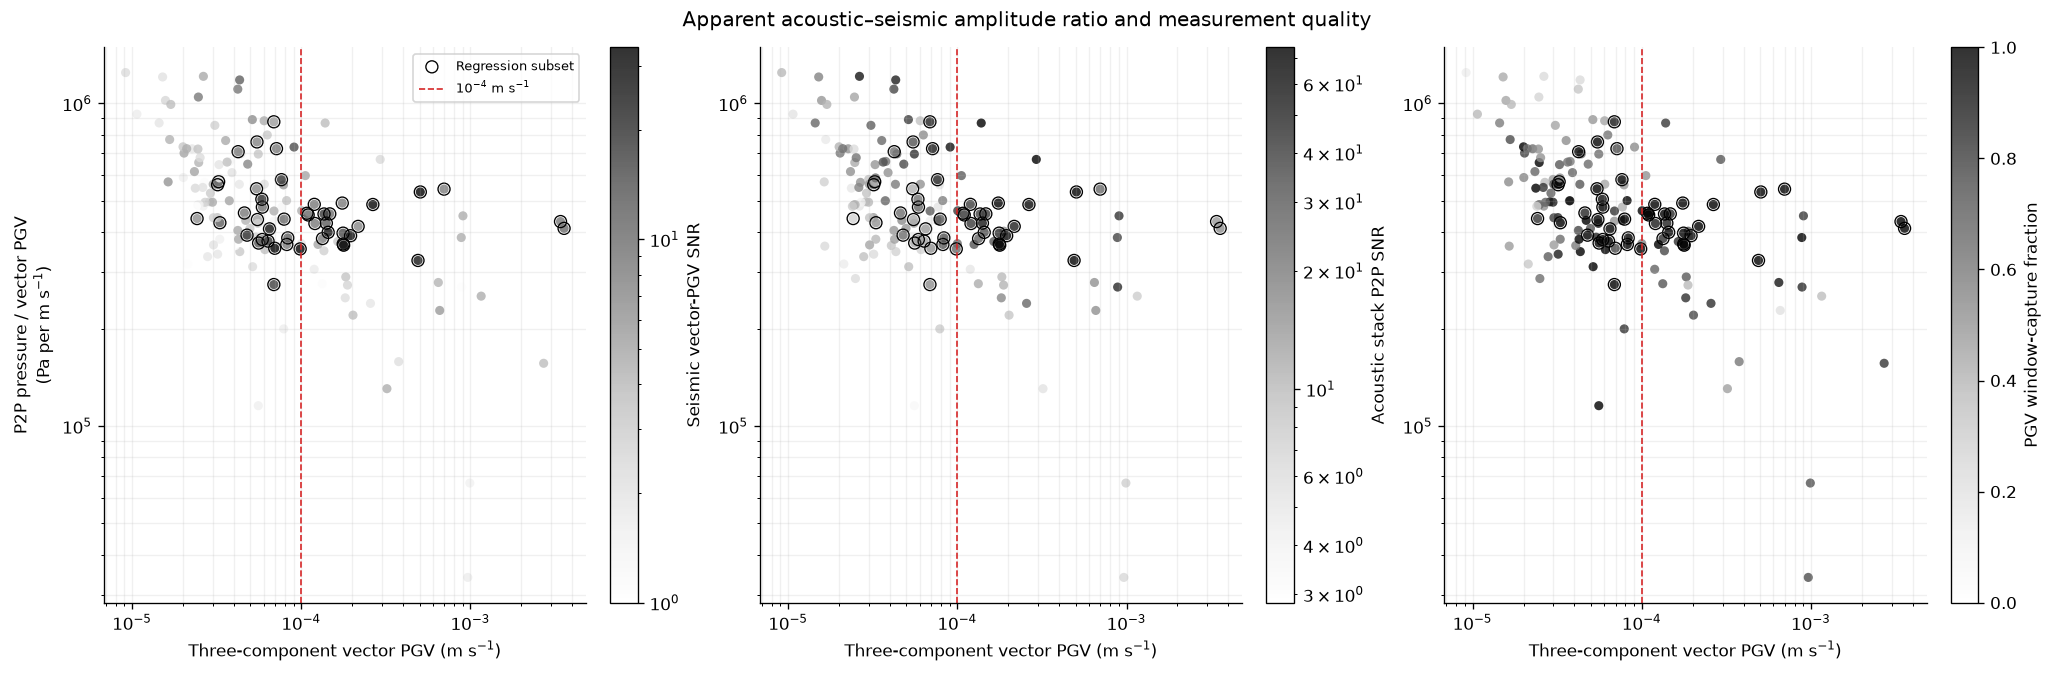

,pgv_vector_snr,acoustic_stack_p2p_snr,pgv_window_capture_fraction,p2p_pressure_to_vector_pgv
passes_regression_quality,,,,
False,2.739643,12.834851,0.674887,485795.380811
True,9.673456,27.673341,1.000000,433606.417290


In [80]:
MIN_REGRESSION_SEISMIC_SNR = 5.0
MIN_REGRESSION_ACOUSTIC_SNR = 5.0
MIN_REGRESSION_CAPTURE_FRACTION = 0.70

ratio_valid = measurements.loc[
    np.isfinite(measurements["pgv_vector_mps"])
    & (measurements["pgv_vector_mps"] > 0)
    & np.isfinite(measurements["p2p_pressure_to_vector_pgv"])
    & (measurements["p2p_pressure_to_vector_pgv"] > 0)
].copy()

ratio_valid["passes_regression_quality"] = (
    (ratio_valid["pgv_vector_snr"] >= MIN_REGRESSION_SEISMIC_SNR)
    & (ratio_valid["acoustic_stack_p2p_snr"] >= MIN_REGRESSION_ACOUSTIC_SNR)
    & (ratio_valid["pgv_window_capture_fraction"] >= MIN_REGRESSION_CAPTURE_FRACTION)
)
measurements["passes_regression_quality"] = measurements["event_number"].isin(
    ratio_valid.loc[ratio_valid["passes_regression_quality"], "event_number"]
)
measurements.to_csv(OUTPUT_ROOT / "event_acoustic_seismic_amplitudes.csv", index=False)

fig, axes = plt.subplots(1, 3, figsize=(17, 5.5), constrained_layout=True)
color_specs = [
    ("pgv_vector_snr", "Seismic vector-PGV SNR"),
    ("acoustic_stack_p2p_snr", "Acoustic stack P2P SNR"),
    ("pgv_window_capture_fraction", "PGV window-capture fraction"),
]

for ax, (column, label) in zip(axes, color_specs):
    values = ratio_valid[column].to_numpy(float)
    finite_positive = values[np.isfinite(values) & (values > 0)]
    if column.endswith("snr") and finite_positive.size:
        vmin = max(1.0, float(np.nanpercentile(finite_positive, 2)))
        vmax = max(vmin * 1.01, float(np.nanpercentile(finite_positive, 98)))
        norm = LogNorm(vmin=vmin, vmax=vmax)
    else:
        norm = plt.Normalize(vmin=0, vmax=1)
    artist = ax.scatter(
        ratio_valid["pgv_vector_mps"],
        ratio_valid["p2p_pressure_to_vector_pgv"],
        c=ratio_valid[column], cmap="Greys", norm=norm,
        s=30, alpha=0.8, edgecolor="none",
    )
    selected = ratio_valid.loc[ratio_valid["passes_regression_quality"]]
    ax.scatter(
        selected["pgv_vector_mps"], selected["p2p_pressure_to_vector_pgv"],
        facecolor="none", edgecolor="black", s=52, lw=0.8,
        label="Regression subset",
    )
    ax.axvline(1e-4, color="tab:red", ls="--", lw=1, label="$10^{-4}$ m s$^{-1}$")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Three-component vector PGV (m s$^{-1}$)")
    ax.grid(True, which="both", alpha=0.18)
    fig.colorbar(artist, ax=ax, label=label)

axes[0].set_ylabel("P2P pressure / vector PGV\n(Pa per m s$^{-1}$)")
axes[0].legend(fontsize=8)
fig.suptitle("Apparent acoustic–seismic amplitude ratio and measurement quality")
fig.savefig(FIGURE_DIR / "pressure_pgv_ratio_vs_pgv_colored_by_quality.pdf", bbox_inches="tight")
plt.show()

display(ratio_valid.groupby("passes_regression_quality")[[
    "pgv_vector_snr", "acoustic_stack_p2p_snr", "pgv_window_capture_fraction",
    "p2p_pressure_to_vector_pgv",
]].median())


## Measurement-quality log–log regression

Events are retained when pressure and vector-PGV SNR are both at least 5 and
the event window contains at least 70% of the maximum vector PGV in the saved
segment. For this independently defined measurement-quality subset,

\[
\log_{10}(p_{p2p})=a+b\log_{10}(\mathrm{PGV}_{3C}).
\]

Ordinary least squares is the primary descriptive fit. A 5,000-resample event
bootstrap, leave-one-out fits, exclusion of the principal explosion, Spearman
rank correlation, and an equal-weight orthogonal-distance fit test robustness.
The orthogonal fit is a sensitivity test because event-specific amplitude
uncertainties are not available.

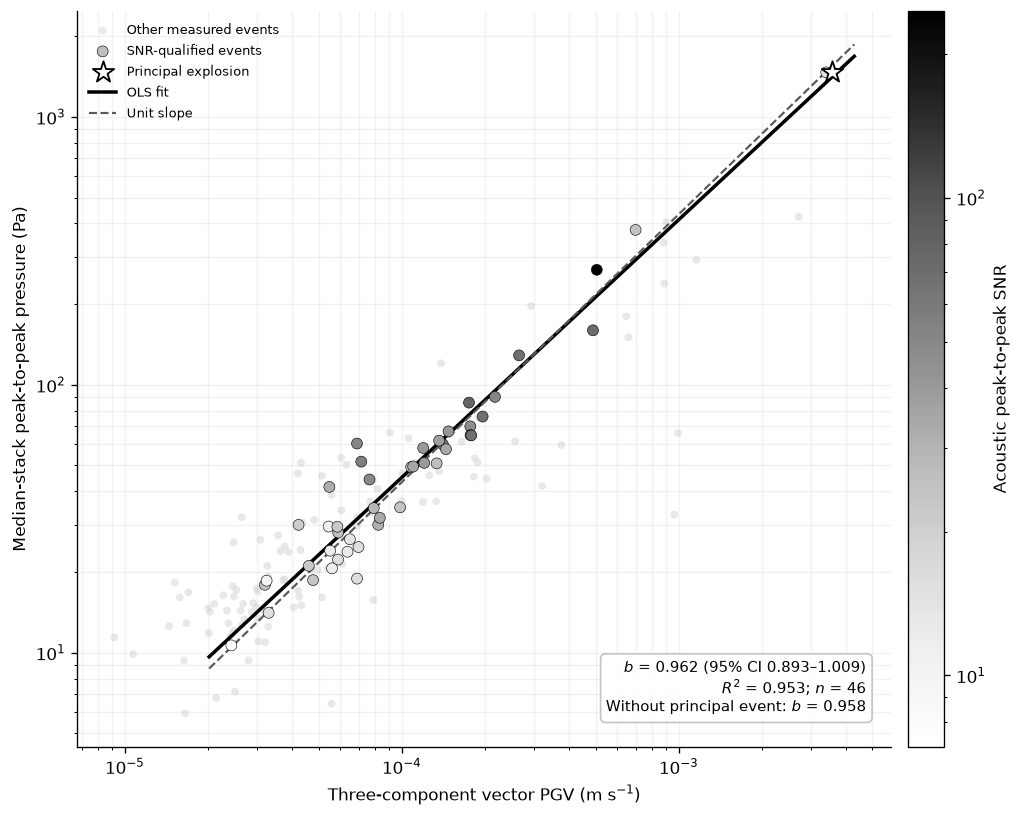

,0
n_events,46
intercept_log10_pa,5.503471
slope,0.96223
slope_standard_error,0.032374
slope_bootstrap_ci_low,0.893367
slope_bootstrap_ci_high,1.008831
r_value,0.97599
r_squared,0.952557
p_value_for_zero_slope,0.0
spearman_rho,0.930928


,analysis,n_events,slope,r_squared
0,full measurement-quality subset,46,0.962230,0.952557
1,principal explosion excluded,45,0.958416,0.937069
2,leave-one-out minimum,45,0.951539,0.937069
3,leave-one-out maximum,45,0.970885,0.961706
4,equal-weight orthogonal regression,46,0.985557,NaN


In [81]:
from scipy.odr import Model, ODR, RealData
from scipy.stats import spearmanr

regression_events = ratio_valid.loc[
    ratio_valid["passes_regression_quality"]
].copy()

if len(regression_events) < 3:
    raise ValueError("Too few measurement-quality events for regression")

x = np.log10(regression_events["pgv_vector_mps"].to_numpy(float))
y = np.log10(regression_events["acoustic_stack_peak_to_peak_pa"].to_numpy(float))
fit = linregress(x, y)

rng = np.random.default_rng(20260716)
bootstrap_slopes = []
for _ in range(5000):
    indices = rng.integers(0, len(x), len(x))
    if np.unique(x[indices]).size >= 2:
        bootstrap_slopes.append(linregress(x[indices], y[indices]).slope)
slope_ci = np.nanpercentile(bootstrap_slopes, [2.5, 97.5])

leave_one_out_rows = []
for omitted_index, omitted_event in enumerate(regression_events["event_number"]):
    keep = np.arange(len(x)) != omitted_index
    omitted_fit = linregress(x[keep], y[keep])
    leave_one_out_rows.append({
        "omitted_event_number": int(omitted_event),
        "slope": float(omitted_fit.slope),
        "r_squared": float(omitted_fit.rvalue ** 2),
    })
leave_one_out = pd.DataFrame(leave_one_out_rows)

without_principal = regression_events[
    regression_events["event_number"] != PRINCIPAL_EXPLOSION_EVENT_NUMBER
].copy()
xp = np.log10(without_principal["pgv_vector_mps"].to_numpy(float))
yp = np.log10(without_principal["acoustic_stack_peak_to_peak_pa"].to_numpy(float))
fit_without_principal = linregress(xp, yp)

rank_result = spearmanr(x, y)
orthogonal_model = Model(lambda beta, predictor: beta[0] + beta[1] * predictor)
orthogonal_result = ODR(
    RealData(x, y), orthogonal_model, beta0=[fit.intercept, fit.slope]
).run()

x_plot = np.linspace(x.min() - 0.08, x.max() + 0.08, 300)
y_fit = fit.intercept + fit.slope * x_plot
median_log_ratio = np.nanmedian(y - x)
y_slope_one = median_log_ratio + x_plot

fig, ax = plt.subplots(figsize=(8.4, 6.7), constrained_layout=True)
ax.scatter(
    ratio_valid["pgv_vector_mps"], ratio_valid["acoustic_stack_peak_to_peak_pa"],
    color="0.86", s=22, alpha=0.62, edgecolor="none", label="Other measured events",
)
scatter = ax.scatter(
    regression_events["pgv_vector_mps"],
    regression_events["acoustic_stack_peak_to_peak_pa"],
    c=regression_events["acoustic_stack_p2p_snr"], cmap="Greys", norm=LogNorm(),
    s=43, edgecolor="black", lw=0.35, label="SNR-qualified events", zorder=3,
)
principal = regression_events[
    regression_events["event_number"] == PRINCIPAL_EXPLOSION_EVENT_NUMBER
]
if not principal.empty:
    ax.scatter(
        principal["pgv_vector_mps"], principal["acoustic_stack_peak_to_peak_pa"],
        marker="*", s=180, facecolor="white", edgecolor="black", lw=1.1,
        zorder=5, label="Principal explosion",
    )
ax.plot(10 ** x_plot, 10 ** y_fit, color="black", lw=2.1, label="OLS fit")
ax.plot(
    10 ** x_plot, 10 ** y_slope_one, color="0.35", ls="--", lw=1.3,
    label="Unit slope",
)
ax.text(
    0.97, 0.04,
    "$b$ = " + f"{fit.slope:.3f} (95% CI {slope_ci[0]:.3f}–{slope_ci[1]:.3f})\n"
    + "$R^2$ = " + f"{fit.rvalue ** 2:.3f}; $n$ = {len(regression_events)}\n"
    + f"Without principal event: $b$ = {fit_without_principal.slope:.3f}",
    transform=ax.transAxes, ha="right", va="bottom", fontsize=9,
    bbox=dict(facecolor="white", edgecolor="0.75", alpha=0.92, boxstyle="round,pad=0.35"),
)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Three-component vector PGV (m s$^{-1}$)")
ax.set_ylabel("Median-stack peak-to-peak pressure (Pa)")
ax.grid(True, which="both", alpha=0.16)
ax.legend(frameon=False, fontsize=8, loc="upper left")
fig.colorbar(scatter, ax=ax, label="Acoustic peak-to-peak SNR", pad=0.02)
fig.savefig(FIGURE_DIR / "publication_pressure_pgv_regression.pdf", bbox_inches="tight")
plt.show()

regression_summary = pd.DataFrame([{
    "n_events": len(regression_events),
    "intercept_log10_pa": fit.intercept,
    "slope": fit.slope,
    "slope_standard_error": fit.stderr,
    "slope_bootstrap_ci_low": slope_ci[0],
    "slope_bootstrap_ci_high": slope_ci[1],
    "r_value": fit.rvalue,
    "r_squared": fit.rvalue ** 2,
    "p_value_for_zero_slope": fit.pvalue,
    "spearman_rho": rank_result.statistic,
    "spearman_p_value": rank_result.pvalue,
    "equal_weight_odr_slope": orthogonal_result.beta[1],
    "equal_weight_odr_slope_sd": orthogonal_result.sd_beta[1],
    "median_pressure_pgv_ratio": 10 ** median_log_ratio,
    "slope_one_inside_bootstrap_ci": bool(slope_ci[0] <= 1.0 <= slope_ci[1]),
}])
regression_sensitivity = pd.DataFrame([{
    "analysis": "full measurement-quality subset", "n_events": len(x),
    "slope": fit.slope, "r_squared": fit.rvalue ** 2,
}, {
    "analysis": "principal explosion excluded", "n_events": len(xp),
    "slope": fit_without_principal.slope,
    "r_squared": fit_without_principal.rvalue ** 2,
}, {
    "analysis": "leave-one-out minimum", "n_events": len(x) - 1,
    "slope": leave_one_out["slope"].min(),
    "r_squared": leave_one_out["r_squared"].min(),
}, {
    "analysis": "leave-one-out maximum", "n_events": len(x) - 1,
    "slope": leave_one_out["slope"].max(),
    "r_squared": leave_one_out["r_squared"].max(),
}, {
    "analysis": "equal-weight orthogonal regression", "n_events": len(x),
    "slope": orthogonal_result.beta[1], "r_squared": np.nan,
}])
regression_summary.to_csv(OUTPUT_ROOT / "pressure_pgv_regression_summary.csv", index=False)
regression_sensitivity.to_csv(OUTPUT_ROOT / "pressure_pgv_regression_sensitivity.csv", index=False)
leave_one_out.to_csv(OUTPUT_ROOT / "pressure_pgv_regression_leave_one_out.csv", index=False)
display(regression_summary.T)
display(regression_sensitivity)


## Frequency-domain analysis

Frequency-domain products use a common set of helpers and explicit frequency
limits. Event spectra are restricted to 0.9–90 Hz because the approximately
1.1-s event records have an independent resolution near 0.91 Hz. Continuous
Phase I spectra extend to 0.1 Hz using 10-s Welch segments.

The robust median pressure stack remains the amplitude estimator above. A
geometry-aligned arithmetic-mean pressure beam is used for cross-spectral
transfer estimation because it is a linear operation.

In [82]:
from scipy.signal import csd, periodogram, welch

SPECTRAL_QUALITY_CLASS = "A_high_quality"
SPECTRAL_MIN_HZ = 0.9
SPECTRAL_MAX_HZ = 90.0
SPECTRAL_BINS_PER_DECADE = 15
SPECTRAL_TUKEY_ALPHA = 0.20
SPECTRAL_MIN_EVENTS_PER_BIN = 5

TRANSFER_PHASE1_MIN_HZ = 0.1
TRANSFER_COHERENCE_DISPLAY_THRESHOLD = 0.50
TRANSFER_SIGNIFICANCE_ALPHA = 0.05
TRANSFER_BOOTSTRAP_REPLICATES = 1000
TRANSFER_PERMUTATION_REPLICATES = 1000
TRANSFER_PLOT_MIN_HZ = 0.9
TRANSFER_PLOT_MAX_HZ = 50.0


def longest_contiguous_true_run(mask):
    """Return the slice spanning the longest contiguous True run."""
    mask = np.asarray(mask, dtype=bool)
    if not np.any(mask):
        return slice(0, 0)
    padded = np.r_[False, mask, False]
    changes = np.diff(padded.astype(int))
    starts = np.flatnonzero(changes == 1)
    ends = np.flatnonzero(changes == -1)
    best = int(np.argmax(ends - starts))
    return slice(int(starts[best]), int(ends[best]))


def logarithmic_edges(minimum_hz, maximum_hz, bins_per_decade):
    count = int(np.ceil(np.log10(maximum_hz / minimum_hz) * bins_per_decade))
    return np.geomspace(minimum_hz, maximum_hz, count + 1)


def log_bin_geometric_median(frequency_hz, values, bin_edges_hz):
    output = np.full(len(bin_edges_hz) - 1, np.nan)
    for index, (low, high) in enumerate(zip(bin_edges_hz[:-1], bin_edges_hz[1:])):
        include = (
            (frequency_hz >= low) & (frequency_hz < high)
            & np.isfinite(values) & (values > 0)
        )
        if np.any(include):
            output[index] = float(10.0 ** np.nanmedian(np.log10(values[include])))
    return output


def summarize_spectral_matrix(matrix, frequency_hz, minimum_events=5):
    rows = []
    for frequency in frequency_hz:
        values = matrix[frequency].to_numpy(float)
        values = values[np.isfinite(values) & (values > 0)]
        row = {
            "frequency_hz": float(frequency),
            "event_count": int(len(values)),
            "geometric_median": np.nan,
            "percentile_16": np.nan,
            "percentile_84": np.nan,
        }
        if len(values) >= minimum_events:
            log_values = np.log10(values)
            row.update({
                "geometric_median": float(10.0 ** np.nanmedian(log_values)),
                "percentile_16": float(10.0 ** np.nanpercentile(log_values, 16)),
                "percentile_84": float(10.0 ** np.nanpercentile(log_values, 84)),
            })
        rows.append(row)
    return pd.DataFrame(rows)


spectral_bin_edges_hz = logarithmic_edges(
    SPECTRAL_MIN_HZ, SPECTRAL_MAX_HZ, SPECTRAL_BINS_PER_DECADE
)
spectral_frequency_hz = np.sqrt(spectral_bin_edges_hz[:-1] * spectral_bin_edges_hz[1:])


## Acoustic and vertical-seismic amplitude spectra

For each class-A event, pressure and DHZ periodograms are calculated from the
same finite samples after linear detrending and a Tukey taper. Thin curves show
individual events; the geometric median and 16th–84th percentiles summarize the
event ensemble.

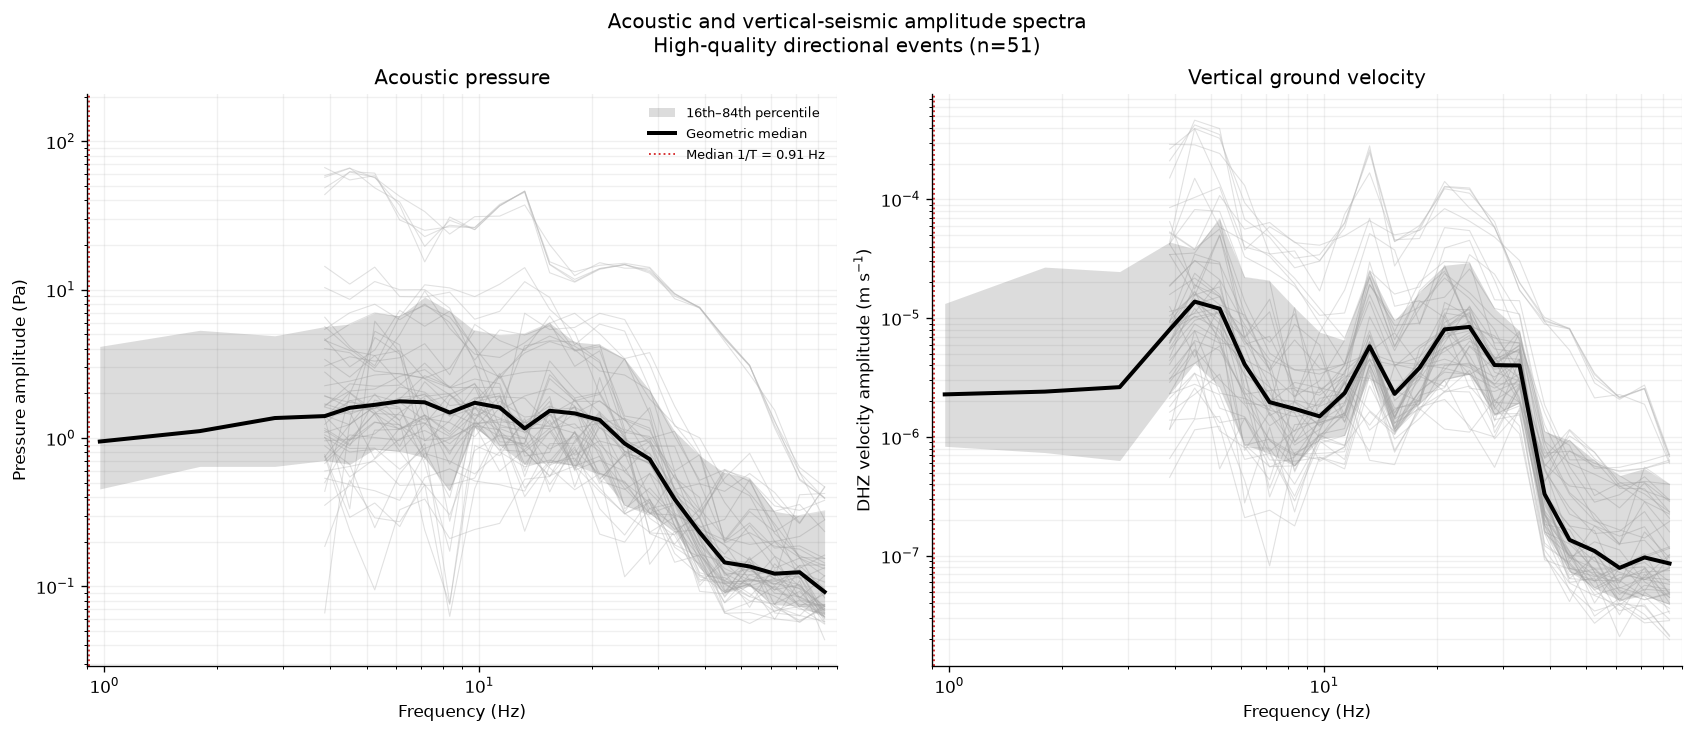

Acoustic spectral summary: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/100_measure_event_amplitudes_and_acoustic_seismic_coupling/high_quality_acoustic_amplitude_spectral_summary.csv
Vertical-seismic spectral summary: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/100_measure_event_amplitudes_and_acoustic_seismic_coupling/high_quality_vertical_seismic_amplitude_spectral_summary.csv


,frequency_hz,event_count,geometric_median,percentile_16,percentile_84
0,0.971798,51,0.947340,0.453669,4.146996
4,1.795736,51,1.113336,0.643730,5.326116
7,2.846050,51,1.363876,0.643824,4.890160
9,3.868796,51,1.405875,0.705038,5.639846
10,4.510685,51,1.598657,0.664627,5.865552


,frequency_hz,event_count,geometric_median,percentile_16,percentile_84
0,0.971798,51,0.000002,8.363060e-07,0.000013
4,1.795736,51,0.000002,7.407469e-07,0.000027
7,2.846050,51,0.000003,6.342824e-07,0.000025
9,3.868796,51,0.000008,2.307697e-06,0.000044
10,4.510685,51,0.000014,4.172562e-06,0.000038


In [83]:
high_quality_events = measurements.loc[
    measurements["solution_quality_class"]
    == SPECTRAL_QUALITY_CLASS,
    [
        "event_number",
        "event_time",
        "maximum_coherence_score",
    ],
].copy()

acoustic_rows = []
vertical_rows = []
spectral_metadata_rows = []

for event in high_quality_events.itertuples(index=False):

    event_number = int(event.event_number)
    diagnostic = diagnostic_data.get(event_number)

    if diagnostic is None:
        continue

    times_s = np.asarray(
        diagnostic["times_s"],
        dtype=float,
    )
    pressure_pa = np.asarray(
        diagnostic["median_pressure_stack"],
        dtype=float,
    )
    vertical_velocity_mps = np.asarray(
        diagnostic["corrected"]["DHZ"],
        dtype=float,
    )

    finite = (
        np.isfinite(times_s)
        & np.isfinite(pressure_pa)
        & np.isfinite(vertical_velocity_mps)
    )

    usable = longest_contiguous_true_run(finite)

    times = times_s[usable]
    pressure = pressure_pa[usable]
    vertical_velocity = vertical_velocity_mps[usable]

    if len(times) < 8:
        continue

    dt_s = float(
        np.nanmedian(np.diff(times))
    )

    if not np.isfinite(dt_s) or dt_s <= 0:
        continue

    sampling_rate_hz = 1.0 / dt_s
    duration_s = float(
        times[-1] - times[0] + dt_s
    )
    independent_minimum_hz = 1.0 / duration_s
    nyquist_hz = 0.5 * sampling_rate_hz

    frequency_hz, pressure_power = periodogram(
        pressure,
        fs=sampling_rate_hz,
        window=("tukey", SPECTRAL_TUKEY_ALPHA),
        detrend="linear",
        scaling="spectrum",
    )

    vertical_frequency_hz, vertical_power = periodogram(
        vertical_velocity,
        fs=sampling_rate_hz,
        window=("tukey", SPECTRAL_TUKEY_ALPHA),
        detrend="linear",
        scaling="spectrum",
    )

    if not np.allclose(
        frequency_hz,
        vertical_frequency_hz,
    ):
        raise ValueError(
            f"Spectral frequency mismatch for event {event_number}"
        )

    pressure_amplitude = np.sqrt(
        np.maximum(pressure_power, 0)
    )
    vertical_amplitude = np.sqrt(
        np.maximum(vertical_power, 0)
    )

    supported = (
        (
            frequency_hz
            >= max(
                SPECTRAL_MIN_HZ,
                independent_minimum_hz,
            )
        )
        & (
            frequency_hz
            <= min(
                SPECTRAL_MAX_HZ,
                nyquist_hz,
            )
        )
    )

    binned_pressure = log_bin_geometric_median(
        frequency_hz[supported],
        pressure_amplitude[supported],
        spectral_bin_edges_hz,
    )

    binned_vertical = log_bin_geometric_median(
        frequency_hz[supported],
        vertical_amplitude[supported],
        spectral_bin_edges_hz,
    )

    spectral_metadata_rows.append({
        "event_number": event_number,
        "event_time": event.event_time,
        "maximum_coherence_score": float(
            event.maximum_coherence_score
        ),
        "samples": int(len(times)),
        "sampling_rate_hz": sampling_rate_hz,
        "duration_s": duration_s,
        "independent_minimum_frequency_hz":
            independent_minimum_hz,
        "nyquist_frequency_hz": nyquist_hz,
    })

    for frequency, amplitude in zip(
        spectral_frequency_hz,
        binned_pressure,
    ):
        acoustic_rows.append({
            "event_number": event_number,
            "frequency_hz": float(frequency),
            "pressure_amplitude_pa": float(amplitude),
        })

    for frequency, amplitude in zip(
        spectral_frequency_hz,
        binned_vertical,
    ):
        vertical_rows.append({
            "event_number": event_number,
            "frequency_hz": float(frequency),
            "vertical_velocity_amplitude_mps":
                float(amplitude),
        })


acoustic_spectra_long = pd.DataFrame(
    acoustic_rows
)
vertical_spectra_long = pd.DataFrame(
    vertical_rows
)
spectral_amplitude_metadata = pd.DataFrame(
    spectral_metadata_rows
)

if (
    acoustic_spectra_long.empty
    or vertical_spectra_long.empty
):
    raise ValueError(
        "No A-quality events produced usable amplitude spectra"
    )


acoustic_spectral_matrix = (
    acoustic_spectra_long
    .pivot(
        index="event_number",
        columns="frequency_hz",
        values="pressure_amplitude_pa",
    )
    .reindex(columns=spectral_frequency_hz)
)

vertical_spectral_matrix = (
    vertical_spectra_long
    .pivot(
        index="event_number",
        columns="frequency_hz",
        values="vertical_velocity_amplitude_mps",
    )
    .reindex(columns=spectral_frequency_hz)
)


acoustic_spectral_summary = summarize_spectral_matrix(
    acoustic_spectral_matrix,
    spectral_frequency_hz,
    minimum_events=SPECTRAL_MIN_EVENTS_PER_BIN,
)

vertical_spectral_summary = summarize_spectral_matrix(
    vertical_spectral_matrix,
    spectral_frequency_hz,
    minimum_events=SPECTRAL_MIN_EVENTS_PER_BIN,
)


# Export event spectra and frequency-bin summaries.
acoustic_spectra_long.to_csv(
    OUTPUT_ROOT
    / "high_quality_acoustic_amplitude_spectra.csv",
    index=False,
)

vertical_spectra_long.to_csv(
    OUTPUT_ROOT
    / "high_quality_vertical_seismic_amplitude_spectra.csv",
    index=False,
)

spectral_amplitude_metadata.to_csv(
    OUTPUT_ROOT
    / "high_quality_amplitude_spectral_metadata.csv",
    index=False,
)

acoustic_spectral_summary.to_csv(
    OUTPUT_ROOT
    / "high_quality_acoustic_amplitude_spectral_summary.csv",
    index=False,
)

vertical_spectral_summary.to_csv(
    OUTPUT_ROOT
    / "high_quality_vertical_seismic_amplitude_spectral_summary.csv",
    index=False,
)


# Plot individual and aggregate spectra.
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 6),
    constrained_layout=True,
)

spectral_panels = [
    (
        axes[0],
        acoustic_spectral_matrix,
        acoustic_spectral_summary,
        "Acoustic pressure",
        "Pressure amplitude (Pa)",
    ),
    (
        axes[1],
        vertical_spectral_matrix,
        vertical_spectral_summary,
        "Vertical ground velocity",
        "DHZ velocity amplitude (m s$^{-1}$)",
    ),
]

for (
    ax,
    matrix,
    summary,
    title,
    ylabel,
) in spectral_panels:

    # Individual A-quality events.
    for _, values in matrix.iterrows():
        ax.plot(
            spectral_frequency_hz,
            values.to_numpy(float),
            color="0.72",
            alpha=0.42,
            lw=0.65,
            zorder=1,
        )

    supported_summary = (
        summary["geometric_median"].notna()
    )

    summary_frequency = summary.loc[
        supported_summary,
        "frequency_hz",
    ].to_numpy(float)

    summary_median = summary.loc[
        supported_summary,
        "geometric_median",
    ].to_numpy(float)

    summary_low = summary.loc[
        supported_summary,
        "percentile_16",
    ].to_numpy(float)

    summary_high = summary.loc[
        supported_summary,
        "percentile_84",
    ].to_numpy(float)

    ax.fill_between(
        summary_frequency,
        summary_low,
        summary_high,
        color="0.25",
        alpha=0.18,
        linewidth=0,
        label="16th–84th percentile",
        zorder=2,
    )

    ax.plot(
        summary_frequency,
        summary_median,
        color="black",
        lw=2.4,
        label="Geometric median",
        zorder=3,
    )

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(
        SPECTRAL_MIN_HZ,
        SPECTRAL_MAX_HZ,
    )
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(
        True,
        which="both",
        alpha=0.18,
    )


median_resolution_hz = float(
    spectral_amplitude_metadata[
        "independent_minimum_frequency_hz"
    ].median()
)

for ax in axes:
    ax.axvline(
        median_resolution_hz,
        color="tab:red",
        ls=":",
        lw=1.1,
        label=(
            f"Median 1/T = "
            f"{median_resolution_hz:.2g} Hz"
        ),
    )

axes[0].legend(
    frameon=False,
    fontsize=8,
)

fig.suptitle(
    "Acoustic and vertical-seismic amplitude spectra\n"
    f"High-quality directional events "
    f"(n={len(spectral_amplitude_metadata)})"
)

figure_base = (
    FIGURE_DIR
    / "high_quality_acoustic_and_vertical_seismic_amplitude_spectra"
)

fig.savefig(
    figure_base.with_suffix(".pdf"),
    bbox_inches="tight",
)

plt.show()


print(
    "Acoustic spectral summary:",
    OUTPUT_ROOT
    / "high_quality_acoustic_amplitude_spectral_summary.csv",
)

print(
    "Vertical-seismic spectral summary:",
    OUTPUT_ROOT
    / "high_quality_vertical_seismic_amplitude_spectral_summary.csv",
)

display(
    acoustic_spectral_summary.loc[
        acoustic_spectral_summary[
            "geometric_median"
        ].notna()
    ].head()
)

display(
    vertical_spectral_summary.loc[
        vertical_spectral_summary[
            "geometric_median"
        ].notna()
    ].head()
)

## Typical high-quality event waveforms

To show waveform morphology independently of event size, the aligned pressure
stack and vertical ground velocity for each class-A event are locally centered
and normalized by their own maximum absolute amplitude within the event signal
window. Thin light-gray lines show individual events, the shaded region spans
the pointwise 16th–84th percentiles, and the black line is the pointwise median.
Normalization amplitudes are exported so that this morphology figure remains
traceable to the dimensional measurements.

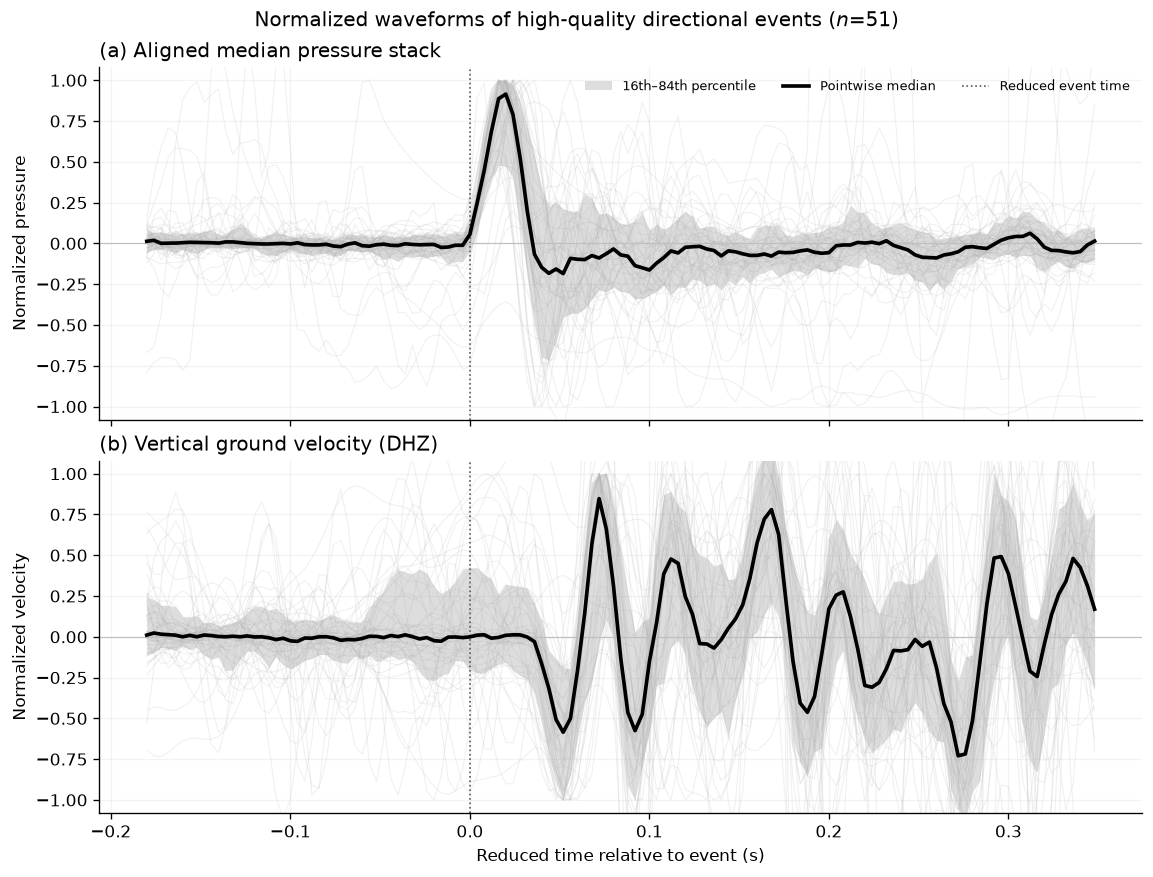

,count,mean,std,min,25%,50%,75%,max
event_number,51.0,50.784314,38.370465,1.000000,20.500000,39.000000,73.500000,151.000000
maximum_coherence_score,51.0,0.961064,0.026720,0.907537,0.943059,0.963112,0.981921,0.998398
pressure_normalization_peak_absolute_pa,51.0,124.600889,267.002508,12.640307,31.126236,38.538986,84.914310,1339.906487
vertical_normalization_peak_absolute_mps,51.0,0.000329,0.000653,0.000022,0.000061,0.000106,0.000264,0.002929
signal_start_s,51.0,0.001305,0.034879,-0.074240,-0.006385,0.000866,0.001893,0.185240
signal_end_s,51.0,0.135344,0.063303,0.049893,0.085433,0.121893,0.169933,0.350000


In [84]:
WAVEFORM_ENSEMBLE_MIN_S = -0.18
WAVEFORM_ENSEMBLE_MAX_S = 0.35
WAVEFORM_ENSEMBLE_SAMPLING_RATE_HZ = 250.0
WAVEFORM_BASELINE_WINDOW_S = (-0.18, -0.05)

waveform_time_s = np.arange(
    WAVEFORM_ENSEMBLE_MIN_S,
    WAVEFORM_ENSEMBLE_MAX_S + 0.5 / WAVEFORM_ENSEMBLE_SAMPLING_RATE_HZ,
    1.0 / WAVEFORM_ENSEMBLE_SAMPLING_RATE_HZ,
)

normalized_pressure_rows = []
normalized_vertical_rows = []
waveform_metadata_rows = []

for event in high_quality_events.itertuples(index=False):
    event_number = int(event.event_number)
    diagnostic = diagnostic_data.get(event_number)
    if diagnostic is None:
        continue

    native_time = np.asarray(diagnostic["times_s"], dtype=float)
    native_pressure = np.asarray(diagnostic["median_pressure_stack"], dtype=float)
    native_vertical = np.asarray(diagnostic["corrected"]["DHZ"], dtype=float)

    pressure = np.interp(
        waveform_time_s, native_time, native_pressure, left=np.nan, right=np.nan
    )
    vertical = np.interp(
        waveform_time_s, native_time, native_vertical, left=np.nan, right=np.nan
    )

    baseline = (
        (waveform_time_s >= WAVEFORM_BASELINE_WINDOW_S[0])
        & (waveform_time_s <= WAVEFORM_BASELINE_WINDOW_S[1])
    )
    if np.any(np.isfinite(pressure[baseline])):
        pressure = pressure - np.nanmedian(pressure[baseline])
    if np.any(np.isfinite(vertical[baseline])):
        vertical = vertical - np.nanmedian(vertical[baseline])

    signal_start_s, signal_end_s = diagnostic["signal_window"]
    signal = (
        (waveform_time_s >= signal_start_s)
        & (waveform_time_s <= signal_end_s)
    )
    pressure_scale_pa = float(np.nanmax(np.abs(pressure[signal])))
    vertical_scale_mps = float(np.nanmax(np.abs(vertical[signal])))

    if (
        not np.isfinite(pressure_scale_pa) or pressure_scale_pa <= 0
        or not np.isfinite(vertical_scale_mps) or vertical_scale_mps <= 0
    ):
        continue

    normalized_pressure = pressure / pressure_scale_pa
    normalized_vertical = vertical / vertical_scale_mps
    normalized_pressure_rows.append(normalized_pressure)
    normalized_vertical_rows.append(normalized_vertical)
    waveform_metadata_rows.append({
        "event_number": event_number,
        "event_time": event.event_time,
        "maximum_coherence_score": float(event.maximum_coherence_score),
        "pressure_normalization_peak_absolute_pa": pressure_scale_pa,
        "vertical_normalization_peak_absolute_mps": vertical_scale_mps,
        "signal_start_s": float(signal_start_s),
        "signal_end_s": float(signal_end_s),
    })

normalized_pressure_matrix = np.asarray(normalized_pressure_rows, dtype=float)
normalized_vertical_matrix = np.asarray(normalized_vertical_rows, dtype=float)
waveform_ensemble_metadata = pd.DataFrame(waveform_metadata_rows)

if len(waveform_ensemble_metadata) != len(high_quality_events):
    print(
        "WARNING: waveform ensemble retained",
        len(waveform_ensemble_metadata),
        "of",
        len(high_quality_events),
        "A-quality events",
    )


def waveform_percentile_summary(matrix):
    return {
        "median": np.nanmedian(matrix, axis=0),
        "percentile_16": np.nanpercentile(matrix, 16, axis=0),
        "percentile_84": np.nanpercentile(matrix, 84, axis=0),
        "finite_event_count": np.sum(np.isfinite(matrix), axis=0),
    }


pressure_waveform_summary = waveform_percentile_summary(normalized_pressure_matrix)
vertical_waveform_summary = waveform_percentile_summary(normalized_vertical_matrix)

waveform_summary_table = pd.DataFrame({
    "time_s": waveform_time_s,
    "pressure_median_normalized": pressure_waveform_summary["median"],
    "pressure_percentile_16_normalized": pressure_waveform_summary["percentile_16"],
    "pressure_percentile_84_normalized": pressure_waveform_summary["percentile_84"],
    "pressure_event_count": pressure_waveform_summary["finite_event_count"],
    "vertical_median_normalized": vertical_waveform_summary["median"],
    "vertical_percentile_16_normalized": vertical_waveform_summary["percentile_16"],
    "vertical_percentile_84_normalized": vertical_waveform_summary["percentile_84"],
    "vertical_event_count": vertical_waveform_summary["finite_event_count"],
})

waveform_long_rows = []
for metadata, pressure, vertical in zip(
    waveform_metadata_rows, normalized_pressure_matrix, normalized_vertical_matrix
):
    for time_s, pressure_value, vertical_value in zip(
        waveform_time_s, pressure, vertical
    ):
        waveform_long_rows.append({
            "event_number": metadata["event_number"],
            "time_s": float(time_s),
            "normalized_pressure": float(pressure_value),
            "normalized_vertical_velocity": float(vertical_value),
        })
waveform_ensemble_long = pd.DataFrame(waveform_long_rows)

waveform_ensemble_metadata.to_csv(
    OUTPUT_ROOT / "high_quality_normalized_waveform_metadata.csv", index=False
)
waveform_summary_table.to_csv(
    OUTPUT_ROOT / "high_quality_normalized_waveform_summary.csv", index=False
)
waveform_ensemble_long.to_csv(
    OUTPUT_ROOT / "high_quality_normalized_waveforms.csv", index=False
)

fig, axes = plt.subplots(2, 1, figsize=(9.5, 7.2), sharex=True, constrained_layout=True)
panels = [
    (
        axes[0], normalized_pressure_matrix, pressure_waveform_summary,
        "(a) Aligned median pressure stack", "Normalized pressure",
    ),
    (
        axes[1], normalized_vertical_matrix, vertical_waveform_summary,
        "(b) Vertical ground velocity (DHZ)", "Normalized velocity",
    ),
]

for ax, matrix, summary_values, title, ylabel in panels:
    for waveform in matrix:
        ax.plot(
            waveform_time_s, waveform, color="0.76", alpha=0.24,
            lw=0.65, zorder=1,
        )
    ax.fill_between(
        waveform_time_s,
        summary_values["percentile_16"],
        summary_values["percentile_84"],
        color="0.62", alpha=0.34, linewidth=0,
        label="16th–84th percentile", zorder=2,
    )
    ax.plot(
        waveform_time_s, summary_values["median"], color="black", lw=2.2,
        label="Pointwise median", zorder=3,
    )
    ax.axvline(0, color="0.35", ls=":", lw=1.0, label="Reduced event time")
    ax.axhline(0, color="0.75", lw=0.7)
    ax.set_ylim(-1.08, 1.08)
    ax.set_ylabel(ylabel)
    ax.set_title(title, loc="left")
    ax.grid(True, alpha=0.14)

axes[0].legend(frameon=False, fontsize=8, ncol=3, loc="upper right")
axes[1].set_xlabel("Reduced time relative to event (s)")
fig.suptitle(
    "Normalized waveforms of high-quality directional events "
    f"($n$={len(waveform_ensemble_metadata)})"
)
figure_base = FIGURE_DIR / "high_quality_normalized_pressure_and_dhz_waveforms"
fig.savefig(figure_base.with_suffix(".pdf"), bbox_inches="tight")
plt.show()

display(waveform_ensemble_metadata.describe().T)


## Vertical ground response per unit acoustic pressure

The event spectral-amplitude ratio is

\[
R_{V/P}(f)=\frac{|V_Z(f)|}{|P(f)|}
\quad[(\mathrm{m\,s^{-1}})\,\mathrm{Pa^{-1}}].
\]

It includes coherent and incoherent ground motion and is therefore not itself a
transfer function. Larger values indicate greater vertical motion per unit
pressure.

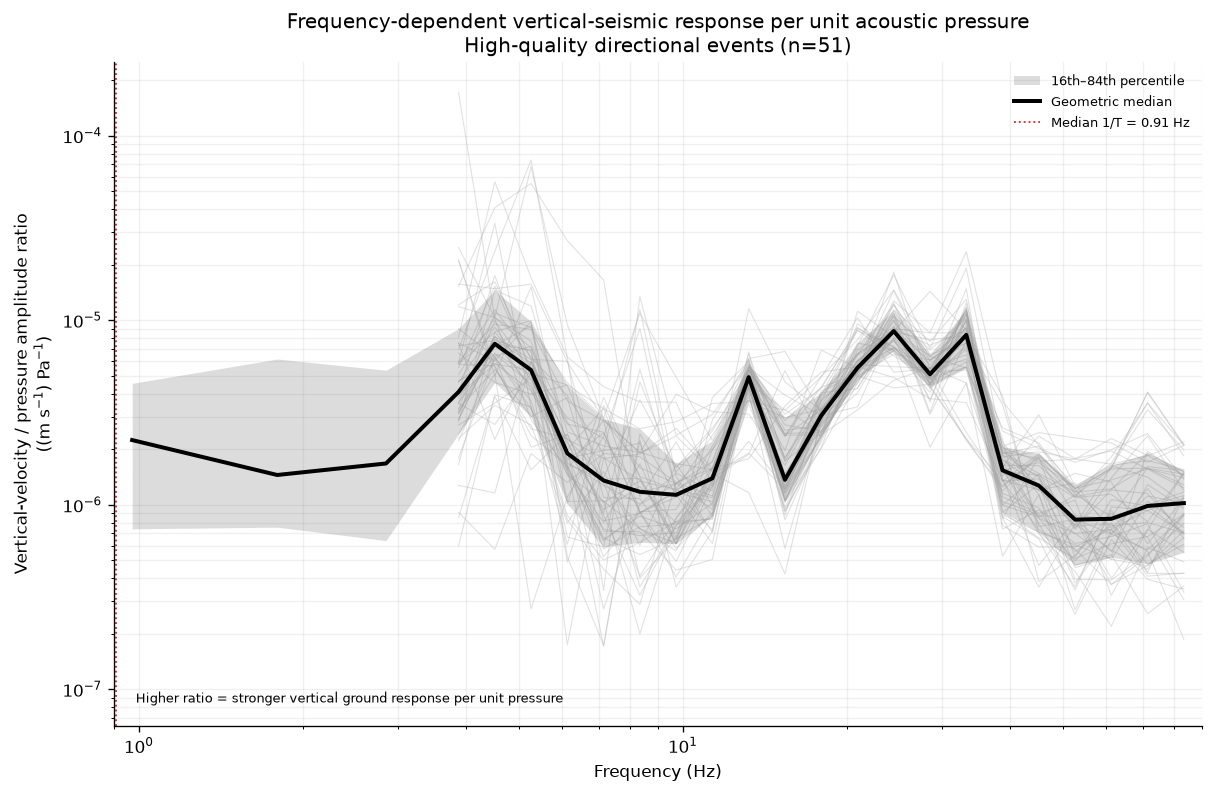

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
event_number,51.0,NaN,NaN,NaN,50.784314,1.0,20.5,39.0,73.5,151.0,38.370465
event_time,51,NaN,NaN,NaN,2016-09-01 13:13:45.595658496+00:00,2016-09-01 13:07:15.927133560+00:00,2016-09-01 13:07:26.488513536+00:00,2016-09-01 13:08:22.663133696+00:00,2016-09-01 13:19:25.937566720+00:00,2016-09-01 13:33:31.789000034+00:00,NaN
solution_quality_class,51,1,A_high_quality,51,NaN,NaN,NaN,NaN,NaN,NaN,NaN
maximum_coherence_score,51.0,NaN,NaN,NaN,0.961064,0.907537,0.943059,0.963112,0.981921,0.998398,0.02672
samples,51.0,NaN,NaN,NaN,274.980392,274.0,275.0,275.0,275.0,275.0,0.140028
sampling_rate_hz,51.0,NaN,NaN,NaN,250.0,250.0,250.0,250.0,250.0,250.0,0.0
duration_s,51.0,NaN,NaN,NaN,1.099922,1.096,1.1,1.1,1.1,1.1,0.00056
independent_minimum_frequency_hz,51.0,NaN,NaN,NaN,0.909156,0.909091,0.909091,0.909091,0.909091,0.912409,0.000465
nyquist_frequency_hz,51.0,NaN,NaN,NaN,125.0,125.0,125.0,125.0,125.0,125.0,0.0


,frequency_hz,event_count,geometric_median_mps_per_pa,percentile_16_mps_per_pa,percentile_84_mps_per_pa
0,0.971798,51,0.000002,7.397378e-07,0.000005
4,1.795736,51,0.000001,7.551440e-07,0.000006
7,2.846050,51,0.000002,6.388384e-07,0.000005
9,3.868796,51,0.000004,2.417966e-06,0.000009
10,4.510685,51,0.000007,4.591832e-06,0.000015


Event spectral ratios: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/100_measure_event_amplitudes_and_acoustic_seismic_coupling/high_quality_vertical_velocity_to_pressure_spectral_ratios.csv
Spectral-ratio summary: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/100_measure_event_amplitudes_and_acoustic_seismic_coupling/high_quality_vertical_velocity_to_pressure_spectral_ratio_summary.csv
Figure: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/100_measure_event_amplitudes_and_acoustic_seismic_coupling/figures/high_quality_vertical_velocity_to_pressure_spectral_ratio.pdf


In [85]:
# Select only Notebook 080 A-quality events.
high_quality_events = measurements.loc[
    measurements["solution_quality_class"]
    == SPECTRAL_QUALITY_CLASS,
    [
        "event_number",
        "event_time",
        "maximum_coherence_score",
    ],
].copy()


spectral_ratio_rows = []
spectral_event_rows = []


for event in high_quality_events.itertuples(
    index=False
):

    event_number = int(
        event.event_number
    )

    diagnostic = diagnostic_data.get(
        event_number
    )

    if diagnostic is None:
        continue

    times_s = np.asarray(
        diagnostic["times_s"],
        dtype=float,
    )

    pressure_pa = np.asarray(
        diagnostic["median_pressure_stack"],
        dtype=float,
    )

    vertical_velocity_mps = np.asarray(
        diagnostic["corrected"]["DHZ"],
        dtype=float,
    )

    # Use the longest interval for which all three arrays are finite.
    finite = (
        np.isfinite(times_s)
        & np.isfinite(pressure_pa)
        & np.isfinite(vertical_velocity_mps)
    )

    usable = longest_contiguous_true_run(
        finite
    )

    times = times_s[usable]
    pressure = pressure_pa[usable]
    vertical_velocity = vertical_velocity_mps[usable]

    if len(times) < 8:
        continue

    dt_s = float(
        np.nanmedian(
            np.diff(times)
        )
    )

    if (
        not np.isfinite(dt_s)
        or dt_s <= 0
    ):
        continue

    sampling_rate_hz = 1.0 / dt_s

    duration_s = float(
        times[-1]
        - times[0]
        + dt_s
    )

    independent_minimum_hz = (
        1.0 / duration_s
    )

    nyquist_hz = (
        0.5 * sampling_rate_hz
    )

    # Pressure amplitude spectrum.
    (
        frequency_hz,
        pressure_power_spectrum,
    ) = periodogram(
        pressure,
        fs=sampling_rate_hz,
        window=(
            "tukey",
            SPECTRAL_TUKEY_ALPHA,
        ),
        detrend="linear",
        scaling="spectrum",
    )

    # Vertical ground-velocity amplitude spectrum.
    (
        vertical_frequency_hz,
        vertical_velocity_power_spectrum,
    ) = periodogram(
        vertical_velocity,
        fs=sampling_rate_hz,
        window=(
            "tukey",
            SPECTRAL_TUKEY_ALPHA,
        ),
        detrend="linear",
        scaling="spectrum",
    )

    if not np.allclose(
        frequency_hz,
        vertical_frequency_hz,
    ):
        raise ValueError(
            "Spectral frequency mismatch "
            f"for event {event_number}"
        )

    # Convert power spectra to amplitude spectra, then divide vertical
    # ground-velocity amplitude by acoustic-pressure amplitude.
    #
    # Units:
    #     (m s^-1) / Pa
    with np.errstate(
        divide="ignore",
        invalid="ignore",
    ):
        vertical_velocity_pressure_ratio = np.sqrt(
            vertical_velocity_power_spectrum
            / pressure_power_spectrum
        )

    # Do not report frequencies below the independent 1/T resolution,
    # above Nyquist, or outside the requested plotting interval.
    physically_supported = (
        (
            frequency_hz
            >= max(
                SPECTRAL_MIN_HZ,
                independent_minimum_hz,
            )
        )
        & (
            frequency_hz
            <= min(
                SPECTRAL_MAX_HZ,
                nyquist_hz,
            )
        )
        & np.isfinite(
            vertical_velocity_pressure_ratio
        )
        & (
            vertical_velocity_pressure_ratio
            > 0
        )
    )

    binned_ratio = log_bin_geometric_median(
        frequency_hz[
            physically_supported
        ],
        vertical_velocity_pressure_ratio[
            physically_supported
        ],
        spectral_bin_edges_hz,
    )

    spectral_event_rows.append({
        "event_number":
            event_number,

        "event_time":
            event.event_time,

        "solution_quality_class":
            SPECTRAL_QUALITY_CLASS,

        "maximum_coherence_score":
            float(
                event.maximum_coherence_score
            ),

        "samples":
            int(len(times)),

        "sampling_rate_hz":
            sampling_rate_hz,

        "duration_s":
            duration_s,

        "independent_minimum_frequency_hz":
            independent_minimum_hz,

        "nyquist_frequency_hz":
            nyquist_hz,
    })

    for frequency, ratio in zip(
        spectral_frequency_hz,
        binned_ratio,
    ):
        spectral_ratio_rows.append({
            "event_number":
                event_number,

            "frequency_hz":
                float(frequency),

            "vertical_velocity_to_pressure_ratio_mps_per_pa":
                float(ratio),
        })


spectral_event_metadata = pd.DataFrame(
    spectral_event_rows
)

spectral_ratios_long = pd.DataFrame(
    spectral_ratio_rows
)


if (
    spectral_event_metadata.empty
    or spectral_ratios_long.empty
):
    raise ValueError(
        "No A-quality events produced "
        "usable spectral ratios"
    )


# Construct event × frequency matrix.
spectral_ratio_matrix = (
    spectral_ratios_long
    .pivot(
        index="event_number",
        columns="frequency_hz",
        values=(
            "vertical_velocity_to_pressure_ratio_mps_per_pa"
        ),
    )
    .reindex(
        columns=spectral_frequency_hz
    )
)


# Calculate frequency-by-frequency geometric median and percentiles.
spectral_summary_rows = []

for frequency in spectral_frequency_hz:

    values = spectral_ratio_matrix[
        frequency
    ].to_numpy(float)

    values = values[
        np.isfinite(values)
        & (values > 0)
    ]

    row = {
        "frequency_hz":
            float(frequency),

        "event_count":
            int(len(values)),

        "geometric_median_mps_per_pa":
            np.nan,

        "percentile_16_mps_per_pa":
            np.nan,

        "percentile_84_mps_per_pa":
            np.nan,
    }

    if (
        len(values)
        >= SPECTRAL_MIN_EVENTS_PER_BIN
    ):
        log_values = np.log10(
            values
        )

        row.update({
            "geometric_median_mps_per_pa":
                float(
                    10.0
                    ** np.nanmedian(
                        log_values
                    )
                ),

            "percentile_16_mps_per_pa":
                float(
                    10.0
                    ** np.nanpercentile(
                        log_values,
                        16,
                    )
                ),

            "percentile_84_mps_per_pa":
                float(
                    10.0
                    ** np.nanpercentile(
                        log_values,
                        84,
                    )
                ),
        })

    spectral_summary_rows.append(
        row
    )


spectral_ratio_summary = pd.DataFrame(
    spectral_summary_rows
)


# Export event-level ratios, event metadata and aggregate spectrum.
event_ratio_file = (
    OUTPUT_ROOT
    / "high_quality_vertical_velocity_to_pressure_spectral_ratios.csv"
)

metadata_file = (
    OUTPUT_ROOT
    / "high_quality_vertical_velocity_to_pressure_spectral_metadata.csv"
)

summary_file = (
    OUTPUT_ROOT
    / "high_quality_vertical_velocity_to_pressure_spectral_ratio_summary.csv"
)

spectral_ratios_long.to_csv(
    event_ratio_file,
    index=False,
)

spectral_event_metadata.to_csv(
    metadata_file,
    index=False,
)

spectral_ratio_summary.to_csv(
    summary_file,
    index=False,
)


# -------------------------------------------------------------------------
# Plot
# -------------------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(10, 6.5),
    constrained_layout=True,
)


# Individual A-quality events.
for (
    event_number,
    values,
) in spectral_ratio_matrix.iterrows():

    ax.plot(
        spectral_frequency_hz,
        values.to_numpy(float),
        color="0.72",
        alpha=0.42,
        lw=0.65,
        zorder=1,
    )


supported_summary = (
    spectral_ratio_summary[
        "geometric_median_mps_per_pa"
    ].notna()
)

summary_frequency = (
    spectral_ratio_summary.loc[
        supported_summary,
        "frequency_hz",
    ].to_numpy(float)
)

summary_median = (
    spectral_ratio_summary.loc[
        supported_summary,
        "geometric_median_mps_per_pa",
    ].to_numpy(float)
)

summary_low = (
    spectral_ratio_summary.loc[
        supported_summary,
        "percentile_16_mps_per_pa",
    ].to_numpy(float)
)

summary_high = (
    spectral_ratio_summary.loc[
        supported_summary,
        "percentile_84_mps_per_pa",
    ].to_numpy(float)
)


# Event-to-event range.
ax.fill_between(
    summary_frequency,
    summary_low,
    summary_high,
    color="0.25",
    alpha=0.18,
    linewidth=0,
    label="16th–84th percentile",
    zorder=2,
)


# Aggregate geometric median.
ax.plot(
    summary_frequency,
    summary_median,
    color="black",
    lw=2.4,
    label="Geometric median",
    zorder=3,
)


# Median independent frequency resolution.
median_resolution_hz = float(
    spectral_event_metadata[
        "independent_minimum_frequency_hz"
    ].median()
)

ax.axvline(
    median_resolution_hz,
    color="tab:red",
    ls=":",
    lw=1.1,
    label=(
        f"Median 1/T = "
        f"{median_resolution_hz:.2g} Hz"
    ),
)


ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlim(
    SPECTRAL_MIN_HZ,
    SPECTRAL_MAX_HZ,
)

# Let Matplotlib determine the y limits initially. If fixed limits are
# needed after inspecting the figure, approximately 1e-7 to 1e-4
# (m s^-1) Pa^-1 corresponds to the reciprocal of the old plot.
#
# ax.set_ylim(1e-7, 1e-4)

ax.set_xlabel(
    "Frequency (Hz)"
)

ax.set_ylabel(
    "Vertical-velocity / pressure amplitude ratio\n"
    "((m s$^{-1}$) Pa$^{-1}$)"
)

ax.set_title(
    "Frequency-dependent vertical-seismic response "
    "per unit acoustic pressure\n"
    f"High-quality directional events "
    f"(n={len(spectral_event_metadata)})"
)

ax.text(
    0.02,
    0.03,
    (
        "Higher ratio = stronger vertical "
        "ground response per unit pressure"
    ),
    transform=ax.transAxes,
    fontsize=8,
    va="bottom",
    ha="left",
)

ax.grid(
    True,
    which="both",
    alpha=0.18,
)

ax.legend(
    frameon=False,
    fontsize=8,
)


figure_png = (
    FIGURE_DIR
    / "high_quality_vertical_velocity_to_pressure_spectral_ratio.pdf"
)

figure_pdf = (
    FIGURE_DIR
    / "high_quality_vertical_velocity_to_pressure_spectral_ratio.pdf"
)

fig.savefig(
    figure_png,
    bbox_inches="tight",
)

fig.savefig(
    figure_pdf,
    bbox_inches="tight",
)

plt.show()


display(
    spectral_event_metadata
    .describe(
        include="all"
    )
    .T
)

display(
    spectral_ratio_summary.loc[
        supported_summary
    ].head()
)

print(
    "Event spectral ratios:",
    event_ratio_file,
)

print(
    "Spectral-ratio summary:",
    summary_file,
)

print(
    "Figure:",
    figure_png,
)

## Empirical pressure-to-DHZ transfer estimates

The primary event estimate is the conventional H1 transfer estimate using the
geometry-aligned arithmetic-mean pressure beam. Auto- and cross-spectra are
averaged across events before ratios are formed, so energetic acoustic events
receive greater weight. Pressure-RMS equalization, median-beam substitution,
and exclusion of the strongest 1, 3, and 5 events test that dependence.

Uncertainty is estimated by resampling events. A frequency-dependent coherence
null is obtained by randomly pairing pressure spectra with DHZ spectra from
different events. The continuous Phase I estimate uses the response-corrected
stream before moving-median baseline removal and seven independent,
non-overlapping 10-s segments. Segment resampling supplies uncertainty and
random pressure–DHZ segment pairing supplies its empirical coherence null.

In [86]:
from matplotlib.lines import Line2D
from matplotlib.collections import LineCollection
from scipy.signal import detrend, get_window


def single_segment_spectra(pressure, velocity, sampling_rate_hz):
    """One-sided auto/cross spectra for one equal-length record pair."""
    pressure = detrend(np.asarray(pressure, dtype=float), type="linear")
    velocity = detrend(np.asarray(velocity, dtype=float), type="linear")
    if len(pressure) != len(velocity):
        raise ValueError("Pressure and velocity segment lengths differ")
    window = get_window(("tukey", SPECTRAL_TUKEY_ALPHA), len(pressure), fftbins=True)
    pressure_fft = np.fft.rfft(pressure * window)
    velocity_fft = np.fft.rfft(velocity * window)
    frequency_hz = np.fft.rfftfreq(len(pressure), d=1.0 / sampling_rate_hz)
    scale = 1.0 / (sampling_rate_hz * np.sum(window ** 2))
    onesided = np.ones_like(frequency_hz)
    if len(pressure) % 2 == 0:
        onesided[1:-1] = 2.0
    else:
        onesided[1:] = 2.0
    spp = scale * onesided * np.abs(pressure_fft) ** 2
    svv = scale * onesided * np.abs(velocity_fft) ** 2
    spv = scale * onesided * np.conj(pressure_fft) * velocity_fft
    return frequency_hz, spp.real, svv.real, spv


def bin_transfer_spectra(frequency_hz, spp, svv, spv, bin_edges_hz):
    rows = []
    for low_hz, high_hz in zip(bin_edges_hz[:-1], bin_edges_hz[1:]):
        include = (
            (frequency_hz >= low_hz) & (frequency_hz < high_hz)
            & np.isfinite(spp) & np.isfinite(svv) & np.isfinite(spv)
        )
        if not np.any(include):
            continue
        binned_spp = float(np.mean(np.real(spp[include])))
        binned_svv = float(np.mean(np.real(svv[include])))
        binned_spv = complex(np.mean(spv[include]))
        if binned_spp <= 0 or binned_svv <= 0:
            continue
        h1 = binned_spv / binned_spp
        h2 = binned_svv / np.conj(binned_spv) if binned_spv != 0 else np.nan + 1j * np.nan
        coherence = np.clip(
            np.abs(binned_spv) ** 2 / (binned_spp * binned_svv), 0.0, 1.0
        )
        rows.append({
            "frequency_hz": float(np.sqrt(low_hz * high_hz)),
            "bin_low_hz": float(low_hz), "bin_high_hz": float(high_hz),
            "fourier_bin_count": int(np.count_nonzero(include)),
            "pressure_autospectrum_pa2_per_hz": binned_spp,
            "velocity_autospectrum_m2s2_per_hz": binned_svv,
            "crossspectrum_real": float(binned_spv.real),
            "crossspectrum_imag": float(binned_spv.imag),
            "amplitude_ratio_mps_per_pa": float(np.sqrt(binned_svv / binned_spp)),
            "h1_real_mps_per_pa": float(h1.real),
            "h1_imag_mps_per_pa": float(h1.imag),
            "h1_magnitude_mps_per_pa": float(np.abs(h1)),
            "h1_phase_deg": float(np.degrees(np.angle(h1))),
            "h2_magnitude_mps_per_pa": float(np.abs(h2)),
            "magnitude_squared_coherence": float(coherence),
        })
    return pd.DataFrame(rows)


def aggregate_spectral_terms(frequency_hz, spp_rows, svv_rows, spv_rows, edges, indices=None):
    if indices is None:
        indices = np.arange(len(spp_rows))
    return bin_transfer_spectra(
        frequency_hz,
        np.mean(spp_rows[indices], axis=0),
        np.mean(svv_rows[indices], axis=0),
        np.mean(spv_rows[indices], axis=0),
        edges,
    )


def add_resampling_intervals(primary, bootstrap_tables, permutation_tables):
    h1 = np.vstack([table["h1_magnitude_mps_per_pa"].to_numpy(float) for table in bootstrap_tables])
    coherence = np.vstack([table["magnitude_squared_coherence"].to_numpy(float) for table in bootstrap_tables])
    null_coherence = np.vstack([table["magnitude_squared_coherence"].to_numpy(float) for table in permutation_tables])
    primary = primary.copy()
    primary["h1_bootstrap_2p5"] = np.nanpercentile(h1, 2.5, axis=0)
    primary["h1_bootstrap_50"] = np.nanpercentile(h1, 50, axis=0)
    primary["h1_bootstrap_97p5"] = np.nanpercentile(h1, 97.5, axis=0)
    primary["coherence_bootstrap_2p5"] = np.nanpercentile(coherence, 2.5, axis=0)
    primary["coherence_bootstrap_97p5"] = np.nanpercentile(coherence, 97.5, axis=0)
    primary["coherence_permutation_95"] = np.nanpercentile(null_coherence, 95, axis=0)
    primary["coherence_permutation_99"] = np.nanpercentile(null_coherence, 99, axis=0)
    primary["coherence_significant_95"] = (
        primary["magnitude_squared_coherence"] >= primary["coherence_permutation_95"]
    )
    primary["coherence_significant_99"] = (
        primary["magnitude_squared_coherence"] >= primary["coherence_permutation_99"]
    )
    return primary


def plot_significance_weighted_line(ax, x, y, coherence, null95, linestyle="-", linewidth=2.2):
    """Draw low-coherence segments nearly white and high-coherence segments black."""
    x = np.asarray(x, float); y = np.asarray(y, float)
    coherence = np.asarray(coherence, float); null95 = np.asarray(null95, float)
    valid = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    x, y, coherence, null95 = x[valid], y[valid], coherence[valid], null95[valid]
    points = np.column_stack([x, y])
    segments = np.stack([points[:-1], points[1:]], axis=1)
    midpoint_coherence = 0.5 * (coherence[:-1] + coherence[1:])
    midpoint_null = 0.5 * (null95[:-1] + null95[1:])
    quality = np.clip((midpoint_coherence - midpoint_null) / np.maximum(1.0 - midpoint_null, 1e-6), 0, 1)
    colors = plt.cm.Greys(0.12 + 0.86 * quality)
    collection = LineCollection(segments, colors=colors, linewidths=linewidth, linestyles=linestyle)
    ax.add_collection(collection)
    return collection


In [87]:
event_transfer_records = []
event_transfer_selection = measurements.loc[
    measurements["solution_quality_class"] == SPECTRAL_QUALITY_CLASS,
    ["event_number", "event_time", "maximum_coherence_score"],
].copy()

for event in event_transfer_selection.itertuples(index=False):
    diagnostic = diagnostic_data.get(int(event.event_number))
    if diagnostic is None:
        continue
    times = np.asarray(diagnostic["times_s"], dtype=float)
    linear_pressure = np.asarray(diagnostic["mean_pressure_beam"], dtype=float)
    median_pressure = np.asarray(diagnostic["median_pressure_stack"], dtype=float)
    velocity = np.asarray(diagnostic["corrected"]["DHZ"], dtype=float)
    finite = np.isfinite(times) & np.isfinite(linear_pressure) & np.isfinite(median_pressure) & np.isfinite(velocity)
    usable = longest_contiguous_true_run(finite)
    times = times[usable]
    if len(times) < 8:
        continue
    dt_s = float(np.median(np.diff(times)))
    event_transfer_records.append({
        "event_number": int(event.event_number),
        "sampling_rate_hz": 1.0 / dt_s,
        "linear_pressure_pa": linear_pressure[usable],
        "median_pressure_pa": median_pressure[usable],
        "vertical_velocity_mps": velocity[usable],
        "linear_pressure_rms_pa": float(np.sqrt(np.mean(linear_pressure[usable] ** 2))),
    })

if not event_transfer_records:
    raise ValueError("No A-quality records are available for transfer analysis")

event_sampling_rate_hz = float(np.median([r["sampling_rate_hz"] for r in event_transfer_records]))
event_nperseg = min(len(r["linear_pressure_pa"]) for r in event_transfer_records)
event_edges_hz = logarithmic_edges(SPECTRAL_MIN_HZ, SPECTRAL_MAX_HZ, SPECTRAL_BINS_PER_DECADE)


def build_event_terms(pressure_key, pressure_rms_equalized=False):
    spp_rows, svv_rows, spv_rows = [], [], []
    frequency_reference = None
    for record in event_transfer_records:
        pressure = np.asarray(record[pressure_key][:event_nperseg], float)
        velocity = np.asarray(record["vertical_velocity_mps"][:event_nperseg], float)
        if pressure_rms_equalized:
            scale = float(np.sqrt(np.mean(pressure ** 2)))
            pressure, velocity = pressure / scale, velocity / scale
        frequency, spp, svv, spv = single_segment_spectra(pressure, velocity, event_sampling_rate_hz)
        if frequency_reference is None:
            frequency_reference = frequency
        elif not np.allclose(frequency_reference, frequency):
            raise ValueError("Event spectral frequency grids differ")
        spp_rows.append(spp); svv_rows.append(svv); spv_rows.append(spv)
    return frequency_reference, np.asarray(spp_rows), np.asarray(svv_rows), np.asarray(spv_rows)


event_frequency_hz, event_spp, event_svv, event_spv = build_event_terms("linear_pressure_pa", False)
_, event_equal_spp, event_equal_svv, event_equal_spv = build_event_terms("linear_pressure_pa", True)
_, event_median_spp, event_median_svv, event_median_spv = build_event_terms("median_pressure_pa", False)

event_primary = aggregate_spectral_terms(event_frequency_hz, event_spp, event_svv, event_spv, event_edges_hz)

rng_transfer = np.random.default_rng(20260812)
event_bootstrap_tables = []
for _ in range(TRANSFER_BOOTSTRAP_REPLICATES):
    sample = rng_transfer.integers(0, len(event_transfer_records), len(event_transfer_records))
    event_bootstrap_tables.append(
        aggregate_spectral_terms(event_frequency_hz, event_spp, event_svv, event_spv, event_edges_hz, sample)
    )

# Pair each event's pressure with a randomly selected different event's DHZ.
event_permutation_tables = []
for _ in range(TRANSFER_PERMUTATION_REPLICATES):
    permutation = rng_transfer.permutation(len(event_transfer_records))
    while np.any(permutation == np.arange(len(permutation))):
        permutation = rng_transfer.permutation(len(event_transfer_records))
    permuted_spv = []
    for pressure_index, velocity_index in enumerate(permutation):
        pressure = event_transfer_records[pressure_index]["linear_pressure_pa"][:event_nperseg]
        velocity = event_transfer_records[velocity_index]["vertical_velocity_mps"][:event_nperseg]
        _, _, _, spv = single_segment_spectra(pressure, velocity, event_sampling_rate_hz)
        permuted_spv.append(spv)
    event_permutation_tables.append(bin_transfer_spectra(
        event_frequency_hz, np.mean(event_spp, axis=0), np.mean(event_svv, axis=0),
        np.mean(permuted_spv, axis=0), event_edges_hz,
    ))

event_ensemble_transfer = add_resampling_intervals(
    event_primary, event_bootstrap_tables, event_permutation_tables
)
event_ensemble_transfer.insert(0, "dataset", "A-quality event ensemble")
event_ensemble_transfer["record_count"] = len(event_transfer_records)
event_ensemble_transfer["record_duration_s"] = event_nperseg / event_sampling_rate_hz
event_ensemble_transfer["pressure_beam"] = "aligned arithmetic mean"
event_ensemble_transfer["event_weighting"] = "conventional acoustic-input-energy weighting"

# Beam and event-weighting tests.
event_equal_weighted = aggregate_spectral_terms(
    event_frequency_hz, event_equal_spp, event_equal_svv, event_equal_spv, event_edges_hz
)
event_equal_weighted.insert(0, "dataset", "Pressure-RMS equalized")
event_median_weighted = aggregate_spectral_terms(
    event_frequency_hz, event_median_spp, event_median_svv, event_median_spv, event_edges_hz
)
event_median_weighted.insert(0, "dataset", "Median pressure stack")

# Exclude the acoustically strongest 1, 3, and 5 A-quality events.
strength_order = np.argsort([
    record["linear_pressure_rms_pa"] for record in event_transfer_records
])[::-1]
dominant_event_rows = []
dominant_event_transfer_tables = []
for excluded_count in (0, 1, 3, 5):
    keep = np.setdiff1d(np.arange(len(event_transfer_records)), strength_order[:excluded_count])
    table = aggregate_spectral_terms(
        event_frequency_hz, event_spp, event_svv, event_spv, event_edges_hz, keep
    )
    table.insert(0, "excluded_strongest_event_count", excluded_count)
    dominant_event_transfer_tables.append(table)
    dominant_event_rows.append({
        "excluded_strongest_event_count": excluded_count,
        "retained_event_count": len(keep),
        "excluded_event_numbers": ",".join(str(event_transfer_records[i]["event_number"]) for i in strength_order[:excluded_count]),
        "excluded_pressure_rms_pa": ",".join(f'{event_transfer_records[i]["linear_pressure_rms_pa"]:.8g}' for i in strength_order[:excluded_count]),
    })

dominant_event_transfer = pd.concat(dominant_event_transfer_tables, ignore_index=True)
dominant_event_metadata = pd.DataFrame(dominant_event_rows)
event_transfer_sensitivity = pd.concat([
    event_ensemble_transfer.assign(sensitivity_case="Primary linear beam"),
    event_equal_weighted.assign(sensitivity_case="Pressure-RMS equalized"),
    event_median_weighted.assign(sensitivity_case="Median pressure stack"),
], ignore_index=True, sort=False)

event_ensemble_transfer.to_csv(OUTPUT_ROOT / "event_ensemble_pressure_to_dhz_transfer_function.csv", index=False)
event_transfer_sensitivity.to_csv(OUTPUT_ROOT / "event_transfer_weighting_and_beam_sensitivity.csv", index=False)
dominant_event_transfer.to_csv(OUTPUT_ROOT / "event_transfer_dominant_event_exclusion.csv", index=False)
dominant_event_metadata.to_csv(OUTPUT_ROOT / "event_transfer_dominant_event_exclusion_metadata.csv", index=False)

print("A-quality event transfer analysis")
print("  records:", len(event_transfer_records))
print(f"  record duration: {event_nperseg / event_sampling_rate_hz:.3f} s")
print(f"  bootstrap replicates: {TRANSFER_BOOTSTRAP_REPLICATES}")
print(f"  permutation replicates: {TRANSFER_PERMUTATION_REPLICATES}")
display(dominant_event_metadata)
display(event_ensemble_transfer.head())


A-quality event transfer analysis
  records: 51
  record duration: 1.096 s
  bootstrap replicates: 1000
  permutation replicates: 1000


,excluded_strongest_event_count,retained_event_count,excluded_event_numbers,excluded_pressure_rms_pa
0,0,51,,
1,1,50,14,251.75235
2,3,48,"14,13,15","251.75235,251.66139,251.54343"
3,5,46,"14,13,15,12,11","251.75235,251.66139,251.54343,249.04731,244.19943"


,dataset,frequency_hz,bin_low_hz,bin_high_hz,fourier_bin_count,pressure_autospectrum_pa2_per_hz,velocity_autospectrum_m2s2_per_hz,crossspectrum_real,crossspectrum_imag,amplitude_ratio_mps_per_pa,...,coherence_bootstrap_2p5,coherence_bootstrap_97p5,coherence_permutation_95,coherence_permutation_99,coherence_significant_95,coherence_significant_99,record_count,record_duration_s,pressure_beam,event_weighting
0,A-quality event ensemble,0.971798,0.900000,1.049323,1,1409.964436,4.369416e-10,-0.000256,-0.000308,5.566825e-07,...,0.147794,0.792565,0.078911,0.122205,True,True,51,1.096,aligned arithmetic mean,conventional acoustic-input-energy weighting
1,A-quality event ensemble,1.795736,1.663065,1.938991,1,1559.875059,5.038975e-10,-0.000047,-0.000480,5.683635e-07,...,0.091623,0.658237,0.071369,0.120017,True,True,51,1.096,aligned arithmetic mean,conventional acoustic-input-energy weighting
2,A-quality event ensemble,2.846050,2.635780,3.073094,1,475.222641,2.347403e-09,-0.000695,-0.000400,2.222518e-06,...,0.305111,0.888538,0.065934,0.107698,True,True,51,1.096,aligned arithmetic mean,conventional acoustic-input-energy weighting
3,A-quality event ensemble,3.868796,3.582965,4.177430,1,335.977585,5.119500e-09,-0.000879,-0.000674,3.903540e-06,...,0.343696,0.911381,0.068783,0.109858,True,True,51,1.096,aligned arithmetic mean,conventional acoustic-input-energy weighting
4,A-quality event ensemble,4.510685,4.177430,4.870526,1,412.463566,1.688968e-08,-0.001685,0.001185,6.399086e-06,...,0.213957,0.922855,0.054232,0.099325,True,True,51,1.096,aligned arithmetic mean,conventional acoustic-input-energy weighting


In [88]:
from obspy import UTCDateTime, read

PHASE1_SOURCE_DURATION_S = 70.0
PHASE1_SEGMENT_S = 10.0


def load_prebaseline_continuous_stream():
    """Load response-corrected data before moving-median baseline removal."""
    candidate_paths = []

    # Notebook 010 records the authoritative response-corrected Stream directly
    # under ``stream_file``. Notebook 060 uses this same key when validating the
    # later moving-median product.
    configured_stream_file = analysis_config.get("stream_file")
    if configured_stream_file:
        candidate_paths.append(Path(configured_stream_file).expanduser())

    # Retain compatibility with configurations that group product paths.
    for product_group_name in ("response_corrected_streams", "corrected_streams"):
        group = analysis_config.get(product_group_name, {})
        if isinstance(group, dict) and group.get("pickle"):
            candidate_paths.append(Path(group["pickle"]).expanduser())

    candidate_paths.append(config.NB010_DIR / "bchh_corrected.pkl")
    required_channels = set(INFRASOUND_CHANNELS) | {"DHZ"}
    checked = []
    for path in candidate_paths:
        if path in checked:
            continue
        checked.append(path)
        if "baseline_removed" in path.name.lower() or not path.exists():
            continue
        stream = read(str(path), format="PICKLE")
        if required_channels.issubset({trace.stats.channel for trace in stream}):
            return path, stream
    raise FileNotFoundError(
        "No pre-baseline-removal response-corrected continuous stream was found. Checked: "
        + ", ".join(str(path) for path in checked)
    )


def one_trace_for_channel(stream, channel):
    matches = stream.select(channel=channel)
    if len(matches) != 1:
        raise ValueError(f"Expected one {channel} trace; found {len(matches)}")
    return matches[0]


continuous_stream_file, continuous_stream = load_prebaseline_continuous_stream()
continuous_pressure_traces = {
    channel: one_trace_for_channel(continuous_stream, channel)
    for channel in INFRASOUND_CHANNELS
}
continuous_dhz = one_trace_for_channel(continuous_stream, "DHZ")

reference_distance_m = float(INFRASOUND_DISTANCES_M[ACOUSTIC_REFERENCE_CHANNEL])
reference_travel_time_s = reference_distance_m / ACOUSTIC_ALIGNMENT_SPEED_MPS
phase1_source_start = config.source_event_time("upper_stage")
phase1_source_end = phase1_source_start + PHASE1_SOURCE_DURATION_S
phase1_arrival_start = phase1_source_start + reference_travel_time_s
phase1_arrival_end = phase1_source_end + reference_travel_time_s

phase1_sampling_rate_hz = float(min(
    trace.stats.sampling_rate
    for trace in list(continuous_pressure_traces.values()) + [continuous_dhz]
))
phase1_dt_s = 1.0 / phase1_sampling_rate_hz
phase1_target_times_s = np.arange(0.0, float(phase1_arrival_end - phase1_arrival_start), phase1_dt_s)

phase1_aligned_pressure = []
for channel, trace in continuous_pressure_traces.items():
    differential_delay_s = (
        INFRASOUND_DISTANCES_M[channel] - reference_distance_m
    ) / ACOUSTIC_ALIGNMENT_SPEED_MPS
    phase1_aligned_pressure.append(interpolate_trace(
        trace, float(phase1_arrival_start.timestamp),
        phase1_target_times_s + differential_delay_s,
    ))
phase1_pressure_pa = np.nanmean(np.vstack(phase1_aligned_pressure), axis=0)
phase1_velocity_mps = interpolate_trace(
    continuous_dhz, float(phase1_arrival_start.timestamp), phase1_target_times_s
)
finite = np.isfinite(phase1_pressure_pa) & np.isfinite(phase1_velocity_mps)
usable = longest_contiguous_true_run(finite)
phase1_pressure_pa = phase1_pressure_pa[usable]
phase1_velocity_mps = phase1_velocity_mps[usable]

segment_samples = int(round(PHASE1_SEGMENT_S * phase1_sampling_rate_hz))
segment_count = min(len(phase1_pressure_pa), len(phase1_velocity_mps)) // segment_samples
if segment_count < 3:
    raise ValueError("Too few independent Phase I segments")

phase1_spp_rows, phase1_svv_rows, phase1_spv_rows = [], [], []
phase1_frequency_hz = None
for segment_index in range(segment_count):
    segment = slice(segment_index * segment_samples, (segment_index + 1) * segment_samples)
    frequency, spp, svv, spv = single_segment_spectra(
        phase1_pressure_pa[segment], phase1_velocity_mps[segment], phase1_sampling_rate_hz
    )
    if phase1_frequency_hz is None:
        phase1_frequency_hz = frequency
    phase1_spp_rows.append(spp); phase1_svv_rows.append(svv); phase1_spv_rows.append(spv)
phase1_spp_rows = np.asarray(phase1_spp_rows)
phase1_svv_rows = np.asarray(phase1_svv_rows)
phase1_spv_rows = np.asarray(phase1_spv_rows)
phase1_edges_hz = logarithmic_edges(
    TRANSFER_PHASE1_MIN_HZ, SPECTRAL_MAX_HZ, SPECTRAL_BINS_PER_DECADE
)
phase1_primary = aggregate_spectral_terms(
    phase1_frequency_hz, phase1_spp_rows, phase1_svv_rows, phase1_spv_rows, phase1_edges_hz
)

phase1_bootstrap_tables = []
for _ in range(TRANSFER_BOOTSTRAP_REPLICATES):
    sample = rng_transfer.integers(0, segment_count, segment_count)
    phase1_bootstrap_tables.append(aggregate_spectral_terms(
        phase1_frequency_hz, phase1_spp_rows, phase1_svv_rows, phase1_spv_rows,
        phase1_edges_hz, sample,
    ))

phase1_permutation_tables = []
for _ in range(TRANSFER_PERMUTATION_REPLICATES):
    permutation = rng_transfer.permutation(segment_count)
    while np.any(permutation == np.arange(segment_count)):
        permutation = rng_transfer.permutation(segment_count)
    permuted_spv = []
    for pressure_index, velocity_index in enumerate(permutation):
        p_slice = slice(pressure_index * segment_samples, (pressure_index + 1) * segment_samples)
        v_slice = slice(velocity_index * segment_samples, (velocity_index + 1) * segment_samples)
        _, _, _, spv = single_segment_spectra(
            phase1_pressure_pa[p_slice], phase1_velocity_mps[v_slice], phase1_sampling_rate_hz
        )
        permuted_spv.append(spv)
    phase1_permutation_tables.append(bin_transfer_spectra(
        phase1_frequency_hz, np.mean(phase1_spp_rows, axis=0),
        np.mean(phase1_svv_rows, axis=0), np.mean(permuted_spv, axis=0),
        phase1_edges_hz,
    ))

phase1_continuous_transfer = add_resampling_intervals(
    phase1_primary, phase1_bootstrap_tables, phase1_permutation_tables
)
phase1_continuous_transfer.insert(0, "dataset", "Continuous Phase I")
phase1_continuous_transfer["phase1_source_start_utc"] = phase1_source_start.isoformat()
phase1_continuous_transfer["phase1_source_end_utc"] = phase1_source_end.isoformat()
phase1_continuous_transfer["phase1_arrival_start_utc"] = phase1_arrival_start.isoformat()
phase1_continuous_transfer["phase1_arrival_end_utc"] = phase1_arrival_end.isoformat()
phase1_continuous_transfer["segment_s"] = PHASE1_SEGMENT_S
phase1_continuous_transfer["independent_segment_count"] = segment_count
phase1_continuous_transfer["continuous_stream_file"] = str(continuous_stream_file)
phase1_continuous_transfer["baseline_removal"] = "none; linear detrend within each segment"
phase1_continuous_transfer["pressure_beam"] = "aligned arithmetic mean"
phase1_continuous_transfer.to_csv(
    OUTPUT_ROOT / "phase1_continuous_pressure_to_dhz_transfer_function.csv", index=False
)

print("Continuous Phase I transfer function")
print("  pre-baseline-removal stream:", continuous_stream_file)
print("  source interval:", phase1_source_start, "to", phase1_source_end)
print("  arrival interval:", phase1_arrival_start, "to", phase1_arrival_end)
print(f"  independent segments: {segment_count} × {PHASE1_SEGMENT_S:.1f} s")
print(f"  bootstrap replicates: {TRANSFER_BOOTSTRAP_REPLICATES}")
print(f"  permutation replicates: {TRANSFER_PERMUTATION_REPLICATES}")
display(phase1_continuous_transfer.head())


Continuous Phase I transfer function
  pre-baseline-removal stream: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/010_prepare_analysis_inputs/bchh_corrected_analysis_window.pkl
  source interval: 2016-09-01T13:07:11.913000Z to 2016-09-01T13:08:21.913000Z
  arrival interval: 2016-09-01T13:07:15.913962Z to 2016-09-01T13:08:25.913962Z
  independent segments: 7 × 10.0 s
  bootstrap replicates: 1000
  permutation replicates: 1000


,dataset,frequency_hz,bin_low_hz,bin_high_hz,fourier_bin_count,pressure_autospectrum_pa2_per_hz,velocity_autospectrum_m2s2_per_hz,crossspectrum_real,crossspectrum_imag,amplitude_ratio_mps_per_pa,...,coherence_significant_99,phase1_source_start_utc,phase1_source_end_utc,phase1_arrival_start_utc,phase1_arrival_end_utc,segment_s,independent_segment_count,continuous_stream_file,baseline_removal,pressure_beam
0,Continuous Phase I,0.107851,0.100000,0.116319,1,166.665504,6.173536e-13,3.990855e-06,5.588506e-07,6.086171e-08,...,False,2016-09-01T13:07:11.913000,2016-09-01T13:08:21.913000,2016-09-01T13:07:15.913962,2016-09-01T13:08:25.913962,10.0,7,/Users/thompsong/Developer/KSCRocketSeismology...,none; linear detrend within each segment,aligned arithmetic mean
1,Continuous Phase I,0.197435,0.183062,0.212936,1,501.283640,3.615993e-12,5.802282e-06,-2.669411e-05,8.493213e-08,...,False,2016-09-01T13:07:11.913000,2016-09-01T13:08:21.913000,2016-09-01T13:07:15.913962,2016-09-01T13:08:25.913962,10.0,7,/Users/thompsong/Developer/KSCRocketSeismology...,none; linear detrend within each segment,aligned arithmetic mean
2,Continuous Phase I,0.310723,0.288104,0.335119,1,881.666344,9.982424e-12,1.952679e-05,-6.757772e-05,1.064059e-07,...,True,2016-09-01T13:07:11.913000,2016-09-01T13:08:21.913000,2016-09-01T13:07:15.913962,2016-09-01T13:08:25.913962,10.0,7,/Users/thompsong/Developer/KSCRocketSeismology...,none; linear detrend within each segment,aligned arithmetic mean
3,Continuous Phase I,0.420410,0.389806,0.453418,1,370.066529,1.076385e-11,6.185052e-07,-5.910129e-05,1.705469e-07,...,True,2016-09-01T13:07:11.913000,2016-09-01T13:08:21.913000,2016-09-01T13:07:15.913962,2016-09-01T13:08:25.913962,10.0,7,/Users/thompsong/Developer/KSCRocketSeismology...,none; linear detrend within each segment,aligned arithmetic mean
4,Continuous Phase I,0.489016,0.453418,0.527410,1,706.176877,1.085673e-11,6.847515e-06,-8.435288e-05,1.239918e-07,...,True,2016-09-01T13:07:11.913000,2016-09-01T13:08:21.913000,2016-09-01T13:07:15.913962,2016-09-01T13:08:25.913962,10.0,7,/Users/thompsong/Developer/KSCRocketSeismology...,none; linear detrend within each segment,aligned arithmetic mean


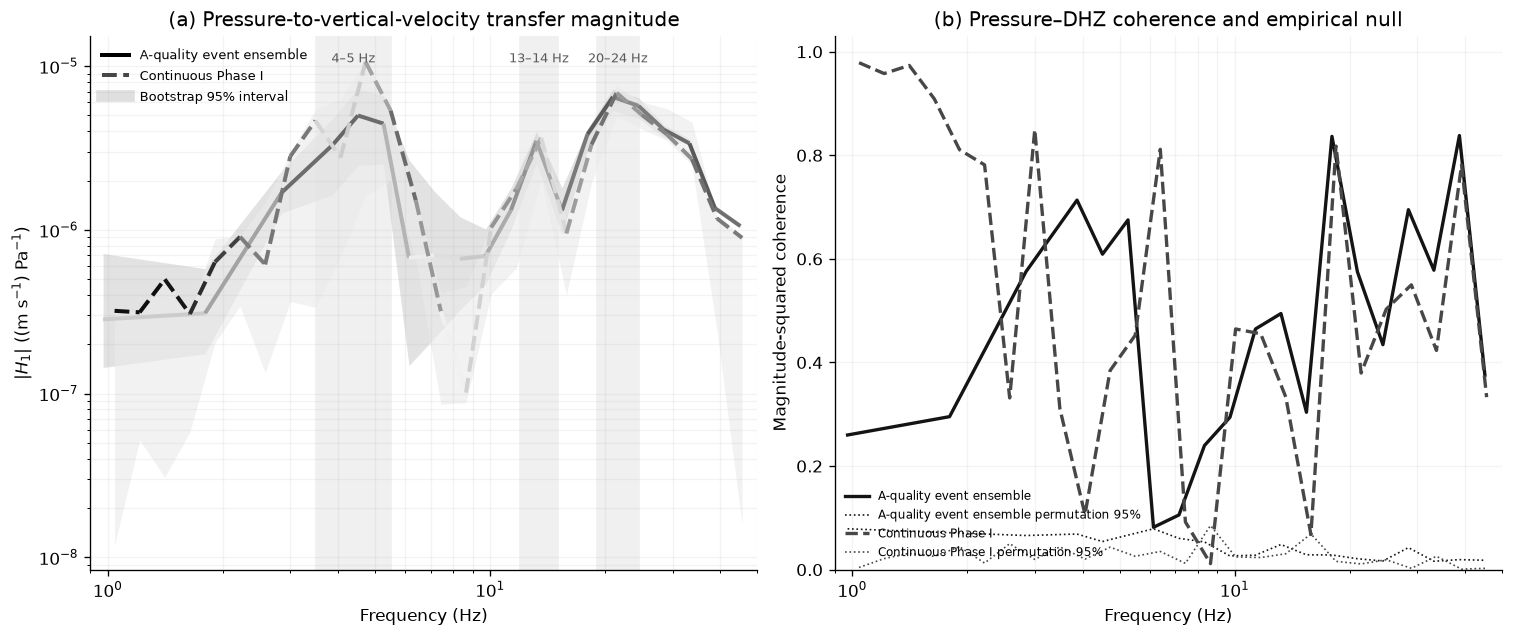

,display_dataset,frequency_hz,h1_magnitude_mps_per_pa,h1_bootstrap_2p5,h1_bootstrap_97p5,magnitude_squared_coherence,coherence_permutation_95
0,A-quality event ensemble,20.936746,0.000006,5.356152e-06,0.000007,0.575030,0.021113
1,A-quality event ensemble,24.410453,0.000006,4.799324e-06,0.000006,0.434412,0.016746
2,A-quality event ensemble,4.510685,0.000005,2.477992e-06,0.000007,0.609114,0.054232
3,A-quality event ensemble,5.259073,0.000004,2.514188e-06,0.000007,0.675241,0.066718
4,A-quality event ensemble,28.460499,0.000004,3.657184e-06,0.000004,0.695022,0.042540
5,Continuous Phase I,4.721400,0.000011,1.610691e-06,0.000011,0.384384,0.043396
6,Continuous Phase I,21.407655,0.000007,4.928747e-06,0.000008,0.379574,0.011037
7,Continuous Phase I,5.491874,0.000005,1.985375e-06,0.000005,0.452527,0.025886
8,Continuous Phase I,24.901122,0.000005,4.131246e-06,0.000006,0.502832,0.019065
9,Continuous Phase I,3.489563,0.000005,3.366089e-07,0.000005,0.310759,0.044083


In [89]:
combined_transfer = pd.concat(
    [event_ensemble_transfer, phase1_continuous_transfer], ignore_index=True, sort=False
)
combined_transfer.to_csv(
    OUTPUT_ROOT / "event_ensemble_and_phase1_transfer_function_comparison.csv", index=False
)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.2), constrained_layout=True)
datasets = [
    (event_ensemble_transfer, "A-quality event ensemble", "-", "0.82", "0.08"),
    (phase1_continuous_transfer, "Continuous Phase I", "--", "0.92", "0.28"),
]

for frame, label, linestyle, fill_gray, line_gray in datasets:
    frame = frame.sort_values("frequency_hz")
    use = frame["frequency_hz"].between(TRANSFER_PLOT_MIN_HZ, TRANSFER_PLOT_MAX_HZ)
    plot = frame.loc[use]
    axes[0].fill_between(
        plot["frequency_hz"], plot["h1_bootstrap_2p5"], plot["h1_bootstrap_97p5"],
        color=fill_gray, alpha=0.62, linewidth=0, zorder=1,
    )
    plot_significance_weighted_line(
        axes[0], plot["frequency_hz"], plot["h1_magnitude_mps_per_pa"],
        plot["magnitude_squared_coherence"], plot["coherence_permutation_95"],
        linestyle=linestyle, linewidth=2.4,
    )
    axes[1].plot(
        plot["frequency_hz"], plot["magnitude_squared_coherence"],
        color=line_gray, ls=linestyle, lw=2.0, label=label,
    )
    axes[1].plot(
        plot["frequency_hz"], plot["coherence_permutation_95"],
        color=line_gray, ls=":", lw=1.0,
        label=f"{label} permutation 95%",
    )

for low, high, label in [(3.5, 5.5, "4–5 Hz"), (12.0, 15.0, "13–14 Hz"), (19.0, 24.5, "20–24 Hz")]:
    axes[0].axvspan(low, high, color="0.94", zorder=0)
    axes[0].text(np.sqrt(low * high), 0.97, label, transform=axes[0].get_xaxis_transform(),
                 ha="center", va="top", fontsize=8, color="0.35")

axes[0].set_xscale("log"); axes[0].set_yscale("log")
axes[0].set_xlim(TRANSFER_PLOT_MIN_HZ, TRANSFER_PLOT_MAX_HZ)
axes[0].set_xlabel("Frequency (Hz)")
axes[0].set_ylabel("$|H_1|$ ((m s$^{-1}$) Pa$^{-1}$)")
axes[0].set_title("(a) Pressure-to-vertical-velocity transfer magnitude")
axes[0].legend(handles=[
    Line2D([0], [0], color="black", lw=2.4, ls="-", label="A-quality event ensemble"),
    Line2D([0], [0], color="0.28", lw=2.4, ls="--", label="Continuous Phase I"),
    Line2D([0], [0], color="0.65", lw=7, alpha=0.35, label="Bootstrap 95% interval"),
], frameon=False, fontsize=8)

axes[1].set_xscale("log"); axes[1].set_ylim(0, 1.03)
axes[1].set_xlim(TRANSFER_PLOT_MIN_HZ, TRANSFER_PLOT_MAX_HZ)
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("Magnitude-squared coherence")
axes[1].set_title("(b) Pressure–DHZ coherence and empirical null")
axes[1].legend(frameon=False, fontsize=7, loc="lower left")
for ax in axes:
    ax.grid(True, which="both", alpha=0.15)

figure_base = FIGURE_DIR / "publication_pressure_dhz_transfer_and_coherence"
fig.savefig(figure_base.with_suffix(".pdf"), bbox_inches="tight")
plt.show()

significant_peaks = []
for frame, label, *_ in datasets:
    candidate = frame.loc[
        frame["coherence_significant_95"]
        & frame["frequency_hz"].between(TRANSFER_PLOT_MIN_HZ, TRANSFER_PLOT_MAX_HZ)
    ].nlargest(5, "h1_magnitude_mps_per_pa").copy()
    candidate["display_dataset"] = label
    significant_peaks.append(candidate[[
        "display_dataset", "frequency_hz", "h1_magnitude_mps_per_pa",
        "h1_bootstrap_2p5", "h1_bootstrap_97p5",
        "magnitude_squared_coherence", "coherence_permutation_95",
    ]])
strongest_significant_coupling = pd.concat(significant_peaks, ignore_index=True)
strongest_significant_coupling.to_csv(
    OUTPUT_ROOT / "strongest_empirically_significant_pressure_dhz_coupling.csv", index=False
)
display(strongest_significant_coupling)


## Dominant-event, weighting, and pressure-beam sensitivity

The left panel tests whether the conventional transfer estimate is controlled
by the acoustically strongest events. The right panel compares conventional
input-energy weighting with pressure-RMS equalization and substitutes the
median pressure stack for the linear beam. These are supplementary robustness
tests rather than additional primary transfer estimates.

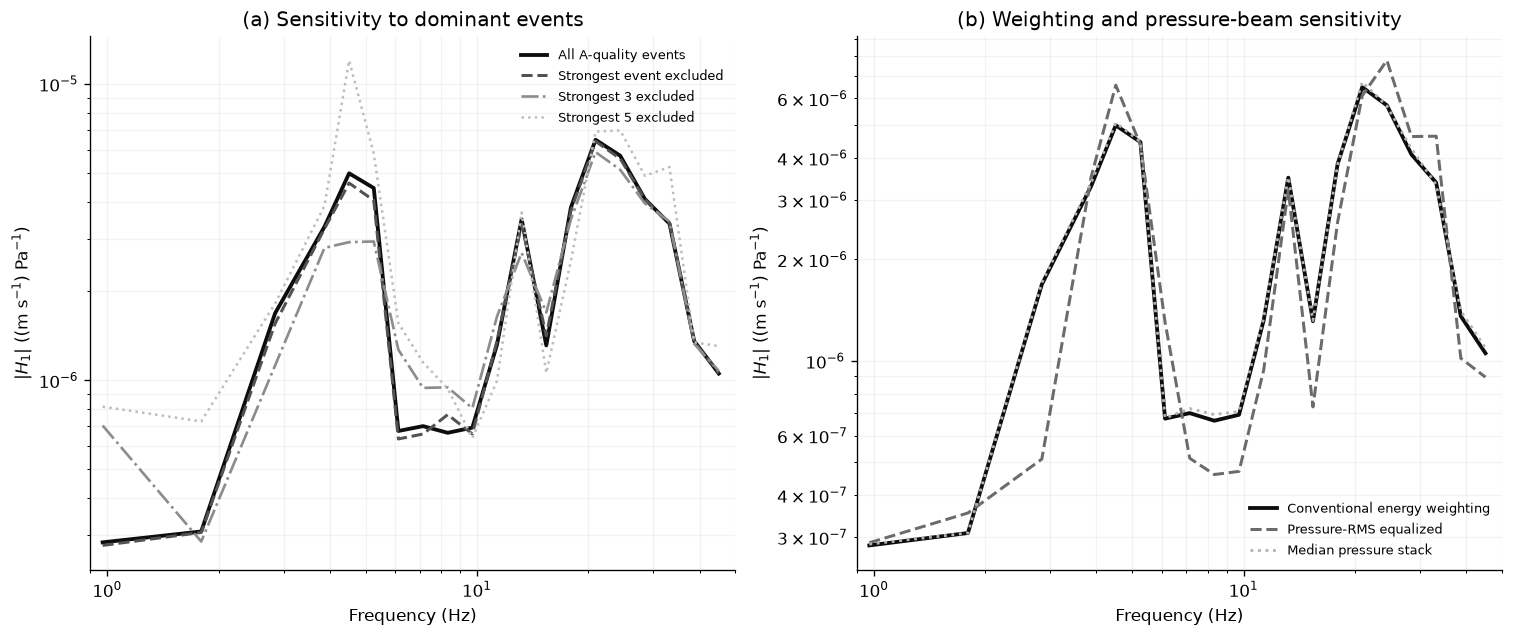

In [90]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.2), constrained_layout=True)

exclusion_styles = {
    0: dict(color="0.05", lw=2.3, ls="-", label="All A-quality events"),
    1: dict(color="0.32", lw=1.8, ls="--", label="Strongest event excluded"),
    3: dict(color="0.55", lw=1.6, ls="-.", label="Strongest 3 excluded"),
    5: dict(color="0.74", lw=1.5, ls=":", label="Strongest 5 excluded"),
}
for excluded_count, frame in dominant_event_transfer.groupby("excluded_strongest_event_count"):
    use = frame["frequency_hz"].between(TRANSFER_PLOT_MIN_HZ, TRANSFER_PLOT_MAX_HZ)
    axes[0].plot(
        frame.loc[use, "frequency_hz"], frame.loc[use, "h1_magnitude_mps_per_pa"],
        **exclusion_styles[int(excluded_count)],
    )

sensitivity_curves = [
    (event_ensemble_transfer, "Conventional energy weighting", "0.05", "-", 2.3),
    (event_equal_weighted, "Pressure-RMS equalized", "0.42", "--", 1.8),
    (event_median_weighted, "Median pressure stack", "0.70", ":", 1.7),
]
for frame, label, color, linestyle, linewidth in sensitivity_curves:
    use = frame["frequency_hz"].between(TRANSFER_PLOT_MIN_HZ, TRANSFER_PLOT_MAX_HZ)
    axes[1].plot(
        frame.loc[use, "frequency_hz"], frame.loc[use, "h1_magnitude_mps_per_pa"],
        color=color, ls=linestyle, lw=linewidth, label=label,
    )

axes[0].set_title("(a) Sensitivity to dominant events")
axes[1].set_title("(b) Weighting and pressure-beam sensitivity")
for ax in axes:
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlim(TRANSFER_PLOT_MIN_HZ, TRANSFER_PLOT_MAX_HZ)
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("$|H_1|$ ((m s$^{-1}$) Pa$^{-1}$)")
    ax.grid(True, which="both", alpha=0.15)
    ax.legend(frameon=False, fontsize=8)
figure_base = FIGURE_DIR / "supplement_transfer_robustness_tests"
fig.savefig(figure_base.with_suffix(".pdf"), bbox_inches="tight")
plt.show()


## Component PGV and measurement diagnostics

These plots check whether one seismic component dominates and whether the chosen
event interval excludes a larger motion elsewhere in the saved segment. Large
differences between event-window and entire-segment PGV should be reviewed before
physical interpretation.


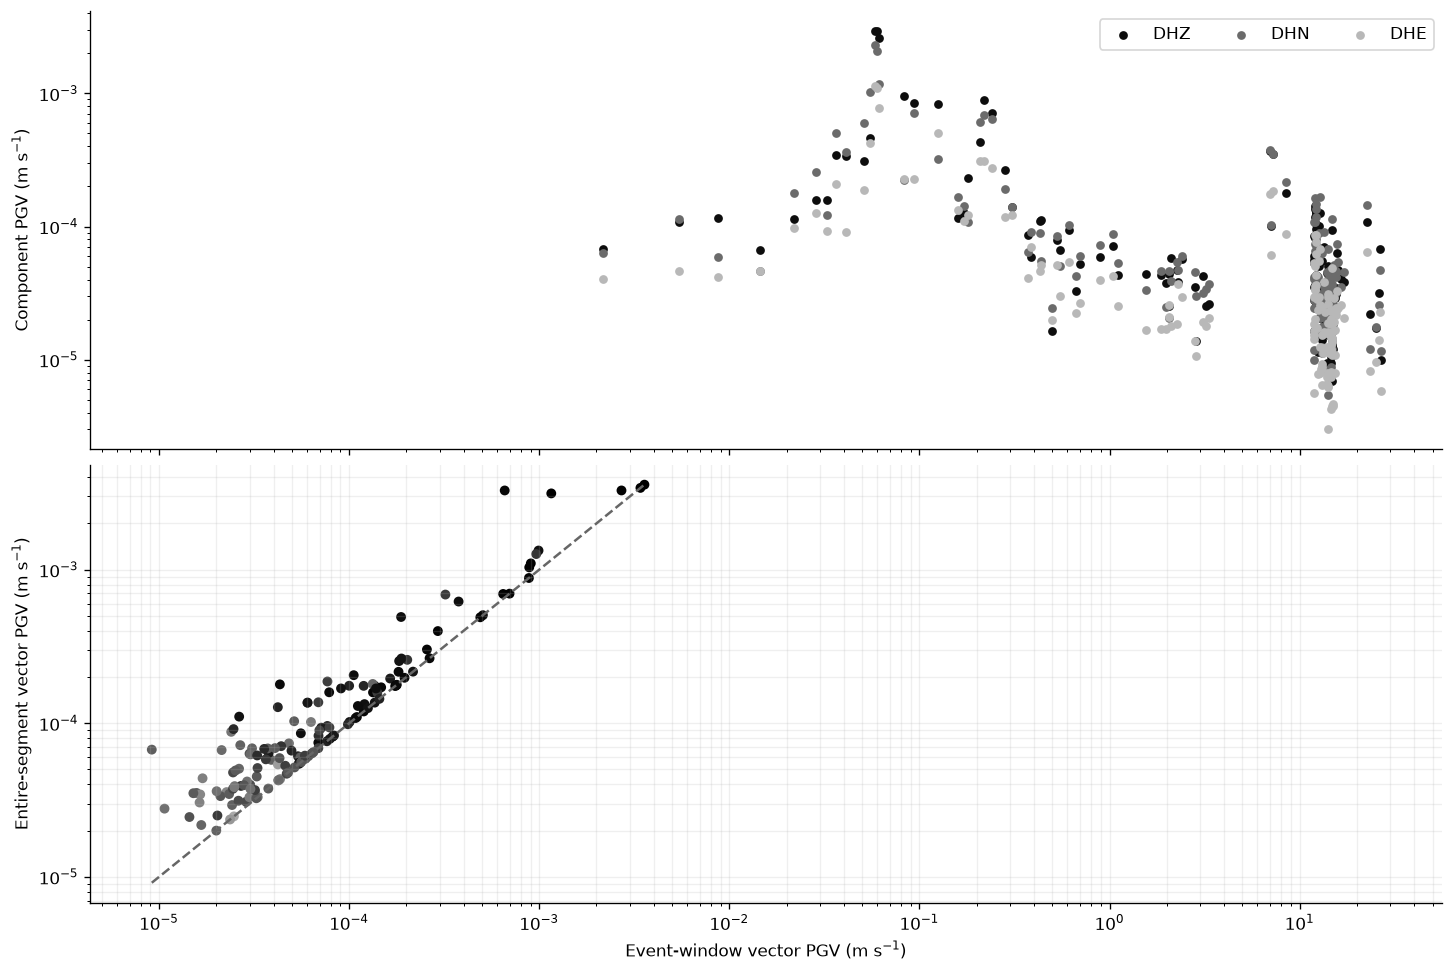

In [91]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True, constrained_layout=True)
axes[0].scatter(measurements["elapsed_time_min"], measurements["pgv_dhz_mps"], s=18, color="0.05", label="DHZ")
axes[0].scatter(measurements["elapsed_time_min"], measurements["pgv_dhn_mps"], s=18, color="0.42", label="DHN")
axes[0].scatter(measurements["elapsed_time_min"], measurements["pgv_dhe_mps"], s=18, color="0.72", label="DHE")
axes[0].set_yscale("log")
axes[0].set_ylabel("Component PGV (m s$^{-1}$)")
axes[0].legend(ncol=3)

axes[1].scatter(
    measurements["pgv_vector_mps"], measurements["pgv_entire_segment_vector_mps"],
    c=measurements.get("maximum_coherence_score", pd.Series(np.nan, index=measurements.index)),
    cmap="Greys", vmin=0, vmax=1, s=24,
)
finite = measurements[["pgv_vector_mps", "pgv_entire_segment_vector_mps"]].to_numpy(float)
positive = finite[np.isfinite(finite) & (finite > 0)]
if positive.size:
    lo, hi = positive.min(), positive.max()
    axes[1].plot([lo, hi], [lo, hi], color="0.4", ls="--")
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlabel("Event-window vector PGV (m s$^{-1}$)")
axes[1].set_ylabel("Entire-segment vector PGV (m s$^{-1}$)")
axes[1].grid(True, which="both", alpha=0.2)

fig.savefig(FIGURE_DIR / "pgv_component_and_window_diagnostics.pdf", bbox_inches="tight")
plt.show()


## Optional per-event diagnostic plots

Each diagnostic shows the locally baseline-corrected seismic components and
vector magnitude. The shaded interval is the interval used for catalogue PGV;
the dotted interval is the noise window. These figures are intended for auditing
the measurement, especially for the principal explosion and unusually large
pressure/PGV ratios.


In [92]:
if MAKE_EVENT_DIAGNOSTICS:
    rows_to_plot = measurements.sort_values("event_number")
    if MAX_DIAGNOSTIC_EVENTS is not None:
        rows_to_plot = rows_to_plot.head(MAX_DIAGNOSTIC_EVENTS)

    for row in rows_to_plot.itertuples(index=False):
        diagnostic = diagnostic_data.get(int(row.event_number))
        if diagnostic is None:
            continue
        times = diagnostic["times_s"]
        fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True, constrained_layout=True)
        for ax, channel in zip(axes[:3], SEISMIC_CHANNELS):
            ax.plot(times, diagnostic["corrected"][channel], color="black", lw=0.8)
            ax.set_ylabel(f"{channel}\n(m s$^{{-1}}$)")
        axes[3].plot(times, diagnostic["vector_velocity"], color="tab:blue", lw=0.9)
        axes[3].set_ylabel("Vector\n(m s$^{-1}$)")
        axes[3].set_xlabel("Time relative to reduced event time (s)")
        for ax in axes:
            ax.axvspan(*NOISE_WINDOW_S, color="0.7", alpha=0.18)
            ax.axvspan(*diagnostic["signal_window"], color="orange", alpha=0.15)
            ax.axhline(0, color="0.6", lw=0.5)
        fig.suptitle(
            f"Event {int(row.event_number):03d}: seismic PGV audit\n"
            f"PGV={row.pgv_vector_mps:.3g} m/s; p2p={row.acoustic_stack_peak_to_peak_pa:.3g} Pa; "
            f"ratio={row.p2p_pressure_to_vector_pgv:.3g} Pa per (m/s)"
        )
        fig.savefig(DIAGNOSTIC_DIR / f"event_{int(row.event_number):03d}_pgv.pdf", bbox_inches="tight")
        plt.close(fig)
    print("Diagnostic plots written to", DIAGNOSTIC_DIR)


Diagnostic plots written to /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/100_measure_event_amplitudes_and_acoustic_seismic_coupling/event_diagnostics


## Summary and interpretation safeguards

- Peak-to-peak pressure divided by PGV is a dimensional amplitude ratio, not an
  energy-partition ratio.
- Notebook 080 A/B/C classes describe directional array-solution quality; the
  amplitude regression uses independent SNR and window-capture criteria.
- The primary event H1 estimate uses a linear pressure beam and conventional
  acoustic-input-energy weighting. Dominant-event, equalized-weight, and
  median-beam results are explicit sensitivity tests.
- Continuous Phase I uses response-corrected data before nonlinear moving-median
  baseline removal, with a linear detrend applied independently to each 10-s
  segment.
- Bootstrap limits describe sampling variability within these records.
  Pressure–DHZ permutation thresholds are empirical within-dataset null tests.
- The event ensemble and Phase I analyses overlap in time and are consistency
  tests across analysis strategies, not independent datasets.
- Phase is exported in the complex spectra but is not interpreted as a single
  timing offset because phase behavior differs among coherent bands.

In [93]:
summary = {
    "events_in_catalogue": int(len(measurements)),
    "events_with_pgv": int(measurements["pgv_vector_mps"].notna().sum()),
    "median_peak_to_peak_pa": float(measurements["acoustic_stack_peak_to_peak_pa"].median()),
    "median_vector_pgv_mps": float(measurements["pgv_vector_mps"].median()),
    "median_p2p_pressure_to_vector_pgv": float(measurements["p2p_pressure_to_vector_pgv"].median()),
    "quality_class_counts": measurements["solution_quality_class"].value_counts().to_dict(),
    "regression_event_count": int(len(regression_events)),
    "regression_slope": float(regression_summary.iloc[0]["slope"]),
    "regression_slope_bootstrap_ci": [
        float(regression_summary.iloc[0]["slope_bootstrap_ci_low"]),
        float(regression_summary.iloc[0]["slope_bootstrap_ci_high"]),
    ],
    "regression_slope_without_principal": float(fit_without_principal.slope),
    "regression_spearman_rho": float(rank_result.statistic),
    "regression_equal_weight_odr_slope": float(orthogonal_result.beta[1]),
    "waveform_ensemble_event_count": int(len(waveform_ensemble_metadata)),
    "waveform_ensemble_time_range_s": [WAVEFORM_ENSEMBLE_MIN_S, WAVEFORM_ENSEMBLE_MAX_S],
    "waveform_ensemble_normalization": "per-event maximum absolute amplitude within signal window",
    "event_spectral_quality_class": SPECTRAL_QUALITY_CLASS,
    "event_spectral_event_count": int(len(spectral_event_metadata)),
    "event_spectral_frequency_range_hz": [SPECTRAL_MIN_HZ, SPECTRAL_MAX_HZ],
    "publication_transfer_plot_range_hz": [TRANSFER_PLOT_MIN_HZ, TRANSFER_PLOT_MAX_HZ],
    "event_spectral_median_resolution_hz": float(
        spectral_event_metadata["independent_minimum_frequency_hz"].median()
    ),
    "spectral_amplitude_ratio_definition": "DHZ velocity amplitude / pressure amplitude",
    "primary_transfer_estimator": "H1; aligned arithmetic-mean pressure beam; conventional acoustic-input-energy weighting",
    "event_transfer_record_count": len(event_transfer_records),
    "event_transfer_bootstrap_replicates": TRANSFER_BOOTSTRAP_REPLICATES,
    "event_transfer_permutation_replicates": TRANSFER_PERMUTATION_REPLICATES,
    "dominant_event_exclusion_counts": [0, 1, 3, 5],
    "phase1_source_interval_utc": [phase1_source_start.isoformat(), phase1_source_end.isoformat()],
    "phase1_segment_s": PHASE1_SEGMENT_S,
    "phase1_independent_segment_count": segment_count,
    "phase1_stream": str(continuous_stream_file),
    "phase1_baseline_treatment": "pre-baseline-removal stream; linear detrend per segment",
}
(OUTPUT_ROOT / "event_amplitude_coupling_summary.json").write_text(json.dumps(summary, indent=2))
display(pd.Series(summary, name="value").to_frame())
print("Primary table:", OUTPUT_ROOT / "event_acoustic_seismic_amplitudes.csv")
print("Figures:", FIGURE_DIR)


,value
events_in_catalogue,153
events_with_pgv,153
median_peak_to_peak_pa,29.516515
median_vector_pgv_mps,0.000056
median_p2p_pressure_to_vector_pgv,457701.642275
quality_class_counts,"{'C_weak_or_broad': 57, 'A_high_quality': 51, ..."
regression_event_count,46
regression_slope,0.96223
regression_slope_bootstrap_ci,"[0.8933673343440703, 1.0088307728147488]"
regression_slope_without_principal,0.958416


Primary table: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/100_measure_event_amplitudes_and_acoustic_seismic_coupling/event_acoustic_seismic_amplitudes.csv
Figures: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/100_measure_event_amplitudes_and_acoustic_seismic_coupling/figures


## Acoustic energetics of A-quality and named events

Energetics are calculated for the union of all Notebook 080 A-quality events and
five physically named events. Named events already belonging to the A-quality
set are included only once. The named events are matched to the nearest catalogue
source time and the mapping is exported for audit.

For each aligned pressure channel, a local median from the existing noise interval
is removed before integrating \(p^2(t)\) over the catalogue signal interval.
Peak SPL, sound exposure level, acoustic energy fluence, and radiated acoustic
energy are calculated independently for DD1–DD3. Event summaries are the median
and range across channels.

\[
L_{p,\mathrm{peak}}=20\log_{10}(p_\mathrm{peak}/20\,\mu\mathrm{Pa}),
\qquad
E_\mathrm{ac}=\frac{\Omega r^2}{\rho c}\int p^2(t)\,dt.
\]

The primary energy estimate assumes hemispherical radiation (\(\Omega=2\pi\));
the \(4\pi\) result is retained as a geometrical sensitivity bound. TNT
equivalents of radiated acoustic energy and efficiency-scaled total-energy
scenarios are not calibrated blast yields.

In [94]:
from obspy import UTCDateTime

ENERGETICS_QUALITY_CLASS = "A_high_quality"

NAMED_EVENT_KEYS = (
    "upper_stage",
    "lower_stage",
    "payload_impact",
    "payload_explosion",
    "event_024",
)
NAMED_EVENT_MATCH_TOLERANCE_S = 0.25

REFERENCE_PRESSURE_PA = 20.0e-6
REFERENCE_EXPOSURE_TIME_S = 1.0
ATMOSPHERIC_PRESSURE_PA = 101_325.0
JOULES_PER_KG_TNT = 4.184e6
PRIMARY_RADIATION_SOLID_ANGLE_SR = 2.0 * np.pi
SENSITIVITY_RADIATION_SOLID_ANGLE_SR = 4.0 * np.pi

# These values are transparent scenarios, not an inferred blast yield.
ACOUSTIC_EFFICIENCY_REFERENCE = 0.01
ACOUSTIC_EFFICIENCY_RANGE = (0.001, 0.10)

# The manual review in Notebook 110 showed that the leading payload-impact pulse
# begins slightly before its nominal reduced time. This override prevents the
# positive peak from being clipped. Other events use the event-specific windows defined above.
NAMED_SIGNAL_WINDOW_OVERRIDES_S = {
    "payload_impact": (-0.04, 0.33),
}

# Moist-air density. Replace standard pressure if a measured surface pressure
# becomes available; temperature and humidity are from Notebook 020.
temperature_c = float(weather_summary["mean_temperature_c"])
relative_humidity_fraction = (
    float(weather_summary["mean_relative_humidity_percent"]) / 100.0
)
temperature_k = temperature_c + 273.15
saturation_vapor_pressure_pa = 610.94 * np.exp(
    17.625 * temperature_c / (temperature_c + 243.04)
)
vapor_pressure_pa = relative_humidity_fraction * saturation_vapor_pressure_pa
dry_air_pressure_pa = ATMOSPHERIC_PRESSURE_PA - vapor_pressure_pa
AIR_DENSITY_KG_M3 = (
    dry_air_pressure_pa / (287.05 * temperature_k)
    + vapor_pressure_pa / (461.495 * temperature_k)
)

# The catalogue epoch is the reduced/reference arrival at DD2, whereas
# SOURCE_EVENT_TIMES contains source times. Add the predicted source-to-DD2
# travel time before matching. The approximately 352 m/s array velocity is not
# used here because it applies only to differential delays across the array.
REFERENCE_CHANNEL_DISTANCE_M = float(
    INFRASOUND_DISTANCES_M[ACOUSTIC_REFERENCE_CHANNEL]
)
REFERENCE_CHANNEL_TRAVEL_TIME_S = (
    REFERENCE_CHANNEL_DISTANCE_M
    / METEOROLOGICAL_EFFECTIVE_SOUND_SPEED_MPS
)

named_matches = []
catalogue_reference_epoch_s = measurements["reduced_event_epoch_s"].to_numpy(float)
named_source_epoch_by_key = {}
for key in NAMED_EVENT_KEYS:
    named_source_epoch_s = float(config.source_event_time(key).timestamp)
    named_source_epoch_by_key[key] = named_source_epoch_s
    predicted_reference_arrival_epoch_s = (
        named_source_epoch_s + REFERENCE_CHANNEL_TRAVEL_TIME_S
    )
    nearest_position = int(np.nanargmin(
        np.abs(catalogue_reference_epoch_s - predicted_reference_arrival_epoch_s)
    ))
    nearest = measurements.iloc[nearest_position]
    mismatch_s = float(
        nearest["reduced_event_epoch_s"] - predicted_reference_arrival_epoch_s
    )
    if abs(mismatch_s) > NAMED_EVENT_MATCH_TOLERANCE_S:
        raise ValueError(
            f"Named event {key!r} has no catalogue reference arrival within "
            f"{NAMED_EVENT_MATCH_TOLERANCE_S:.3f} s; "
            f"nearest mismatch={mismatch_s:+.3f} s"
        )
    named_matches.append({
        "named_event_key": key,
        "named_source_time_utc": UTCDateTime(named_source_epoch_s).isoformat(),
        "predicted_reference_arrival_utc": UTCDateTime(
            predicted_reference_arrival_epoch_s
        ).isoformat(),
        "event_number": int(nearest["event_number"]),
        "catalogue_reference_arrival_utc": pd.Timestamp(
            nearest["event_time"]
        ).isoformat(),
        "reference_arrival_mismatch_s": mismatch_s,
        "solution_quality_class": nearest["solution_quality_class"],
    })

named_event_matches = pd.DataFrame(named_matches)
if named_event_matches["event_number"].duplicated().any():
    raise ValueError("Two named source times matched the same catalogue event")

named_key_by_event_number = dict(zip(
    named_event_matches["event_number"].astype(int),
    named_event_matches["named_event_key"].astype(str),
))
named_numbers = set(named_key_by_event_number)

energetics_events = measurements.loc[
    (measurements["solution_quality_class"] == ENERGETICS_QUALITY_CLASS)
    | measurements["event_number"].isin(named_numbers)
].copy()
energetics_events["is_named_event"] = energetics_events["event_number"].isin(named_numbers)
energetics_events["named_event_key"] = energetics_events["event_number"].map(
    named_key_by_event_number
)
# Convert every catalogue reference-arrival epoch to an estimated source time.
# For named events, preserve the manually adopted canonical source time exactly.
energetics_events["estimated_source_epoch_s"] = (
    energetics_events["reduced_event_epoch_s"] - REFERENCE_CHANNEL_TRAVEL_TIME_S
)
for event_number, key in named_key_by_event_number.items():
    energetics_events.loc[
        energetics_events["event_number"].eq(event_number),
        "estimated_source_epoch_s",
    ] = named_source_epoch_by_key[key]
energetics_events["estimated_source_time"] = pd.to_datetime(
    energetics_events["estimated_source_epoch_s"], unit="s", utc=True
)
energetics_events["energetics_selection_reason"] = np.select(
    [
        (energetics_events["solution_quality_class"] == ENERGETICS_QUALITY_CLASS)
        & energetics_events["is_named_event"],
        energetics_events["solution_quality_class"] == ENERGETICS_QUALITY_CLASS,
        energetics_events["is_named_event"],
    ],
    ["A-quality and named", "A-quality", "named event"],
    default="unexpected",
)

print(f"Selected {len(energetics_events)} unique events")
print(
    f"A-quality={sum(energetics_events['solution_quality_class'] == ENERGETICS_QUALITY_CLASS)}, "
    f"named={sum(energetics_events['is_named_event'])}, "
    f"overlap={sum((energetics_events['solution_quality_class'] == ENERGETICS_QUALITY_CLASS) & energetics_events['is_named_event'])}"
)
print(
    f"Moist-air density={AIR_DENSITY_KG_M3:.4f} kg/m^3; "
    f"source-to-array effective speed={METEOROLOGICAL_EFFECTIVE_SOUND_SPEED_MPS:.1f} m/s"
)
display(named_event_matches)
display(energetics_events[[
    "event_number", "event_time", "estimated_source_time",
    "solution_quality_class", "is_named_event", "named_event_key",
    "energetics_selection_reason",
]])

Selected 51 unique events
A-quality=51, named=5, overlap=5
Moist-air density=1.1659 kg/m^3; source-to-array effective speed=351.0 m/s


,named_event_key,named_source_time_utc,predicted_reference_arrival_utc,event_number,catalogue_reference_arrival_utc,reference_arrival_mismatch_s,solution_quality_class
0,upper_stage,2016-09-01T13:07:11.913000,2016-09-01T13:07:15.925624,1,2016-09-01T13:07:15.927133560+00:00,0.001510,A_high_quality
1,lower_stage,2016-09-01T13:07:15.513600,2016-09-01T13:07:19.526224,14,2016-09-01T13:07:19.500133513+00:00,-0.026091,A_high_quality
2,payload_impact,2016-09-01T13:07:24.420000,2016-09-01T13:07:28.432624,22,2016-09-01T13:07:28.405903101+00:00,-0.026721,A_high_quality
3,payload_explosion,2016-09-01T13:07:24.987500,2016-09-01T13:07:29.000124,23,2016-09-01T13:07:28.985893250+00:00,-0.014231,A_high_quality
4,event_024,2016-09-01T13:07:26.458000,2016-09-01T13:07:30.470624,24,2016-09-01T13:07:30.451133490+00:00,-0.019490,A_high_quality


,event_number,event_time,estimated_source_time,solution_quality_class,is_named_event,named_event_key,energetics_selection_reason
0,1,2016-09-01 13:07:15.927133560+00:00,2016-09-01 13:07:11.912999868+00:00,A_high_quality,True,upper_stage,A-quality and named
1,2,2016-09-01 13:07:16.057133436+00:00,2016-09-01 13:07:12.044509411+00:00,A_high_quality,False,NaN,A-quality
2,3,2016-09-01 13:07:16.255000114+00:00,2016-09-01 13:07:12.242376089+00:00,A_high_quality,False,NaN,A-quality
7,8,2016-09-01 13:07:17.895133495+00:00,2016-09-01 13:07:13.882509470+00:00,A_high_quality,False,NaN,A-quality
8,9,2016-09-01 13:07:18.111133575+00:00,2016-09-01 13:07:14.098509550+00:00,A_high_quality,False,NaN,A-quality
9,10,2016-09-01 13:07:18.389066696+00:00,2016-09-01 13:07:14.376442671+00:00,A_high_quality,False,NaN,A-quality
10,11,2016-09-01 13:07:18.977133512+00:00,2016-09-01 13:07:14.964509487+00:00,A_high_quality,False,NaN,A-quality
11,12,2016-09-01 13:07:19.239566803+00:00,2016-09-01 13:07:15.226942778+00:00,A_high_quality,False,NaN,A-quality
12,13,2016-09-01 13:07:19.427133560+00:00,2016-09-01 13:07:15.414509535+00:00,A_high_quality,False,NaN,A-quality
13,14,2016-09-01 13:07:19.500133513+00:00,2016-09-01 13:07:15.513600111+00:00,A_high_quality,True,lower_stage,A-quality and named


In [95]:
def positive_level_db(value_squared, reference_squared):
    if not np.isfinite(value_squared) or value_squared <= 0:
        return np.nan
    return float(10.0 * np.log10(value_squared / reference_squared))


energetics_channel_rows = []

for event in energetics_events.itertuples(index=False):
    event_number = int(event.event_number)
    diagnostic = diagnostic_data.get(event_number)
    if diagnostic is None:
        raise KeyError(f"No diagnostic waveform data for event {event_number}")

    times_s = np.asarray(diagnostic["times_s"], dtype=float)
    aligned_pressure = np.asarray(diagnostic["aligned_pressure"], dtype=float)
    if aligned_pressure.shape[0] != len(INFRASOUND_CHANNELS):
        raise ValueError(f"Unexpected pressure matrix for event {event_number}")

    signal_start_s, signal_end_s = map(float, diagnostic["signal_window"])
    named_key = named_key_by_event_number.get(event_number)
    if named_key in NAMED_SIGNAL_WINDOW_OVERRIDES_S:
        signal_start_s, signal_end_s = NAMED_SIGNAL_WINDOW_OVERRIDES_S[named_key]

    noise_mask = (
        (times_s >= NOISE_WINDOW_S[0])
        & (times_s <= NOISE_WINDOW_S[1])
    )
    signal_mask = (
        (times_s >= signal_start_s)
        & (times_s <= signal_end_s)
    )
    if noise_mask.sum() < 3 or signal_mask.sum() < 3:
        raise ValueError(
            f"Insufficient energetics samples for event {event_number}: "
            f"noise={noise_mask.sum()}, signal={signal_mask.sum()}"
        )

    for channel_index, channel in enumerate(INFRASOUND_CHANNELS):
        pressure = aligned_pressure[channel_index].astype(float, copy=True)
        finite_noise = noise_mask & np.isfinite(pressure)
        finite_signal = signal_mask & np.isfinite(pressure)
        if finite_noise.sum() < 3 or finite_signal.sum() < 3:
            raise ValueError(
                f"Insufficient finite samples for event {event_number} {channel}"
            )

        local_baseline_pa = float(np.nanmedian(pressure[finite_noise]))
        pressure -= local_baseline_pa
        signal_time_s = times_s[finite_signal]
        signal_pressure_pa = pressure[finite_signal]

        positive_peak_pa = float(np.nanmax(signal_pressure_pa))
        negative_peak_pa = float(np.nanmin(signal_pressure_pa))
        absolute_peak_pa = float(np.nanmax(np.abs(signal_pressure_pa)))
        peak_to_peak_pa = positive_peak_pa - negative_peak_pa
        pressure_squared_exposure_pa2_s = float(
            np.trapezoid(signal_pressure_pa**2, signal_time_s)
        )

        energy_fluence_j_m2 = (
            pressure_squared_exposure_pa2_s
            / (AIR_DENSITY_KG_M3 * METEOROLOGICAL_EFFECTIVE_SOUND_SPEED_MPS)
        )
        distance_m = float(INFRASOUND_DISTANCES_M[channel])
        acoustic_energy_2pi_j = (
            PRIMARY_RADIATION_SOLID_ANGLE_SR * distance_m**2
            * energy_fluence_j_m2
        )
        acoustic_energy_4pi_j = (
            SENSITIVITY_RADIATION_SOLID_ANGLE_SR * distance_m**2
            * energy_fluence_j_m2
        )
        acoustic_tnt_2pi_kg = acoustic_energy_2pi_j / JOULES_PER_KG_TNT

        energetics_channel_rows.append({
            "event_number": event_number,
            "catalogue_reference_arrival_time": event.event_time,
            "estimated_source_time": event.estimated_source_time,
            "solution_quality_class": event.solution_quality_class,
            "is_named_event": bool(event.is_named_event),
            "named_event_key": named_key,
            "energetics_selection_reason": event.energetics_selection_reason,
            "channel": channel,
            "distance_m": distance_m,
            "signal_start_s": signal_start_s,
            "signal_end_s": signal_end_s,
            "signal_duration_s": signal_end_s - signal_start_s,
            "local_baseline_pa": local_baseline_pa,
            "positive_peak_pa": positive_peak_pa,
            "negative_peak_pa": negative_peak_pa,
            "absolute_peak_pa": absolute_peak_pa,
            "peak_to_peak_pa": peak_to_peak_pa,
            "positive_peak_spl_db": positive_level_db(
                positive_peak_pa**2, REFERENCE_PRESSURE_PA**2
            ),
            "peak_spl_db": positive_level_db(
                absolute_peak_pa**2, REFERENCE_PRESSURE_PA**2
            ),
            "pressure_squared_exposure_pa2_s": pressure_squared_exposure_pa2_s,
            "sound_exposure_level_db": positive_level_db(
                pressure_squared_exposure_pa2_s,
                REFERENCE_PRESSURE_PA**2 * REFERENCE_EXPOSURE_TIME_S,
            ),
            "acoustic_energy_fluence_j_m2": energy_fluence_j_m2,
            "acoustic_energy_2pi_j": acoustic_energy_2pi_j,
            "acoustic_energy_4pi_j": acoustic_energy_4pi_j,
            "acoustic_tnt_equivalent_2pi_kg": acoustic_tnt_2pi_kg,
            "illustrative_total_tnt_at_reference_efficiency_kg": (
                acoustic_tnt_2pi_kg / ACOUSTIC_EFFICIENCY_REFERENCE
            ),
            "illustrative_total_tnt_lower_kg": (
                acoustic_tnt_2pi_kg / max(ACOUSTIC_EFFICIENCY_RANGE)
            ),
            "illustrative_total_tnt_upper_kg": (
                acoustic_tnt_2pi_kg / min(ACOUSTIC_EFFICIENCY_RANGE)
            ),
        })

event_acoustic_energetics_by_channel = pd.DataFrame(energetics_channel_rows)
expected_rows = len(energetics_events) * len(INFRASOUND_CHANNELS)
if len(event_acoustic_energetics_by_channel) != expected_rows:
    raise RuntimeError(
        f"Expected {expected_rows} channel-event rows; "
        f"found {len(event_acoustic_energetics_by_channel)}"
    )

summary_fields = (
    "positive_peak_pa", "negative_peak_pa", "peak_to_peak_pa",
    "positive_peak_spl_db", "peak_spl_db", "sound_exposure_level_db",
    "pressure_squared_exposure_pa2_s", "acoustic_energy_2pi_j",
    "acoustic_energy_4pi_j", "acoustic_tnt_equivalent_2pi_kg",
    "illustrative_total_tnt_at_reference_efficiency_kg",
    "illustrative_total_tnt_lower_kg", "illustrative_total_tnt_upper_kg",
)

summary_rows = []
for event_number, subset in event_acoustic_energetics_by_channel.groupby(
    "event_number", sort=False
):
    first = subset.iloc[0]
    row = {
        "event_number": int(event_number),
        "catalogue_reference_arrival_time": first["catalogue_reference_arrival_time"],
        "estimated_source_time": first["estimated_source_time"],
        "solution_quality_class": first["solution_quality_class"],
        "is_named_event": bool(first["is_named_event"]),
        "named_event_key": first["named_event_key"],
        "energetics_selection_reason": first["energetics_selection_reason"],
        "channel_count": int(len(subset)),
    }
    for field in summary_fields:
        values = subset[field].to_numpy(float)
        row[f"median_{field}"] = float(np.nanmedian(values))
        row[f"minimum_{field}"] = float(np.nanmin(values))
        row[f"maximum_{field}"] = float(np.nanmax(values))
    summary_rows.append(row)

event_acoustic_energetics_summary = pd.DataFrame(summary_rows).sort_values(
    "event_number"
).reset_index(drop=True)

display(event_acoustic_energetics_summary[[
    "event_number", "estimated_source_time", "solution_quality_class",
    "named_event_key", "median_positive_peak_spl_db",
    "median_sound_exposure_level_db", "median_acoustic_energy_2pi_j",
    "minimum_acoustic_energy_2pi_j", "maximum_acoustic_energy_2pi_j",
    "median_acoustic_tnt_equivalent_2pi_kg",
]])

,event_number,estimated_source_time,solution_quality_class,named_event_key,median_positive_peak_spl_db,median_sound_exposure_level_db,median_acoustic_energy_2pi_j,minimum_acoustic_energy_2pi_j,maximum_acoustic_energy_2pi_j,median_acoustic_tnt_equivalent_2pi_kg
0,1,2016-09-01 13:07:11.912999868+00:00,A_high_quality,upper_stage,127.946557,109.901105,1.190739e+06,8.507644e+05,2.485885e+06,0.284594
1,2,2016-09-01 13:07:12.044509411+00:00,A_high_quality,NaN,119.546684,108.914455,9.918381e+05,9.320834e+05,1.050701e+06,0.237055
2,3,2016-09-01 13:07:12.242376089+00:00,A_high_quality,NaN,125.129876,107.346459,6.912597e+05,6.513342e+05,6.995939e+05,0.165215
3,8,2016-09-01 13:07:13.882509470+00:00,A_high_quality,NaN,123.444443,107.583299,7.027758e+05,6.410052e+05,1.039571e+06,0.167967
4,9,2016-09-01 13:07:14.098509550+00:00,A_high_quality,NaN,134.938495,118.147177,8.002111e+06,7.411288e+06,8.100651e+06,1.912550
5,10,2016-09-01 13:07:14.376442671+00:00,A_high_quality,NaN,113.684264,114.931208,3.815994e+06,1.403873e+06,4.380954e+06,0.912045
6,11,2016-09-01 13:07:14.964509487+00:00,A_high_quality,NaN,128.987803,120.795410,1.472407e+07,8.911086e+06,1.477628e+07,3.519137
7,12,2016-09-01 13:07:15.226942778+00:00,A_high_quality,NaN,138.311324,123.309776,2.627027e+07,2.191506e+07,2.631256e+07,6.278744
8,13,2016-09-01 13:07:15.414509535+00:00,A_high_quality,NaN,156.471454,141.922084,1.908514e+09,1.634799e+09,2.338211e+09,456.145733
9,14,2016-09-01 13:07:15.513600111+00:00,A_high_quality,lower_stage,156.468563,141.890675,1.894761e+09,1.624060e+09,2.277116e+09,452.858693


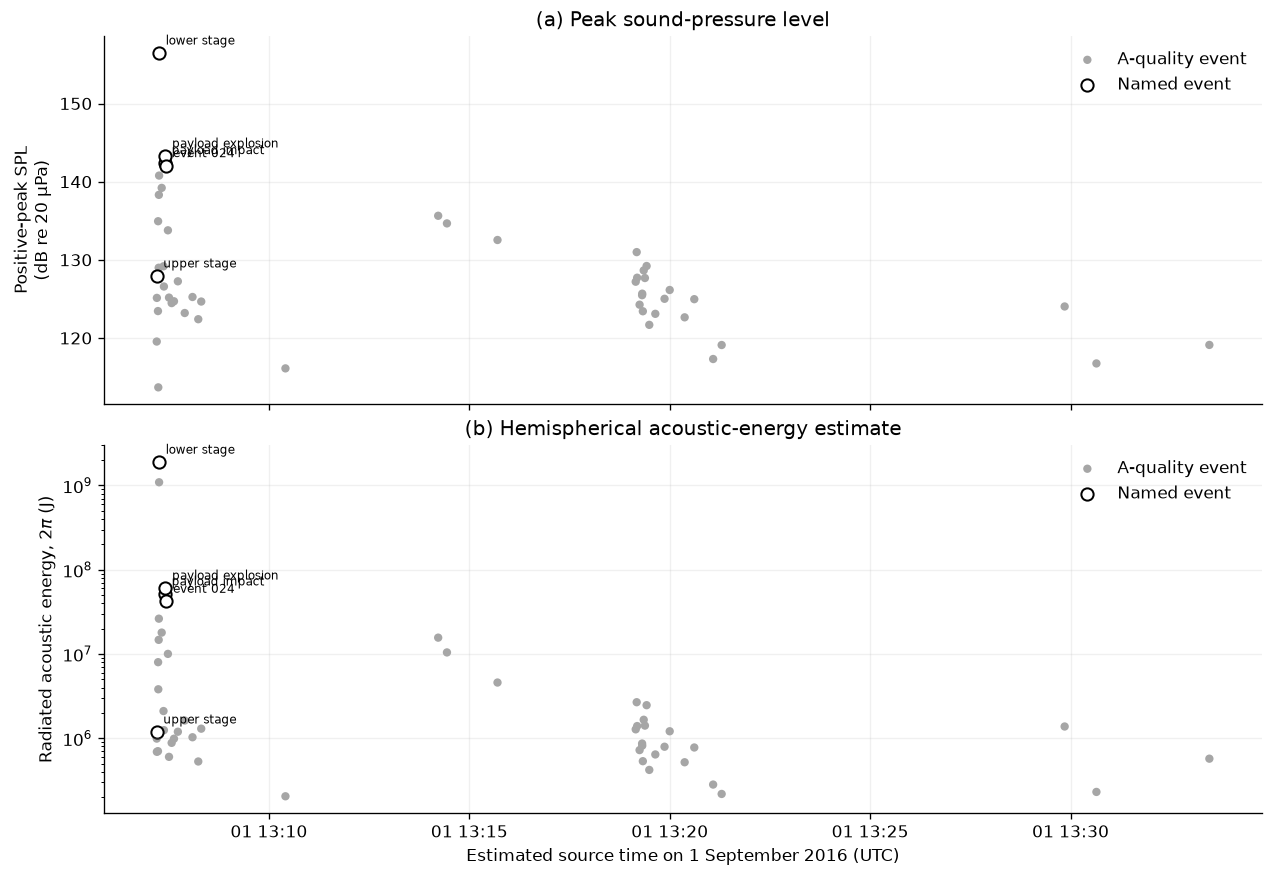

Wrote: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/100_measure_event_amplitudes_and_acoustic_seismic_coupling/a_quality_and_named_event_acoustic_energetics_by_channel.csv
Wrote: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/100_measure_event_amplitudes_and_acoustic_seismic_coupling/a_quality_and_named_event_acoustic_energetics_summary.csv
Wrote: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/100_measure_event_amplitudes_and_acoustic_seismic_coupling/named_event_catalogue_matches.csv
Wrote: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/100_measure_event_amplitudes_and_acoustic_seismic_coupling/acoustic_energetics_metadata.json


In [96]:
# Diagnostic overview of raw catalogue windows. Overlapping windows can contain
# the same physical pulse and must not be summed; merged-complex results follow. Grayscale encodes array quality; named events are
# outlined and labelled. All selected non-named events are A quality by design.
fig, axes = plt.subplots(2, 1, figsize=(10.5, 7.2), sharex=True, constrained_layout=True)

plot = event_acoustic_energetics_summary.copy()
plot["estimated_source_time"] = pd.to_datetime(
    plot["estimated_source_time"], utc=True
)
ordinary = ~plot["is_named_event"]
named = plot["is_named_event"]

axes[0].scatter(
    plot.loc[ordinary, "estimated_source_time"],
    plot.loc[ordinary, "median_positive_peak_spl_db"],
    s=25, color="0.65", edgecolor="none", label="A-quality event",
)
axes[0].scatter(
    plot.loc[named, "estimated_source_time"],
    plot.loc[named, "median_positive_peak_spl_db"],
    s=54, facecolor="white", edgecolor="black", linewidth=1.2,
    label="Named event",
)
axes[0].set_ylabel("Positive-peak SPL\n(dB re 20 µPa)")
axes[0].set_title("(a) Peak sound-pressure level")

axes[1].scatter(
    plot.loc[ordinary, "estimated_source_time"],
    plot.loc[ordinary, "median_acoustic_energy_2pi_j"],
    s=25, color="0.65", edgecolor="none", label="A-quality event",
)
axes[1].scatter(
    plot.loc[named, "estimated_source_time"],
    plot.loc[named, "median_acoustic_energy_2pi_j"],
    s=54, facecolor="white", edgecolor="black", linewidth=1.2,
    label="Named event",
)
axes[1].set_yscale("log")
axes[1].set_ylabel("Radiated acoustic energy, $2\\pi$ (J)")
axes[1].set_xlabel("Estimated source time on 1 September 2016 (UTC)")
axes[1].set_title("(b) Hemispherical acoustic-energy estimate")

for _, row in plot.loc[named].iterrows():
    label = str(row["named_event_key"]).replace("_", " ")
    for ax, field in (
        (axes[0], "median_positive_peak_spl_db"),
        (axes[1], "median_acoustic_energy_2pi_j"),
    ):
        ax.annotate(
            label, (row["estimated_source_time"], row[field]),
            xytext=(4, 5), textcoords="offset points", fontsize=7,
        )

for ax in axes:
    ax.grid(True, alpha=0.18)
    ax.legend(frameon=False, loc="best")

fig.savefig(FIGURE_DIR / "raw_overlapping_event_window_acoustic_energetics.pdf", bbox_inches="tight")
plt.show()

ENERGETICS_CHANNEL_FILE = OUTPUT_ROOT / "a_quality_and_named_event_acoustic_energetics_by_channel.csv"
ENERGETICS_SUMMARY_FILE = OUTPUT_ROOT / "a_quality_and_named_event_acoustic_energetics_summary.csv"
NAMED_MATCH_FILE = OUTPUT_ROOT / "named_event_catalogue_matches.csv"
ENERGETICS_METADATA_FILE = OUTPUT_ROOT / "acoustic_energetics_metadata.json"

event_acoustic_energetics_by_channel.to_csv(ENERGETICS_CHANNEL_FILE, index=False)
event_acoustic_energetics_summary.to_csv(ENERGETICS_SUMMARY_FILE, index=False)
named_event_matches.to_csv(NAMED_MATCH_FILE, index=False)

energetics_metadata = {
    "producer_notebook": "100_measure_event_amplitudes_and_acoustic_seismic_coupling.ipynb",
    "selection": "union of Notebook 080 A_high_quality and five named events",
    "selected_unique_event_count": int(len(energetics_events)),
    "a_quality_count": int(sum(energetics_events["solution_quality_class"] == ENERGETICS_QUALITY_CLASS)),
    "named_event_count": int(sum(energetics_events["is_named_event"])),
    "a_quality_named_overlap_count": int(sum(
        (energetics_events["solution_quality_class"] == ENERGETICS_QUALITY_CLASS)
        & energetics_events["is_named_event"]
    )),
    "named_event_keys": list(NAMED_EVENT_KEYS),
    "named_match_tolerance_s": NAMED_EVENT_MATCH_TOLERANCE_S,
    "catalogue_epoch_timebase": "reference arrival at DD2",
    "reference_channel": ACOUSTIC_REFERENCE_CHANNEL,
    "reference_channel_distance_m": REFERENCE_CHANNEL_DISTANCE_M,
    "reference_channel_travel_time_s": REFERENCE_CHANNEL_TRAVEL_TIME_S,
    "signal_window_overrides_s": {
        key: list(value) for key, value in NAMED_SIGNAL_WINDOW_OVERRIDES_S.items()
    },
    "pressure_reference_pa": REFERENCE_PRESSURE_PA,
    "effective_sound_speed_mps": METEOROLOGICAL_EFFECTIVE_SOUND_SPEED_MPS,
    "differential_alignment_speed_mps": ACOUSTIC_ALIGNMENT_SPEED_MPS,
    "atmospheric_pressure_pa_assumed": ATMOSPHERIC_PRESSURE_PA,
    "mean_temperature_c": temperature_c,
    "mean_relative_humidity_percent": 100.0 * relative_humidity_fraction,
    "computed_air_density_kg_m3": AIR_DENSITY_KG_M3,
    "primary_radiation_solid_angle_sr": PRIMARY_RADIATION_SOLID_ANGLE_SR,
    "sensitivity_radiation_solid_angle_sr": SENSITIVITY_RADIATION_SOLID_ANGLE_SR,
    "joules_per_kg_tnt": JOULES_PER_KG_TNT,
    "acoustic_efficiency_reference": ACOUSTIC_EFFICIENCY_REFERENCE,
    "acoustic_efficiency_range": list(ACOUSTIC_EFFICIENCY_RANGE),
    "interpretation_warning": (
        "Radiated acoustic-energy TNT equivalent is not total explosive yield; "
        "efficiency-scaled equivalents are provisional scenarios only."
    ),
    "channel_output_file": str(ENERGETICS_CHANNEL_FILE),
    "summary_output_file": str(ENERGETICS_SUMMARY_FILE),
    "named_match_file": str(NAMED_MATCH_FILE),
}
ENERGETICS_METADATA_FILE.write_text(json.dumps(energetics_metadata, indent=2) + "\n")

print("Wrote:", ENERGETICS_CHANNEL_FILE)
print("Wrote:", ENERGETICS_SUMMARY_FILE)
print("Wrote:", NAMED_MATCH_FILE)
print("Wrote:", ENERGETICS_METADATA_FILE)

## De-duplicated event complexes and cumulative acoustic energy

Individual catalogue windows are not statistically or energetically independent:
adjacent windows can contain the same pressure pulse. In particular, several
catalogue events surround the principal lower-stage explosion. Summing their
separate pressure-squared integrals would count the principal blast more than
once.

We therefore merge every temporally overlapping selected-event interval into a
single event complex. The pressure traces are sampled directly from the continuous
Notebook 010 baseline-corrected stream, differentially aligned to DD2, and
\(p^2(t)\) is integrated once across each merged union interval. Cumulative energy
is the sum of these mutually disjoint complex energies. It represents the union
of all A-quality and named-event intervals, not the energy of unselected signals
between those intervals.

In [97]:
# Construct absolute DD2-time intervals for every selected catalogue window.
interval_rows = []
for event in energetics_events.itertuples(index=False):
    diagnostic = diagnostic_data[int(event.event_number)]
    signal_start_s, signal_end_s = map(float, diagnostic["signal_window"])
    named_key = named_key_by_event_number.get(int(event.event_number))
    if named_key in NAMED_SIGNAL_WINDOW_OVERRIDES_S:
        signal_start_s, signal_end_s = NAMED_SIGNAL_WINDOW_OVERRIDES_S[named_key]
    reference_epoch_s = float(event.reduced_event_epoch_s)
    interval_rows.append({
        "event_number": int(event.event_number),
        "named_event_key": named_key,
        "is_named_event": bool(event.is_named_event),
        "solution_quality_class": event.solution_quality_class,
        "reference_epoch_s": reference_epoch_s,
        "interval_start_epoch_s": reference_epoch_s + signal_start_s,
        "interval_end_epoch_s": reference_epoch_s + signal_end_s,
    })

selected_event_intervals = pd.DataFrame(interval_rows).sort_values(
    ["interval_start_epoch_s", "interval_end_epoch_s"]
).reset_index(drop=True)

# Merge the closed intervals. Touching intervals are treated as one complex.
complex_members = []
current = None
for row in selected_event_intervals.itertuples(index=False):
    if current is None or row.interval_start_epoch_s > current["end_epoch_s"]:
        if current is not None:
            complex_members.append(current)
        current = {
            "start_epoch_s": float(row.interval_start_epoch_s),
            "end_epoch_s": float(row.interval_end_epoch_s),
            "members": [row],
        }
    else:
        current["end_epoch_s"] = max(current["end_epoch_s"], float(row.interval_end_epoch_s))
        current["members"].append(row)
if current is not None:
    complex_members.append(current)

complex_definition_rows = []
for complex_number, item in enumerate(complex_members, start=1):
    members = item["members"]
    numbers = [int(row.event_number) for row in members]
    named_keys = [str(row.named_event_key) for row in members if pd.notna(row.named_event_key)]
    member_reference_epochs = [float(row.reference_epoch_s) for row in members]
    complex_definition_rows.append({
        "complex_number": complex_number,
        "complex_start_epoch_s": item["start_epoch_s"],
        "complex_end_epoch_s": item["end_epoch_s"],
        "complex_duration_s": item["end_epoch_s"] - item["start_epoch_s"],
        "member_event_numbers": ",".join(map(str, numbers)),
        "member_event_count": len(numbers),
        "named_event_keys": ",".join(named_keys),
        "contains_named_event": bool(named_keys),
        "first_member_reference_epoch_s": min(member_reference_epochs),
    })

event_complex_definitions = pd.DataFrame(complex_definition_rows)
print(
    f"Merged {len(selected_event_intervals)} selected event windows into "
    f"{len(event_complex_definitions)} non-overlapping complexes"
)
display(event_complex_definitions.loc[event_complex_definitions["member_event_count"] > 1])

Merged 51 selected event windows into 47 non-overlapping complexes


,complex_number,complex_start_epoch_s,complex_end_epoch_s,complex_duration_s,member_event_numbers,member_event_count,named_event_keys,contains_named_event,first_member_reference_epoch_s
0,1,1.472735e+09,1.472735e+09,0.319134,"1,2",2,upper_stage,True,1.472735e+09
7,8,1.472735e+09,1.472735e+09,0.390000,"13,14,15",3,lower_stage,True,1.472735e+09
31,32,1.472736e+09,1.472736e+09,0.108000,"70,71",2,,False,1.472736e+09


In [98]:
# Load the continuous baseline-corrected pressure product so every union interval
# is integrated once, independently of how many catalogue windows contributed.
baseline_products = analysis_config.get("baseline_removed_streams", {})
CONTINUOUS_BASELINE_STREAM_FILE = Path(
    baseline_products.get(
        "pickle",
        config.NB010_DIR / "bchh_corrected_moving_median_baseline_removed.pkl",
    )
).expanduser()
if not CONTINUOUS_BASELINE_STREAM_FILE.exists():
    raise FileNotFoundError(CONTINUOUS_BASELINE_STREAM_FILE)
continuous_baseline_stream = read(str(CONTINUOUS_BASELINE_STREAM_FILE), format="PICKLE")


def exactly_one_trace(stream, channel):
    matches = stream.select(channel=channel)
    if len(matches) != 1:
        raise ValueError(f"Expected one {channel} trace; found {len(matches)}")
    return matches[0]


complex_channel_rows = []
for complex_row in event_complex_definitions.itertuples(index=False):
    # Use the earliest member's reference time for the local pre-event baseline.
    reference_epoch_s = float(complex_row.first_member_reference_epoch_s)
    baseline_start_s = reference_epoch_s + NOISE_WINDOW_S[0]
    baseline_end_s = reference_epoch_s + NOISE_WINDOW_S[1]
    if baseline_end_s >= complex_row.complex_start_epoch_s:
        baseline_end_s = complex_row.complex_start_epoch_s - 0.01
    if baseline_end_s <= baseline_start_s:
        raise ValueError(f"No clean baseline for complex {complex_row.complex_number}")

    rates = [
        float(exactly_one_trace(continuous_baseline_stream, ch).stats.sampling_rate)
        for ch in INFRASOUND_CHANNELS
    ]
    sampling_rate_hz = min(rates)
    dt_s = 1.0 / sampling_rate_hz
    relative_start_s = baseline_start_s - reference_epoch_s
    relative_end_s = complex_row.complex_end_epoch_s - reference_epoch_s
    times_s = np.arange(relative_start_s, relative_end_s + 0.5 * dt_s, dt_s)
    absolute_epoch_s = reference_epoch_s + times_s
    baseline_mask = (absolute_epoch_s >= baseline_start_s) & (absolute_epoch_s <= baseline_end_s)
    signal_mask = (
        (absolute_epoch_s >= complex_row.complex_start_epoch_s)
        & (absolute_epoch_s <= complex_row.complex_end_epoch_s)
    )

    for channel in INFRASOUND_CHANNELS:
        trace = exactly_one_trace(continuous_baseline_stream, channel)
        delay_s = (
            INFRASOUND_DISTANCES_M[channel]
            - INFRASOUND_DISTANCES_M[ACOUSTIC_REFERENCE_CHANNEL]
        ) / ACOUSTIC_ALIGNMENT_SPEED_MPS
        pressure_pa = interpolate_trace(trace, reference_epoch_s, times_s + delay_s)
        finite_baseline = baseline_mask & np.isfinite(pressure_pa)
        finite_signal = signal_mask & np.isfinite(pressure_pa)
        if finite_baseline.sum() < 3 or finite_signal.sum() < 3:
            raise ValueError(
                f"Insufficient samples for complex {complex_row.complex_number} {channel}"
            )
        local_baseline_pa = float(np.nanmedian(pressure_pa[finite_baseline]))
        centered_pa = pressure_pa - local_baseline_pa
        signal_pressure_pa = centered_pa[finite_signal]
        signal_time_s = absolute_epoch_s[finite_signal]
        positive_peak_pa = float(np.nanmax(signal_pressure_pa))
        negative_peak_pa = float(np.nanmin(signal_pressure_pa))
        absolute_peak_pa = float(np.nanmax(np.abs(signal_pressure_pa)))
        exposure_pa2_s = float(np.trapezoid(signal_pressure_pa**2, signal_time_s))
        energy_fluence_j_m2 = exposure_pa2_s / (
            AIR_DENSITY_KG_M3 * METEOROLOGICAL_EFFECTIVE_SOUND_SPEED_MPS
        )
        distance_m = float(INFRASOUND_DISTANCES_M[channel])
        energy_2pi_j = PRIMARY_RADIATION_SOLID_ANGLE_SR * distance_m**2 * energy_fluence_j_m2
        energy_4pi_j = SENSITIVITY_RADIATION_SOLID_ANGLE_SR * distance_m**2 * energy_fluence_j_m2
        acoustic_tnt_kg = energy_2pi_j / JOULES_PER_KG_TNT
        complex_channel_rows.append({
            "complex_number": int(complex_row.complex_number),
            "complex_start_epoch_s": float(complex_row.complex_start_epoch_s),
            "complex_end_epoch_s": float(complex_row.complex_end_epoch_s),
            "first_member_reference_epoch_s": float(complex_row.first_member_reference_epoch_s),
            "member_event_numbers": complex_row.member_event_numbers,
            "member_event_count": int(complex_row.member_event_count),
            "named_event_keys": complex_row.named_event_keys,
            "contains_named_event": bool(complex_row.contains_named_event),
            "channel": channel,
            "distance_m": distance_m,
            "local_baseline_pa": local_baseline_pa,
            "positive_peak_pa": positive_peak_pa,
            "negative_peak_pa": negative_peak_pa,
            "peak_to_peak_pa": positive_peak_pa - negative_peak_pa,
            "positive_peak_spl_db": positive_level_db(positive_peak_pa**2, REFERENCE_PRESSURE_PA**2),
            "peak_spl_db": positive_level_db(absolute_peak_pa**2, REFERENCE_PRESSURE_PA**2),
            "pressure_squared_exposure_pa2_s": exposure_pa2_s,
            "sound_exposure_level_db": positive_level_db(
                exposure_pa2_s, REFERENCE_PRESSURE_PA**2 * REFERENCE_EXPOSURE_TIME_S
            ),
            "acoustic_energy_2pi_j": energy_2pi_j,
            "acoustic_energy_4pi_j": energy_4pi_j,
            "acoustic_energy_equivalent_kg_tnt": acoustic_tnt_kg,
            "illustrative_total_yield_at_1pct_kg_tnt": acoustic_tnt_kg / ACOUSTIC_EFFICIENCY_REFERENCE,
            "illustrative_total_yield_lower_kg_tnt": acoustic_tnt_kg / max(ACOUSTIC_EFFICIENCY_RANGE),
            "illustrative_total_yield_upper_kg_tnt": acoustic_tnt_kg / min(ACOUSTIC_EFFICIENCY_RANGE),
        })

event_complex_energetics_by_channel = pd.DataFrame(complex_channel_rows)

complex_summary_rows = []
numeric_fields = (
    "positive_peak_pa", "negative_peak_pa", "peak_to_peak_pa",
    "positive_peak_spl_db", "peak_spl_db", "sound_exposure_level_db",
    "pressure_squared_exposure_pa2_s", "acoustic_energy_2pi_j",
    "acoustic_energy_4pi_j", "acoustic_energy_equivalent_kg_tnt",
    "illustrative_total_yield_at_1pct_kg_tnt",
    "illustrative_total_yield_lower_kg_tnt", "illustrative_total_yield_upper_kg_tnt",
)
for complex_number, subset in event_complex_energetics_by_channel.groupby("complex_number", sort=True):
    first = subset.iloc[0]
    row = {
        "complex_number": int(complex_number),
        "complex_start_epoch_s": first["complex_start_epoch_s"],
        "complex_end_epoch_s": first["complex_end_epoch_s"],
        "first_member_reference_epoch_s": first["first_member_reference_epoch_s"],
        "member_event_numbers": first["member_event_numbers"],
        "member_event_count": int(first["member_event_count"]),
        "named_event_keys": first["named_event_keys"],
        "contains_named_event": bool(first["contains_named_event"]),
    }
    for field in numeric_fields:
        values = subset[field].to_numpy(float)
        row[f"median_{field}"] = float(np.nanmedian(values))
        row[f"minimum_{field}"] = float(np.nanmin(values))
        row[f"maximum_{field}"] = float(np.nanmax(values))
    complex_summary_rows.append(row)

event_complex_energetics_summary = pd.DataFrame(complex_summary_rows)
event_complex_energetics_summary["estimated_source_time"] = pd.to_datetime(
    event_complex_energetics_summary["first_member_reference_epoch_s"]
    - REFERENCE_CHANNEL_TRAVEL_TIME_S,
    unit="s", utc=True,
)

# For a complex containing named events, use the earliest canonical named origin
# time as its table time and preserve every named label in that complex.
for index, row in event_complex_energetics_summary.loc[
    event_complex_energetics_summary["contains_named_event"]
].iterrows():
    keys = [key for key in str(row["named_event_keys"]).split(",") if key]
    canonical_times = [config.source_event_time(key) for key in keys]
    if canonical_times:
        event_complex_energetics_summary.loc[index, "estimated_source_time"] = pd.to_datetime(
            min(canonical_times).datetime, utc=True
        )

display(event_complex_energetics_summary.sort_values(
    "median_acoustic_energy_2pi_j", ascending=False
)[[
    "complex_number", "estimated_source_time", "member_event_numbers",
    "named_event_keys", "median_positive_peak_spl_db",
    "median_acoustic_energy_2pi_j", "median_acoustic_energy_equivalent_kg_tnt",
]])

,complex_number,estimated_source_time,member_event_numbers,named_event_keys,median_positive_peak_spl_db,median_acoustic_energy_2pi_j,median_acoustic_energy_equivalent_kg_tnt
7,8,2016-09-01 13:07:15.513600+00:00,"13,14,15",lower_stage,156.708198,1.970493e+09,470.959099
12,13,2016-09-01 13:07:24.987500+00:00,23,payload_explosion,143.340487,6.055284e+07,14.472475
11,12,2016-09-01 13:07:24.420000+00:00,22,payload_impact,142.463209,5.071895e+07,12.122119
13,14,2016-09-01 13:07:26.458000+00:00,24,event_024,142.058708,4.324816e+07,10.336557
6,7,2016-09-01 13:07:15.226942778+00:00,12,,138.230033,2.539863e+07,6.070418
8,9,2016-09-01 13:07:19.454509497+00:00,18,,139.241533,1.839128e+07,4.395622
24,25,2016-09-01 13:14:13.350509405+00:00,54,,136.191136,1.602323e+07,3.829645
5,6,2016-09-01 13:07:14.964509487+00:00,11,,128.675726,1.450203e+07,3.466069
25,26,2016-09-01 13:14:26.482509375+00:00,56,,134.703744,1.017256e+07,2.431301
14,15,2016-09-01 13:07:28.785269260+00:00,25,,133.644892,9.949424e+06,2.377969


In [99]:
# De-duplicated cumulative energy: sum each disjoint complex once, separately by
# channel, then summarize the three channel totals.
cumulative_by_channel = (
    event_complex_energetics_by_channel.groupby("channel", as_index=False)
    .agg(
        cumulative_acoustic_energy_2pi_j=("acoustic_energy_2pi_j", "sum"),
        cumulative_acoustic_energy_4pi_j=("acoustic_energy_4pi_j", "sum"),
    )
)
cumulative_by_channel["cumulative_acoustic_energy_equivalent_kg_tnt"] = (
    cumulative_by_channel["cumulative_acoustic_energy_2pi_j"] / JOULES_PER_KG_TNT
)
cumulative_by_channel["illustrative_total_yield_at_1pct_t_tnt"] = (
    cumulative_by_channel["cumulative_acoustic_energy_equivalent_kg_tnt"]
    / ACOUSTIC_EFFICIENCY_REFERENCE / 1000.0
)
cumulative_by_channel["illustrative_total_yield_lower_t_tnt"] = (
    cumulative_by_channel["cumulative_acoustic_energy_equivalent_kg_tnt"]
    / max(ACOUSTIC_EFFICIENCY_RANGE) / 1000.0
)
cumulative_by_channel["illustrative_total_yield_upper_t_tnt"] = (
    cumulative_by_channel["cumulative_acoustic_energy_equivalent_kg_tnt"]
    / min(ACOUSTIC_EFFICIENCY_RANGE) / 1000.0
)

cumulative_summary = {
    "selected_event_window_count": int(len(selected_event_intervals)),
    "nonoverlapping_complex_count": int(len(event_complex_energetics_summary)),
}
for field in (
    "cumulative_acoustic_energy_2pi_j", "cumulative_acoustic_energy_4pi_j",
    "cumulative_acoustic_energy_equivalent_kg_tnt",
    "illustrative_total_yield_at_1pct_t_tnt",
    "illustrative_total_yield_lower_t_tnt", "illustrative_total_yield_upper_t_tnt",
):
    values = cumulative_by_channel[field].to_numpy(float)
    cumulative_summary[f"median_{field}"] = float(np.nanmedian(values))
    cumulative_summary[f"minimum_{field}"] = float(np.nanmin(values))
    cumulative_summary[f"maximum_{field}"] = float(np.nanmax(values))
cumulative_acoustic_energetics_summary = pd.DataFrame([cumulative_summary])

# Running cumulative curve, summing the already de-duplicated complex medians.
running = event_complex_energetics_summary.sort_values("estimated_source_time").copy()
running["cumulative_acoustic_energy_2pi_j"] = running[
    "median_acoustic_energy_2pi_j"
].cumsum()
running["cumulative_acoustic_energy_equivalent_kg_tnt"] = (
    running["cumulative_acoustic_energy_2pi_j"] / JOULES_PER_KG_TNT
)
running["illustrative_cumulative_yield_at_1pct_t_tnt"] = (
    running["cumulative_acoustic_energy_equivalent_kg_tnt"]
    / ACOUSTIC_EFFICIENCY_REFERENCE / 1000.0
)

print("De-duplicated cumulative selected-event energetics")
display(cumulative_by_channel)
display(cumulative_acoustic_energetics_summary.T)

De-duplicated cumulative selected-event energetics


,channel,cumulative_acoustic_energy_2pi_j,cumulative_acoustic_energy_4pi_j,cumulative_acoustic_energy_equivalent_kg_tnt,illustrative_total_yield_at_1pct_t_tnt,illustrative_total_yield_lower_t_tnt,illustrative_total_yield_upper_t_tnt
0,DD1,1.954701e+09,3.909402e+09,467.184726,46.718473,4.671847,467.184726
1,DD2,2.551006e+09,5.102011e+09,609.704993,60.970499,6.097050,609.704993
2,DD3,2.272245e+09,4.544490e+09,543.079607,54.307961,5.430796,543.079607


,0
selected_event_window_count,5.100000e+01
nonoverlapping_complex_count,4.700000e+01
median_cumulative_acoustic_energy_2pi_j,2.272245e+09
minimum_cumulative_acoustic_energy_2pi_j,1.954701e+09
maximum_cumulative_acoustic_energy_2pi_j,2.551006e+09
median_cumulative_acoustic_energy_4pi_j,4.544490e+09
minimum_cumulative_acoustic_energy_4pi_j,3.909402e+09
maximum_cumulative_acoustic_energy_4pi_j,5.102011e+09
median_cumulative_acoustic_energy_equivalent_kg_tnt,5.430796e+02
minimum_cumulative_acoustic_energy_equivalent_kg_tnt,4.671847e+02


## Main and supplementary complex tables

The main table contains every complex carrying one of the five named events,
followed by the five largest remaining independent complexes. The supplementary
table contains all non-overlapping complexes. Member-event numbers document which
catalogue windows were merged; these members must not be interpreted as separate
energetic contributions.

,complex_number,event_or_complex,member_event_numbers,origin_time_utc,positive_peak_spl_db,radiated_acoustic_energy_2pi_j,radiated_acoustic_energy_minimum_j,radiated_acoustic_energy_maximum_j,acoustic_energy_equivalent_kg_tnt,illustrative_total_yield_at_1pct_t_tnt,illustrative_total_yield_lower_t_tnt,illustrative_total_yield_upper_t_tnt
0,1,upper stage,"1,2",2016-09-01 13:07:11.913,126.992436,2.000530e+06,1.859886e+06,5.213326e+06,0.478138,0.047814,0.004781,0.478138
1,8,lower stage,"13,14,15",2016-09-01 13:07:15.513,156.708198,1.970493e+09,1.679962e+09,2.248915e+09,470.959099,47.095910,4.709591,470.959099
2,12,payload impact,22,2016-09-01 13:07:24.420,142.463209,5.071895e+07,4.911642e+07,5.146113e+07,12.122119,1.212212,0.121221,12.122119
3,13,payload explosion,23,2016-09-01 13:07:24.987,143.340487,6.055284e+07,5.759690e+07,6.245486e+07,14.472475,1.447248,0.144725,14.472475
4,14,event 024,24,2016-09-01 13:07:26.458,142.058708,4.324816e+07,3.253841e+07,4.433488e+07,10.336557,1.033656,0.103366,10.336557
5,7,complex 7,12,2016-09-01 13:07:15.226,138.230033,2.539863e+07,2.160778e+07,2.620778e+07,6.070418,0.607042,0.060704,6.070418
6,9,complex 9,18,2016-09-01 13:07:19.454,139.241533,1.839128e+07,1.538724e+07,1.891712e+07,4.395622,0.439562,0.043956,4.395622
7,25,complex 25,54,2016-09-01 13:14:13.350,136.191136,1.602323e+07,1.544764e+07,1.691079e+07,3.829645,0.382964,0.038296,3.829645
8,6,complex 6,11,2016-09-01 13:07:14.964,128.675726,1.450203e+07,9.278482e+06,1.491445e+07,3.466069,0.346607,0.034661,3.466069
9,26,complex 26,56,2016-09-01 13:14:26.482,134.703744,1.017256e+07,9.087451e+06,1.077146e+07,2.431301,0.243130,0.024313,2.431301


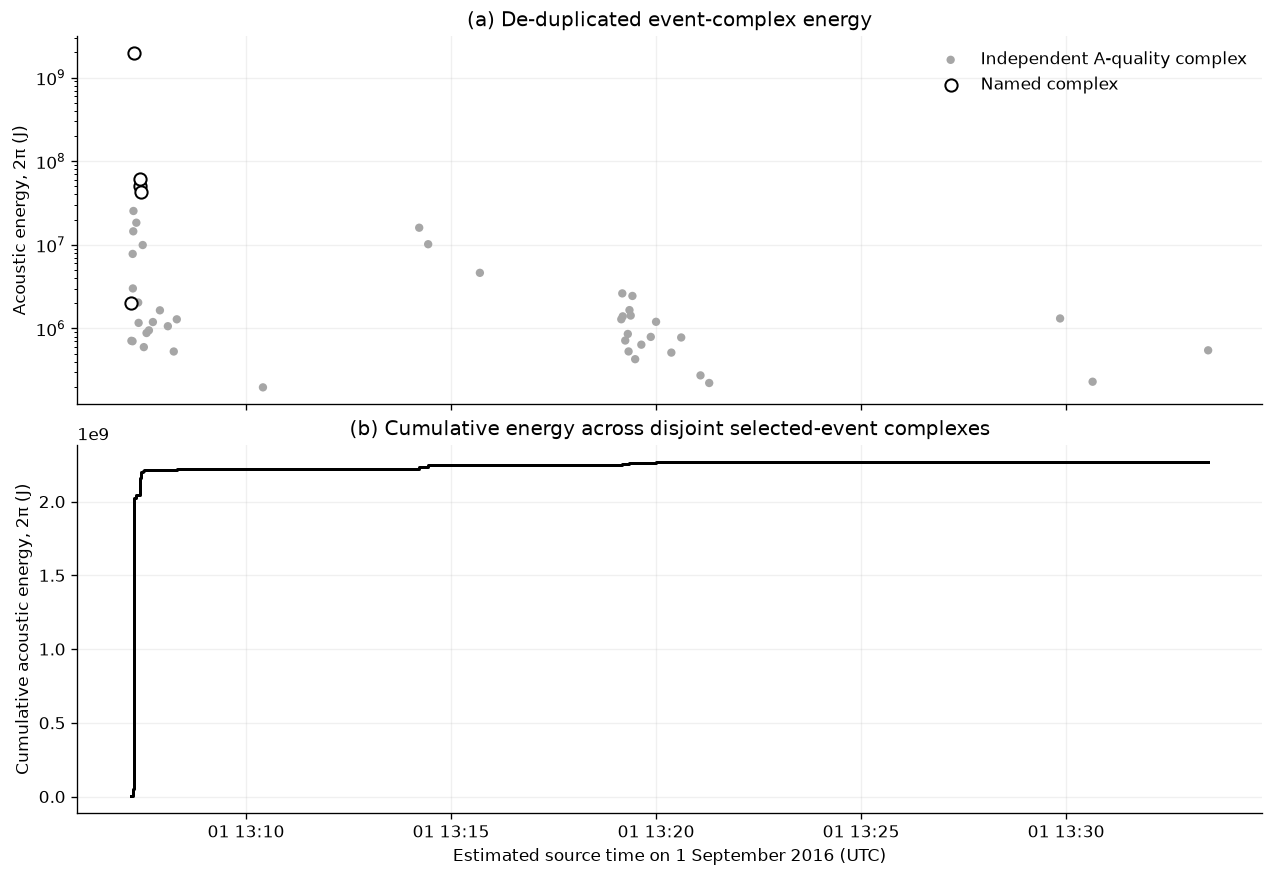

Wrote: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/100_measure_event_amplitudes_and_acoustic_seismic_coupling/event_complex_acoustic_energetics_by_channel.csv
Wrote: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/100_measure_event_amplitudes_and_acoustic_seismic_coupling/event_complex_acoustic_energetics_summary.csv
Wrote: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/100_measure_event_amplitudes_and_acoustic_seismic_coupling/cumulative_selected_event_acoustic_energetics_by_channel.csv
Wrote: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/100_measure_event_amplitudes_and_acoustic_seismic_coupling/cumulative_selected_event_acoustic_energetics_summary.csv
Wrote: /Users/thompsong/Developer/KSCRocketSeismology/08_f

In [100]:
TOP_OTHER_COMPLEX_COUNT = 5
complex_table_source = event_complex_energetics_summary.copy()

named_complexes = complex_table_source.loc[
    complex_table_source["contains_named_event"]
].sort_values("estimated_source_time").copy()
other_complexes = (
    complex_table_source.loc[~complex_table_source["contains_named_event"]]
    .nlargest(TOP_OTHER_COMPLEX_COUNT, "median_acoustic_energy_2pi_j")
    .copy()
)
main_complex_table_source = pd.concat(
    [named_complexes, other_complexes], ignore_index=True
)


def format_complex_table(frame):
    labels = np.where(
        frame["contains_named_event"],
        frame["named_event_keys"].astype(str).str.replace("_", " "),
        "complex " + frame["complex_number"].astype(int).astype(str),
    )
    return pd.DataFrame({
        "complex_number": frame["complex_number"].astype(int),
        "event_or_complex": labels,
        "member_event_numbers": frame["member_event_numbers"],
        "origin_time_utc": pd.to_datetime(frame["estimated_source_time"], utc=True).dt.strftime(
            "%Y-%m-%d %H:%M:%S.%f"
        ).str[:-3],
        "positive_peak_spl_db": frame["median_positive_peak_spl_db"],
        "radiated_acoustic_energy_2pi_j": frame["median_acoustic_energy_2pi_j"],
        "radiated_acoustic_energy_minimum_j": frame["minimum_acoustic_energy_2pi_j"],
        "radiated_acoustic_energy_maximum_j": frame["maximum_acoustic_energy_2pi_j"],
        "acoustic_energy_equivalent_kg_tnt": frame["median_acoustic_energy_equivalent_kg_tnt"],
        "illustrative_total_yield_at_1pct_t_tnt": (
            frame["median_illustrative_total_yield_at_1pct_kg_tnt"] / 1000.0
        ),
        "illustrative_total_yield_lower_t_tnt": (
            frame["median_illustrative_total_yield_lower_kg_tnt"] / 1000.0
        ),
        "illustrative_total_yield_upper_t_tnt": (
            frame["median_illustrative_total_yield_upper_kg_tnt"] / 1000.0
        ),
    })


main_complex_energetics_table = format_complex_table(main_complex_table_source)
supplement_complex_energetics_table = format_complex_table(
    complex_table_source.sort_values("median_acoustic_energy_2pi_j", ascending=False)
)
supplement_complex_energetics_table.insert(
    0, "acoustic_energy_rank",
    np.arange(1, len(supplement_complex_energetics_table) + 1),
)

display(main_complex_energetics_table)

# Plot complex energy and the de-duplicated running cumulative total.
fig, axes = plt.subplots(2, 1, figsize=(10.5, 7.2), sharex=True, constrained_layout=True)
ordinary = ~running["contains_named_event"]
named = running["contains_named_event"]
axes[0].scatter(
    running.loc[ordinary, "estimated_source_time"],
    running.loc[ordinary, "median_acoustic_energy_2pi_j"],
    s=25, color="0.65", edgecolor="none", label="Independent A-quality complex",
)
axes[0].scatter(
    running.loc[named, "estimated_source_time"],
    running.loc[named, "median_acoustic_energy_2pi_j"],
    s=54, facecolor="white", edgecolor="black", linewidth=1.2, label="Named complex",
)
axes[0].set_yscale("log")
axes[0].set_ylabel("Acoustic energy, 2π (J)")
axes[0].set_title("(a) De-duplicated event-complex energy")
axes[0].legend(frameon=False)

axes[1].step(
    running["estimated_source_time"], running["cumulative_acoustic_energy_2pi_j"],
    where="post", color="black", lw=1.8,
)
axes[1].set_ylabel("Cumulative acoustic energy, 2π (J)")
axes[1].set_xlabel("Estimated source time on 1 September 2016 (UTC)")
axes[1].set_title("(b) Cumulative energy across disjoint selected-event complexes")
for ax in axes:
    ax.grid(True, alpha=0.18)

fig.savefig(FIGURE_DIR / "deduplicated_event_complex_and_cumulative_energy.pdf", bbox_inches="tight")
plt.show()

COMPLEX_CHANNEL_FILE = OUTPUT_ROOT / "event_complex_acoustic_energetics_by_channel.csv"
COMPLEX_SUMMARY_FILE = OUTPUT_ROOT / "event_complex_acoustic_energetics_summary.csv"
CUMULATIVE_CHANNEL_FILE = OUTPUT_ROOT / "cumulative_selected_event_acoustic_energetics_by_channel.csv"
CUMULATIVE_SUMMARY_FILE = OUTPUT_ROOT / "cumulative_selected_event_acoustic_energetics_summary.csv"
MAIN_COMPLEX_TABLE_FILE = OUTPUT_ROOT / "main_named_plus_top5_complex_energetics.csv"
SUPPLEMENT_COMPLEX_TABLE_FILE = OUTPUT_ROOT / "supplement_all_event_complex_energetics.csv"
RAW_EVENT_WINDOW_FILE = OUTPUT_ROOT / "supplement_raw_overlapping_event_window_energetics.csv"

event_complex_energetics_by_channel.to_csv(COMPLEX_CHANNEL_FILE, index=False)
event_complex_energetics_summary.to_csv(COMPLEX_SUMMARY_FILE, index=False)
cumulative_by_channel.to_csv(CUMULATIVE_CHANNEL_FILE, index=False)
cumulative_acoustic_energetics_summary.to_csv(CUMULATIVE_SUMMARY_FILE, index=False)
main_complex_energetics_table.to_csv(MAIN_COMPLEX_TABLE_FILE, index=False)
supplement_complex_energetics_table.to_csv(SUPPLEMENT_COMPLEX_TABLE_FILE, index=False)
event_acoustic_energetics_summary.to_csv(RAW_EVENT_WINDOW_FILE, index=False)

print("Wrote:", COMPLEX_CHANNEL_FILE)
print("Wrote:", COMPLEX_SUMMARY_FILE)
print("Wrote:", CUMULATIVE_CHANNEL_FILE)
print("Wrote:", CUMULATIVE_SUMMARY_FILE)
print("Wrote:", MAIN_COMPLEX_TABLE_FILE)
print("Wrote:", SUPPLEMENT_COMPLEX_TABLE_FILE)
print("Wrote:", RAW_EVENT_WINDOW_FILE)